In [1]:
#Libraries we need

import warnings
warnings.filterwarnings("ignore")

import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib
from matplotlib import style
plt.style.use('default')

import os

from rasterio.plot import show
from rasterio.plot import plotting_extent
from rasterio.mask import mask

from funciones import nequalize, plot_rgb, delNone

from sklearn.cluster import KMeans
from sklearn import mixture

from scipy.optimize import curve_fit

In [2]:
#directory where the image is located
zona = 'norte'
path = 'ImagenesSentinel/stack2022'+zona+'.tif'
# path = 'ImagenesSentinel/Sur_20mTODOS.tif'
s2 = rasterio.open(path) #Bands 1,2,3,4,5,6,7,8,9,11 and 12 
s2_bandas = s2.read()
s2_bandas.shape #(number of bands, image height, image width)

(10, 3812, 1750)

In [3]:
bandas = ['Banda1', 'Azul', 'Verde', 'Rojo', 'Banda5', 'Banda6', 'Banda7', 'NIR', 'SWIR1', 'SWIR2']

bandas_pos = {}
for i in range(len(bandas)):
    bandas_pos[bandas[i]] = i
    
bandas_pos

{'Banda1': 0,
 'Azul': 1,
 'Verde': 2,
 'Rojo': 3,
 'Banda5': 4,
 'Banda6': 5,
 'Banda7': 6,
 'NIR': 7,
 'SWIR1': 8,
 'SWIR2': 9}

In [4]:
radios = gpd.read_file('Poligonos/Embalses_unificado.shp')#.set_index('id') #Loads shp file
radios.drop(columns=['path', 'objeto','entidad','layer'], inplace = True)
radios['id'] = np.linspace(0,10,11).astype(int)
radios.set_index('id')


Norte = ['Cruz del Eje','San Roque','El Cajon']
Sur = ['Cerro Pelado','Los Molinos','Rio Tercero','La ViÃ±a','Usina 3','Piedra Mora','Arroyo Corto']

radiosN = radios.query('fna in @Norte')
radiosS = radios.query('fna in @Sur')
radiosS

Norte_corregidos = ['Cruz del eje', 'El Cajon', 'San Roque']
radiosNorte_in = gpd.read_file('Poligonos/Norte/PoligonosEmbalses18-10.shp')
radiosNorte_in.loc[0].geometry

Sur_corregidos = ['Allende','Cerro Pelado','Rio Tercero','Los Molinos','Arroyo Corto','Usina 3','Sin Nombre2','Piedra Mora']
radiosSur_in = gpd.read_file('Poligonos/Sur/PoligonosEmbalsesSur18-10.shp')
radiosSur_in.loc[2].geometry

radiosSur = radiosSur_in.assign(fna=Sur_corregidos)
radiosNorte = radiosNorte_in.assign(fna=Norte_corregidos)

radiosSur.set_index('fna')
radiosSur.drop(columns=['id'], inplace = True)
radiosSur = radiosSur[['fna','geometry']]

radiosNorte.set_index('fna')
radiosNorte.drop(columns=['id'], inplace = True)
radiosNorte = radiosNorte[['fna','geometry']]
radiosSur

,fna,geometry
0,Allende,"POLYGON ((309760 6477420, 309780 6477420, 3097..."
1,Cerro Pelado,"POLYGON ((344100 6437120, 344120 6437120, 3441..."
2,Rio Tercero,"POLYGON ((365320 6440880, 365380 6440880, 3653..."
3,Los Molinos,"POLYGON ((354400 6483300, 354420 6483300, 3544..."
4,Arroyo Corto,"POLYGON ((351300 6434980, 351320 6434980, 3513..."
5,Usina 3,"POLYGON ((371960 6438900, 371980 6438900, 3719..."
6,Sin Nombre2,"POLYGON ((367740 6441120, 367760 6441120, 3677..."
7,Piedra Mora,"POLYGON ((380320 6441800, 380360 6441800, 3803..."


In [5]:
radiosNorte

,fna,geometry
0,Cruz del eje,"POLYGON ((332180.77 6595124.339, 332215.686 65..."
1,El Cajon,"POLYGON ((351041.243 6585831.893, 351043.737 6..."
2,San Roque,"POLYGON ((361134.245 6532611.069, 361106.812 6..."


Nombre del embalse:  El Cajon


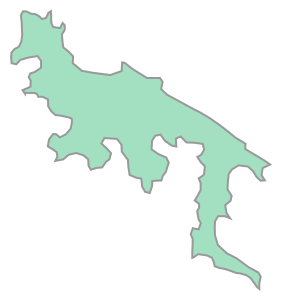

In [6]:
IDEmbalse = 1
nombre = radiosNorte.loc[IDEmbalse].fna
poligono = radiosNorte.loc[IDEmbalse].geometry #geometry of the eighth element of the shp
print( "Nombre del embalse: ", nombre)
poligono

In [7]:
s2_plot_extent = plotting_extent(s2) #Boundaries of the region to plot
s2_plot_extent

# Plot of the image with the polygons on top
bandasPosicion = [3,2,1] # RGB

# img = nequalize(s2_bandas[bandasPosicion], p=5, nodata = None)
# fig, ax = plt.subplots(figsize = (15,8))
# show(img, ax=ax, extent = s2_plot_extent, cmap = 'gray')
# if zona == 'norte':
#     radiosN.boundary.plot(ax=ax, edgecolor = 'red')
# elif zona == 'sur':
#     radiosS.boundary.plot(ax=ax, edgecolor = 'red')
# else:
#     print('Zona debe ser norte o sur')


In [8]:
# IDEmbalse = 0
# nombre = radiosSur.loc[IDEmbalse].fna
# poligono = radiosSur.loc[IDEmbalse].geometry #geometry of the eighth element of the shp
# poligono

<Axes: >

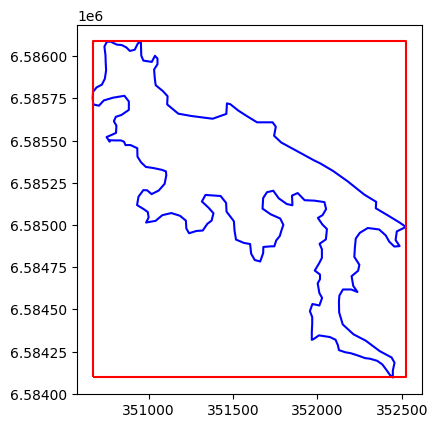

In [10]:
# CROP THE AREA OF INTEREST
extent = poligono.envelope

data = [poligono, extent]
gpd.GeoSeries(data).boundary.plot(color=['b', 'r'])

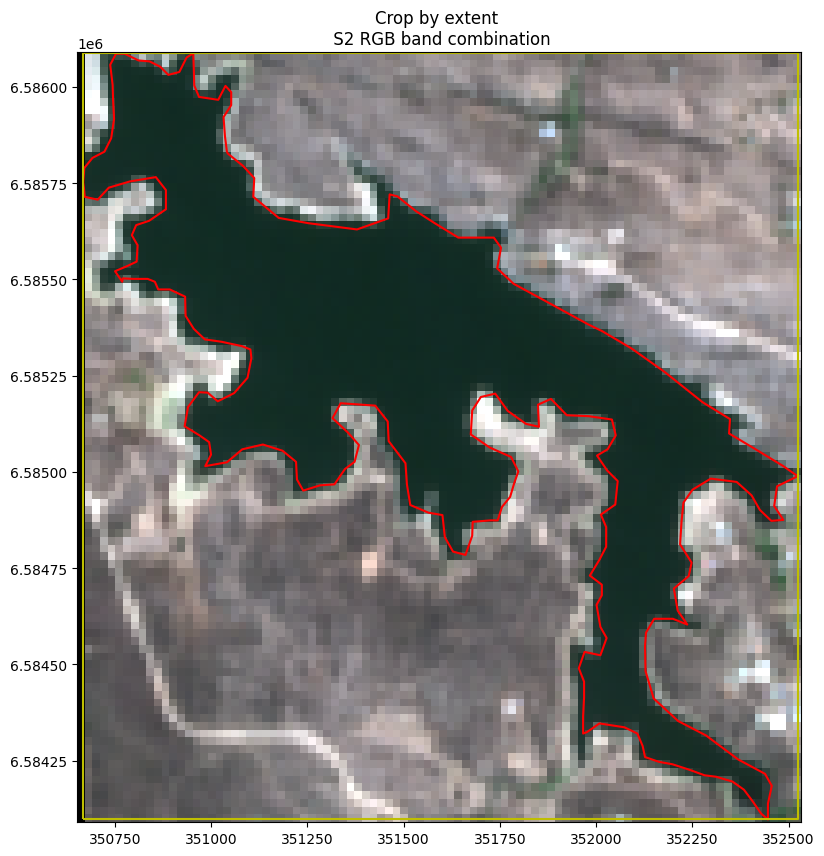

In [11]:
bandasPosicion = [3,2,1] # RGB
# bandasPosicion = [0,1,2] # RGB

s2_clip, clip_transform = mask(dataset = s2, shapes = [extent], crop = True)
fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(s2_clip[bandasPosicion],p=0.5,nodata = None), ax=ax, transform=clip_transform)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by extent \n S2 RGB band combination")
plt.show()

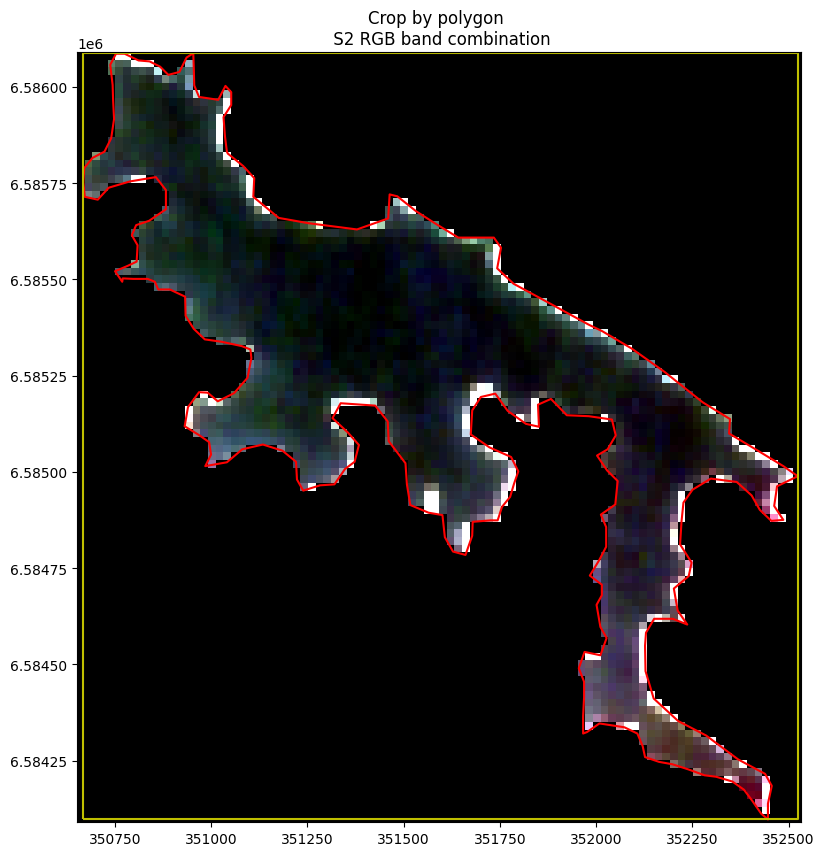

In [12]:
# Keep only what is inside the vector mask
s2_mask, mask_transform  = mask(dataset = s2, shapes = [poligono], crop = True)

fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(s2_mask[bandasPosicion], p=5), ax=ax, transform=mask_transform)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by polygon \n S2 RGB band combination")
plt.show()

--------------
## Spectral signatures

In [13]:
# The shp file used for training must have at least 2 columns, the first one named CLASE with the name of
# each type; I used agua clara, alga densa and alga difusa. The chosen name doesn't matter
# The second column is the geometry of each polygon

# pols = gpd.read_file('Poligonos/Entrenamiento_2022/pol180222-2.shp')#.set_index('id') #Loads shp file with the training polygons for the reservoir
pols = gpd.read_file('Poligonos/Entrenamiento_2022/polCruz-2.shp')
#If it doesn't have the same names I used, they can be changed from here,
# where in the dictionary, for each dataframe value, you enter the new name you want
# for example, from id to id_clase
nombres_col = {'id':'id_clase', 'clase_1':'CLASE'} 
pols.rename(columns = nombres_col, inplace = True)
pols

,id_clase,CLASE,geometry
0,1,Alga Difusa,"POLYGON ((332888.269 6596103.792, 333059.327 6..."
1,2,Alga Difusa,"POLYGON ((332486.702 6595109.782, 332600.393 6..."
2,3,Alga Difusa,"POLYGON ((333241.857 6595443.552, 333328.429 6..."
3,4,Alga Difusa,"POLYGON ((333685.146 6595681.885, 333620.478 6..."
4,5,Alga Difusa,"POLYGON ((333775.368 6595183.837, 333745.12 65..."
5,6,Alga Difusa,"POLYGON ((334447.081 6594453.715, 334623.354 6..."
6,7,Agua Clara,"POLYGON ((332810.564 6594632.073, 333014.998 6..."
7,8,Agua Clara,"POLYGON ((334191.538 6594978.36, 334220.743 65..."
8,9,Agua Clara,"POLYGON ((334003.792 6594294.131, 334229.087 6..."
9,10,Agua Clara,"POLYGON ((333144.334 6593826.852, 332906.522 6..."


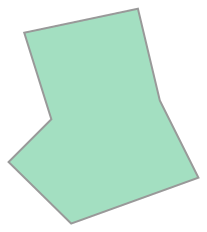

In [14]:
id_clase = 1
rois = pols.loc[id_clase].geometry #geometry of the eighth element of the shp
rois

In [15]:
extent = rois.envelope

data = [rois, extent]
# gpd.GeoSeries(data).boundary.plot(color=['b', 'r'])


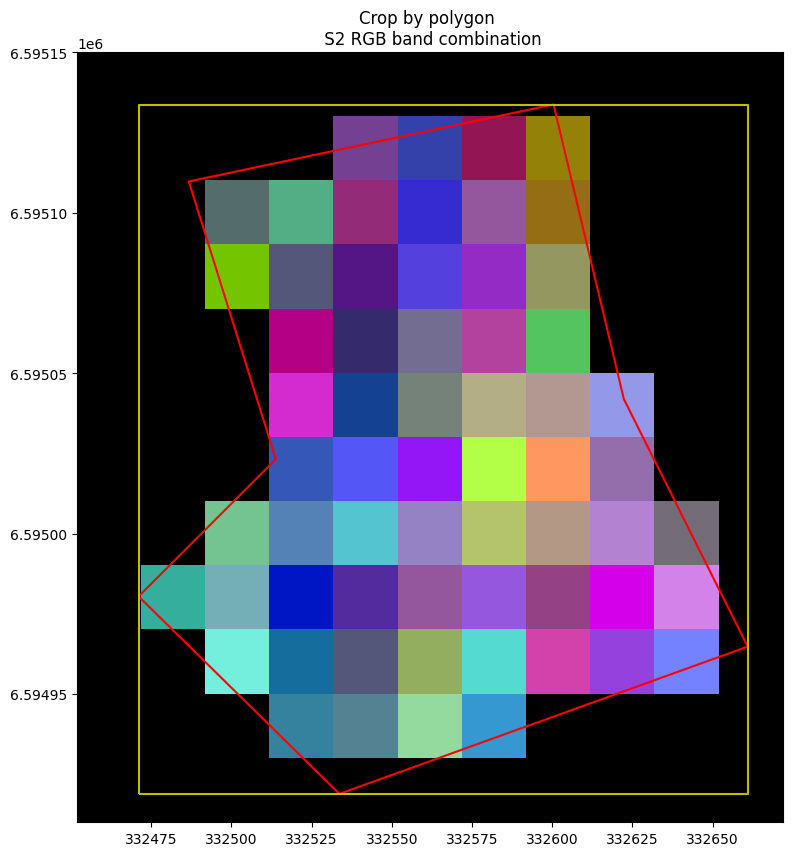

In [16]:
roi_mask, roi_transform  = mask(dataset = s2, shapes = [rois], crop = True)

fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(roi_mask[bandasPosicion], p=0.5), ax=ax,transform=roi_transform)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by polygon \n S2 RGB band combination")
plt.show()

In [17]:
reescalado = 10000
blue = delNone(roi_mask[bandasPosicion[2]],0,reescalado)
green = delNone(roi_mask[bandasPosicion[1]],0,reescalado)
red = delNone(roi_mask[bandasPosicion[0]],0,reescalado)
nir = delNone(roi_mask[7],0,reescalado)  # NIR is at index 7 in this 10-band stack

In [18]:
roi_mask.shape

(10, 12, 11)

In [19]:
bandas = ['Banda1', 'Azul', 'Verde', 'Rojo', 'Banda5', 'Banda6', 'Banda7', 'NIR', 'SWIR1', 'SWIR2']
landa = [443, 490, 560, 665, 705, 740, 783, 842, 1610, 2190]
len(bandas) == len(landa)

True

In [20]:
bandas_dic = {}
mean = []
std = []

for i in range(len(bandas)):
    dic = bandas[i]
    array = delNone(roi_mask[i],0,10000)
    bandas_dic[dic] = array

    mean.append(np.mean(array))
    std.append(np.std(array))
    
df = pd.DataFrame.from_dict(bandas_dic)  
mean = np.asarray(mean)
std = np.asarray(std)
# df['Azul']['Lambda'] = 490

In [21]:
df.keys()

Index(['Banda1', 'Azul', 'Verde', 'Rojo', 'Banda5', 'Banda6', 'Banda7', 'NIR',
       'SWIR1', 'SWIR2'],
      dtype='object')

In [22]:
df2 = pd.DataFrame([landa], columns=bandas, index = ['Lambda'])
pd.concat([df2, df])  # DataFrame.append() was removed in pandas 2.x

,Banda1,Azul,Verde,Rojo,Banda5,Banda6,Banda7,NIR,SWIR1,SWIR2
Lambda,443.0000,490.0000,560.0000,665.0000,705.0000,740.0000,783.0000,842.0000,1610.0000,2190.0000
0,0.0107,0.0153,0.0147,0.0105,0.0083,0.0053,0.0059,0.0050,0.0056,0.0043
1,0.0108,0.0155,0.0147,0.0103,0.0082,0.0053,0.0064,0.0050,0.0053,0.0048
2,0.0109,0.0148,0.0145,0.0106,0.0085,0.0054,0.0060,0.0051,0.0051,0.0047
3,0.0111,0.0142,0.0150,0.0106,0.0082,0.0055,0.0061,0.0054,0.0049,0.0040
...,...,...,...,...,...,...,...,...,...,...
57,0.0112,0.0162,0.0150,0.0105,0.0083,0.0060,0.0063,0.0055,0.0048,0.0046
58,0.0113,0.0154,0.0150,0.0103,0.0080,0.0060,0.0059,0.0058,0.0050,0.0046
59,0.0114,0.0153,0.0150,0.0104,0.0083,0.0057,0.0060,0.0055,0.0054,0.0050
60,0.0114,0.0154,0.0154,0.0106,0.0090,0.0056,0.0061,0.0053,0.0054,0.0048


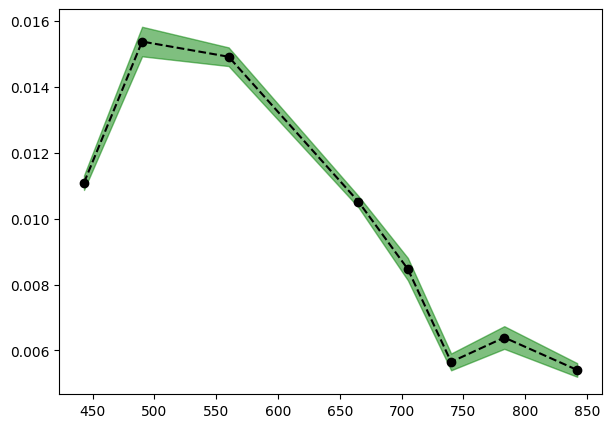

In [24]:
ignorePoints = 2
landa2 = landa[:-ignorePoints]
mean2 = mean[:-ignorePoints]
std2 = std[:-ignorePoints]

plt.figure(figsize = (7,5))
plt.plot(landa2, mean2, 'o--', color='k')
plt.fill_between(landa2, mean2-std2, mean2+std2,
    alpha=0.5, edgecolor='g', facecolor='g')

In [25]:
pol2 = pols
pol2 = pol2.set_index('CLASE')
# pol2.loc[pol2['CLASE'] == 'Agua Clara']
pol2

,id_clase,geometry
CLASE,,
Alga Difusa,1,"POLYGON ((332888.269 6596103.792, 333059.327 6..."
Alga Difusa,2,"POLYGON ((332486.702 6595109.782, 332600.393 6..."
Alga Difusa,3,"POLYGON ((333241.857 6595443.552, 333328.429 6..."
Alga Difusa,4,"POLYGON ((333685.146 6595681.885, 333620.478 6..."
Alga Difusa,5,"POLYGON ((333775.368 6595183.837, 333745.12 65..."
Alga Difusa,6,"POLYGON ((334447.081 6594453.715, 334623.354 6..."
Agua Clara,7,"POLYGON ((332810.564 6594632.073, 333014.998 6..."
Agua Clara,8,"POLYGON ((334191.538 6594978.36, 334220.743 65..."
Agua Clara,9,"POLYGON ((334003.792 6594294.131, 334229.087 6..."


In [26]:
# Clases = ['Agua Clara', 'Alga Difusa', 'Alga Densa']
Clases=list(set(pols['CLASE']))
pol2 = pols
pol2 = pol2.set_index('CLASE')

for index, row in pol2.iterrows():
    print(index)

Alga Difusa
Alga Difusa
Alga Difusa
Alga Difusa
Alga Difusa
Alga Difusa
Agua Clara
Agua Clara
Agua Clara
Agua Clara
Agua Clara
Agua Clara
Agua Clara
Agua Sedimentos
Agua Sedimentos
Agua Sedimentos
Agua Sedimentos


In [29]:
# for clss in Clases:
#     aux = np.asarray(pol2.loc[index].id_clase)
#     plt.figure(figsize = (7,5))
#     for index in range(aux[0], aux[-1]):
#         id_clase = index
#         print(index)
#         rois = pols.loc[id_clase].geometry #geometry of the eighth element of the shp

#         roi_mask, roi_transform  = mask(dataset = s2, shapes = [rois], crop = True)

#         # fig, ax = plt.subplots(figsize = (10,10))
#         # show(nequalize(roi_mask[bandasPosicion], p=0.5), ax=ax,transform=roi_transform)
#         # gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
#         # plt.title("Crop by polygon \n S2 RGB band combination")
#         # plt.show()

#         bandas_dic = {}
#         mean = []
#         std = []

#         for i in range(len(bandas)):
#             dic = bandas[i]
#             array = delNone(roi_mask[i],0,10000)
#             bandas_dic[dic] = array

#             mean.append(np.mean(array))
#             std.append(np.std(array))

#         # df = pd.DataFrame.from_dict(bandas_dic)  
#         mean = np.asarray(mean)
#         std = np.asarray(std)
#         # df['Azul']['Lambda'] = 490

#         ignorePoints = 2
#         landa2 = landa[:-ignorePoints]
#         mean2 = mean[:-ignorePoints]
#         std2 = std[:-ignorePoints]


#         plt.plot(landa2, mean2, 'o--', label = index)
#         plt.fill_between(landa2, mean2-std2, mean2+std2, alpha=0.5)

#     plt.legend()

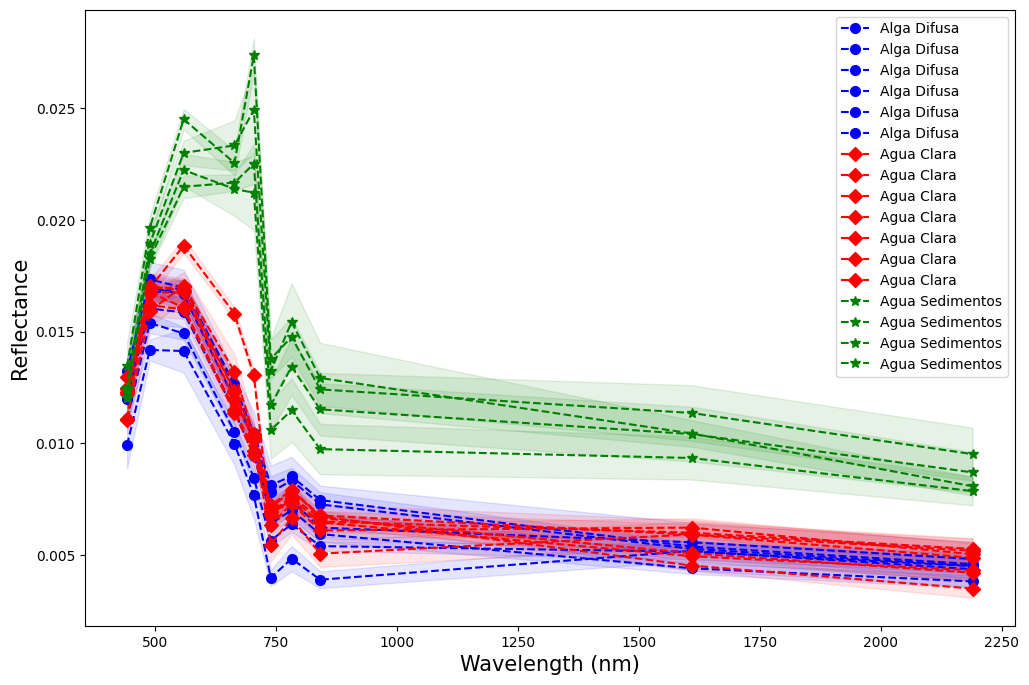

In [30]:
# Clases = ['Agua Clara', 'Alga Difusa', 'Alga Densa']
# Clases = ['Agua Clara', 'Alga Difus']
Clases=list(set(pols['CLASE']))
# pol2 = pols
# pol2 = pol2.set_index('CLASE')
color = ['b','r','g']


plt.figure(figsize = (12,8))
for index, row in pols.iterrows():
    
    id_clase = index

    if pols.loc[id_clase].CLASE == Clases[0]:
        marker_style = 'o'
        col = color[0]
    elif pols.loc[id_clase].CLASE == Clases[1]:
        marker_style = 'D'
        col = color[1]
    elif pols.loc[id_clase].CLASE == Clases[2]:
        marker_style = "*"
        col = color[2]

    rois = pols.loc[id_clase].geometry #geometry of the eighth element of the shp
    roi_mask, roi_transform  = mask(dataset = s2, shapes = [rois], crop = True)

    bandas_dic = {}
    mean = []
    std = []

    for i in range(len(bandas)):
        dic = bandas[i]
        array = delNone(roi_mask[i],0,10000)
        bandas_dic[dic] = array

        mean.append(np.mean(array))
        std.append(np.std(array))
  
    mean = np.asarray(mean)
    std = np.asarray(std)

    ignorePoints = 0
    if ignorePoints > 0:
        landa2 = landa[:-ignorePoints]
        mean2 = mean[:-ignorePoints]
        std2 = std[:-ignorePoints]
    else: 
        landa2 = landa
        mean2 = mean
        std2 = std


    plt.plot(landa2, mean2, ls = 'dashed', marker = marker_style, ms = 7, label = pols.loc[id_clase].CLASE, color = col)#, label = 'muestra'+str(index))
    plt.fill_between(landa2, mean2-std2, mean2+std2, alpha=0.1, color = col)
    
plt.xlabel('Wavelength (nm)', fontsize=15)
plt.ylabel('Reflectance', fontsize=15)
plt.legend()

In [31]:
Clases = ['Agua Clara', 'Alga Difusa', 'Alga Densa']
pol2 = pols
pol2 = pol2.set_index('CLASE')
color = ['blue','r','g']
    
def firma(i):
    id_clase = i
    # print(i,pols.loc[id_clase].CLASE)
    
    if pols.loc[id_clase].CLASE == Clases[0]:
        marker_style = 'o'
        col = color[0]
        print(pols.loc[id_clase].CLASE)
    elif pols.loc[id_clase].CLASE == Clases[1]:
        marker_style = 'D'
        col = color[1]
    elif pols.loc[id_clase].CLASE == Clases[2]:
        marker_style = "*"
        col = color[2]

    rois = pols.loc[id_clase].geometry #geometry of the eighth element of the shp

    roi_mask, roi_transform  = mask(dataset = s2, shapes = [rois], crop = True)

    # fig, ax = plt.subplots(figsize = (10,10))
    # show(nequalize(roi_mask[bandasPosicion], p=0.5), ax=ax,transform=roi_transform)
    # gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
    # plt.title("Crop by polygon \n S2 RGB band combination")
    # plt.show()

    bandas_dic = {}
    mean = []
    std = []

    for i in range(len(bandas)):
        dic = bandas[i]
        array = delNone(roi_mask[i],0,10000)
        bandas_dic[dic] = array

        mean.append(np.mean(array))
        std.append(np.std(array))

    # df = pd.DataFrame.from_dict(bandas_dic)  
    mean = np.asarray(mean)
    std = np.asarray(std)
    # df['Azul']['Lambda'] = 490

    ignorePoints = 0
    if ignorePoints > 0:
        landa2 = landa[:-ignorePoints]
        mean2 = mean[:-ignorePoints]
        std2 = std[:-ignorePoints]
    else: 
        landa2 = landa
        mean2 = mean
        std2 = std


    plt.plot(landa2, mean2, ls = 'dashed', marker = marker_style, ms = 8, label = pols.loc[id_clase].CLASE, color = col)#, label = 'muestra'+str(index))
    plt.fill_between(landa2, mean2-std2, mean2+std2, alpha=0.1, color = col)
    plt.show()


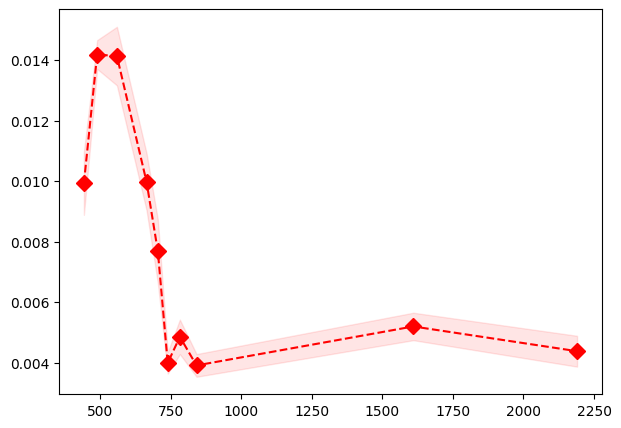

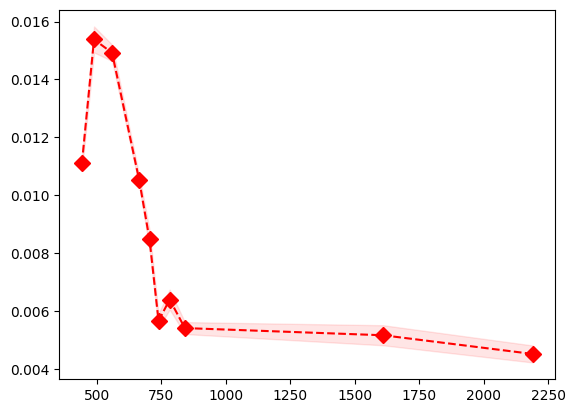

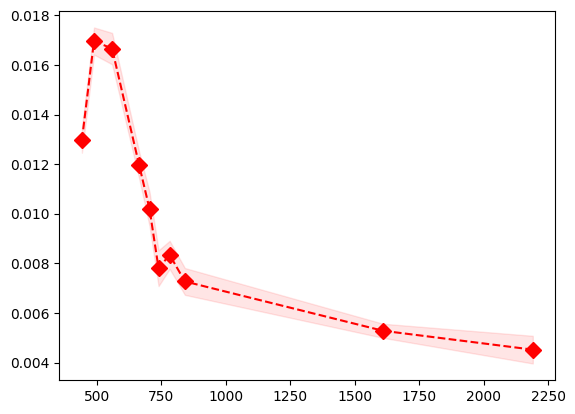

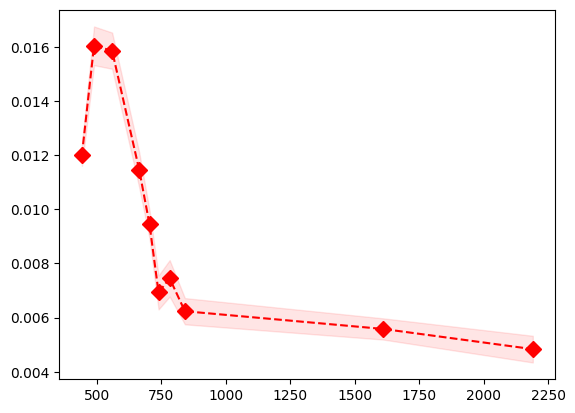

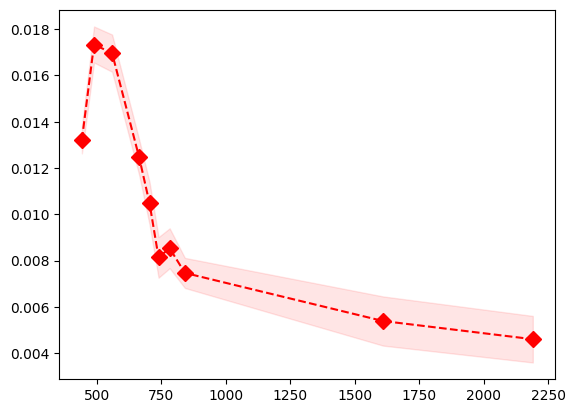

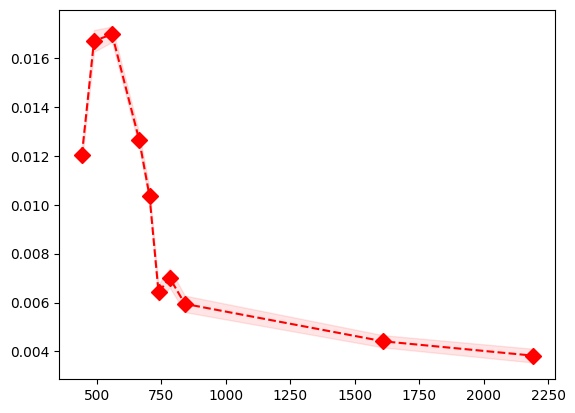

Agua Clara


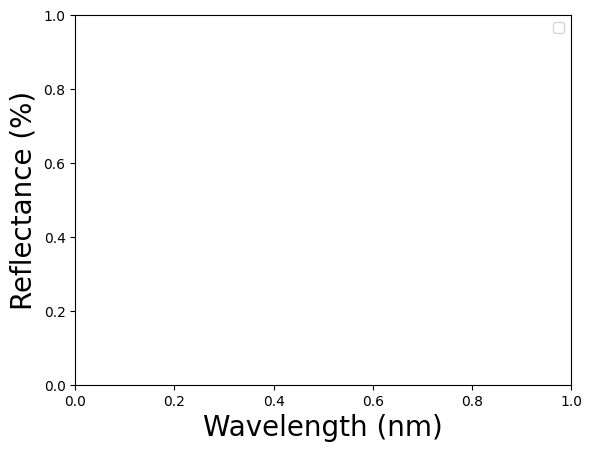

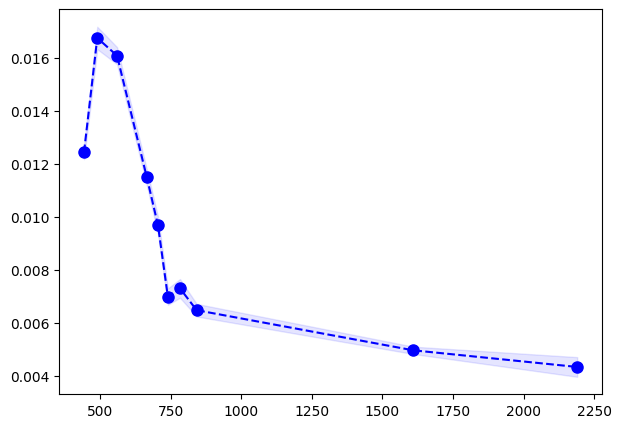

Agua Clara


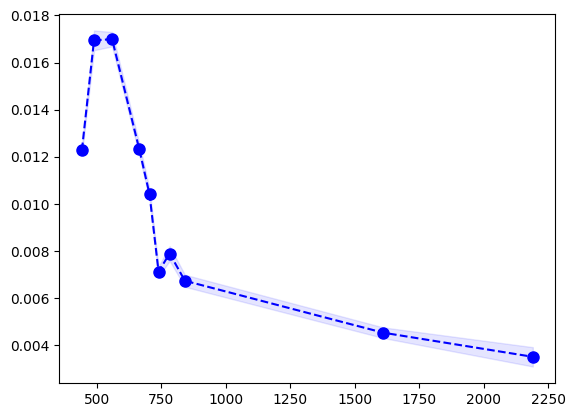

Agua Clara


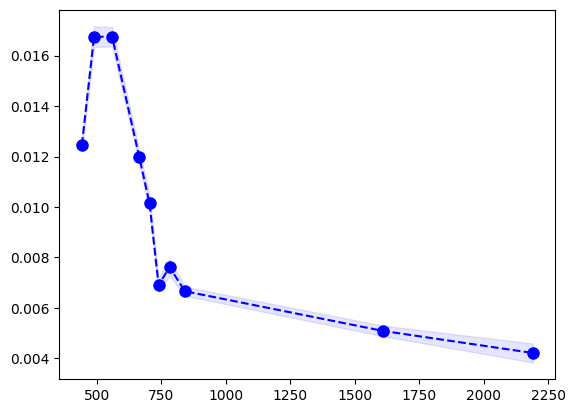

Agua Clara


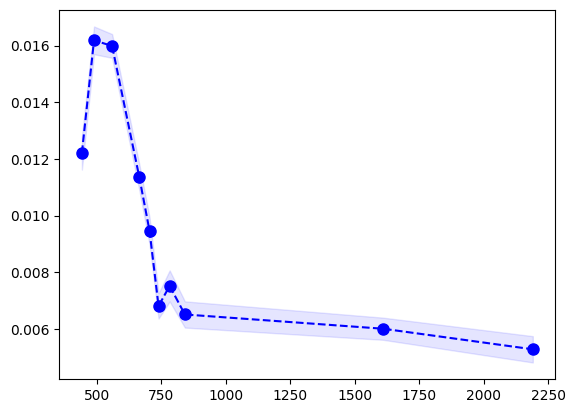

Agua Clara


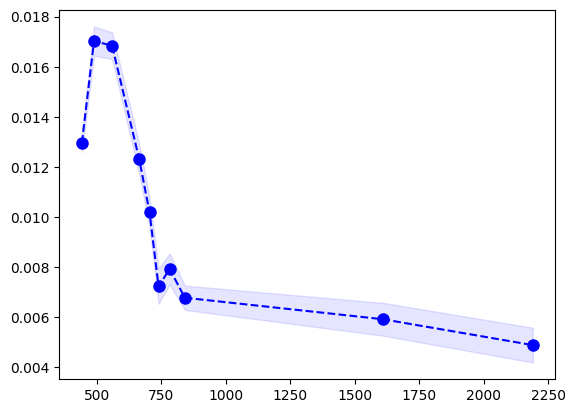

Agua Clara


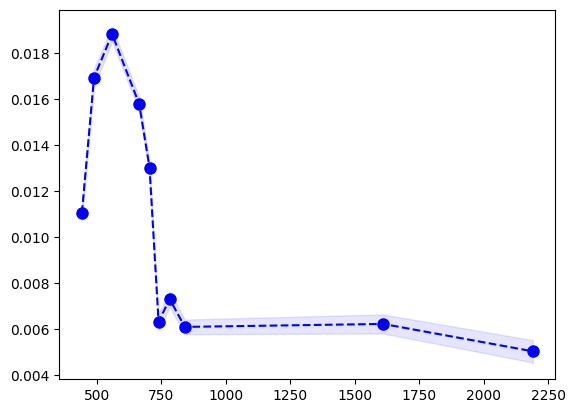

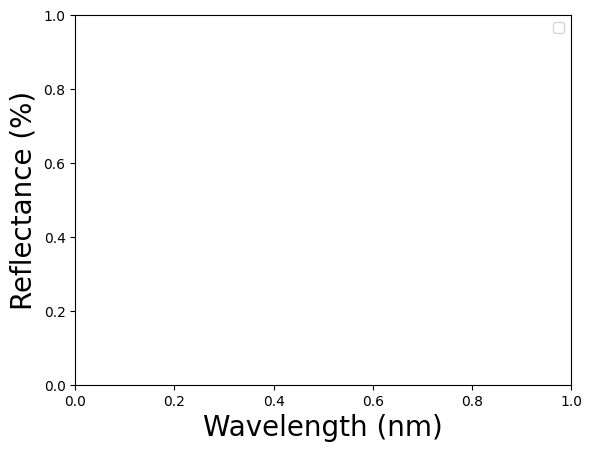

In [32]:
plt.figure(figsize = (7,5))

for i in range(0,6):
    firma(i)
    
plt.xlabel('Wavelength (nm)', fontsize=20)
plt.ylabel('Reflectance (%)', fontsize=20)
plt.legend()

plt.figure(figsize = (7,5))

for i in range(6,12):
    firma(i)
    
plt.xlabel('Wavelength (nm)', fontsize=20)
plt.ylabel('Reflectance (%)', fontsize=20)
plt.legend()

# plt.figure(figsize = (7,5))

# for i in range(12,18):
#     firma(i)
    
# plt.xlabel('Wavelength (nm)', fontsize=20)
# plt.ylabel('Reflectance', fontsize=20)
# plt.legend()

In [33]:
def firmaMean(i):
    
    id_clase = i
    # print(i,pols.loc[id_clase].CLASE)
    
    if pols.loc[id_clase].CLASE == Clases[0]:
        marker_style = 'o'
        col = color[0]
    elif pols.loc[id_clase].CLASE == Clases[1]:
        marker_style = 'D'
        col = color[1]
    elif pols.loc[id_clase].CLASE == Clases[2]:
        marker_style = "*"
        col = color[2]

    rois = pols.loc[id_clase].geometry #geometry of the eighth element of the shp
    roi_mask, roi_transform  = mask(dataset = s2, shapes = [rois], crop = True)


    bandas_dic = {}
    mean = []
    std = []

    for i in range(len(bandas)):
        dic = bandas[i]
        array = delNone(roi_mask[i],0,10000)
        bandas_dic[dic] = array

        mean.append(np.mean(array))
        std.append(np.std(array))

    # df = pd.DataFrame.from_dict(bandas_dic)  
    mean = np.asarray(mean)
    # df['Azul']['Lambda'] = 490

    ignorePoints = 0
    if ignorePoints > 0:
        landa2 = landa[:-ignorePoints]
        mean2 = mean[:-ignorePoints]
        std2 = std[:-ignorePoints]
    else: 
        landa2 = landa
        mean2 = mean
        std2 = std
    
#     meanmean.append(mean)
#     stdstd.append(std)    
    
#     return meanmean, stdstd
    return mean2

KeyError: 17

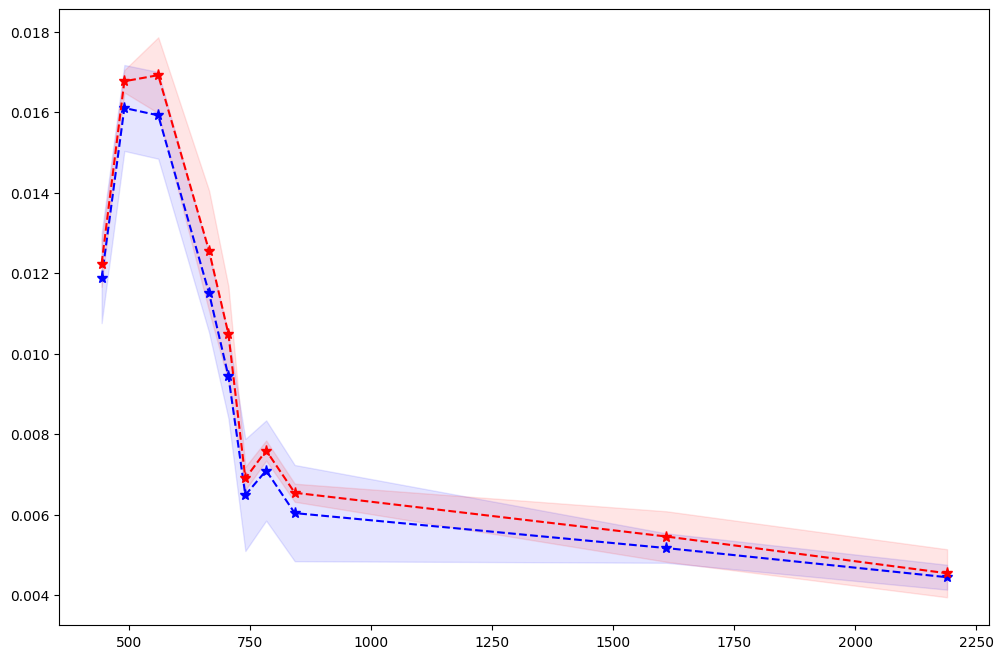

In [34]:
Clases=list(set(pols['CLASE']))
color = ['b','r','g']


plt.figure(figsize = (12,8))

returnOut = []
for i in range(0,6):
    returnOut.append(firmaMean(i))
    # ss.append(firmaMean(i)[1])
    
mm = np.asarray(returnOut)
mmean = np.mean(mm,axis=0)
ss = np.std(mm,axis=0)

plt.plot(landa2, mmean, ls = 'dashed', marker = marker_style, ms = 8, label = Clases[0], color = 'b')#, label = 'muestra'+str(index))
plt.fill_between(landa2, mmean-ss, mmean+ss, alpha=0.1, color = 'b')

returnOut = []
for i in range(6,12):
    returnOut.append(firmaMean(i))
    # ss.append(firmaMean(i)[1])
    
mm = np.asarray(returnOut)
mmean = np.mean(mm,axis=0)
ss = np.std(mm,axis=0)

plt.plot(landa2, mmean, ls = 'dashed', marker = marker_style, ms = 8, label = Clases[1], color = 'r')#, label = 'muestra'+str(index))
plt.fill_between(landa2, mmean-ss, mmean+ss, alpha=0.1, color = 'r')

returnOut = []
for i in range(12,18):
    returnOut.append(firmaMean(i))
    # ss.append(firmaMean(i)[1])
    
mm = np.asarray(returnOut)
mmean = np.mean(mm,axis=0)
ss = np.std(mm,axis=0)

plt.plot(landa2, mmean, ls = 'dashed', marker = marker_style, ms = 8, label = Clases[2], color = 'g')#, label = 'muestra'+str(index))
plt.fill_between(landa2, mmean-ss, mmean+ss, alpha=0.1, color = 'g')
plt.legend()
plt.xlabel('Wavelength (nm)', fontsize=20)
plt.ylabel('Reflectance', fontsize=20)
plt.legend()

In [35]:
def tensor2matrix(tensor):
    # rows, columns, channels and filters
    r, c, ch = tensor.shape
    new_dim = [r, c*ch] # Inferer the new matrix dims
    # Transpose is necesary because the columns are the channels weights 
    # flattened in columns
    return np.reshape(np.transpose(tensor, [2,0,1]), new_dim, order="F")

In [36]:
Clases

['Alga Difusa', 'Agua Clara', 'Agua Sedimentos']

In [37]:
aa = [[],[],[],[],[],[],[],[],[],[]]
dden = [[],[],[],[],[],[],[],[],[],[]]
ddif = [[],[],[],[],[],[],[],[],[],[]]
for index, row in pols.iterrows():
    
    id_clase = index
    rois = pols.loc[id_clase].geometry #geometry of the eighth element of the shp
    roi_mask, roi_transform  = mask(dataset = s2, shapes = [rois], crop = True)
    
    roi = np.asarray(roi_mask)
    roi2 = tensor2matrix(roi)/10000
    
    
    if pols.loc[id_clase].CLASE == Clases[0]:
        for i in range(10):
            dden[i] = np.append(aa[i],roi2[i,:])        
        
    elif pols.loc[id_clase].CLASE == Clases[1]:
        for i in range(10):
            aa[i] = np.append(aa[i],roi2[i,:])
        
    elif pols.loc[id_clase].CLASE == Clases[2]:
        for i in range(10):
            ddif[i] = np.append(aa[i],roi2[i,:])

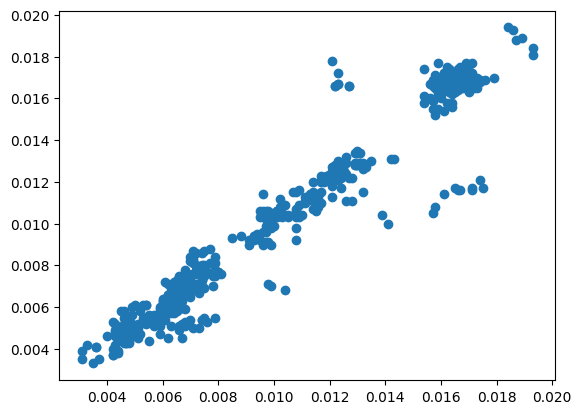

In [38]:
banda1 = 4
banda2 = 8

array = aa

array[banda1][array[banda1]==0] = np.nan
array[banda2][array[banda2]==0] = np.nan

plt.scatter(array[banda1], array[banda2])

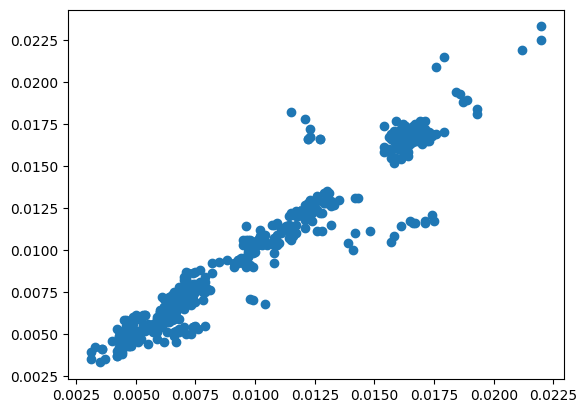

In [39]:
banda1 = 4
banda2 = 8

array = ddif

array[banda1][array[banda1]==0] = np.nan
array[banda2][array[banda2]==0] = np.nan

plt.scatter(array[banda1], array[banda2])

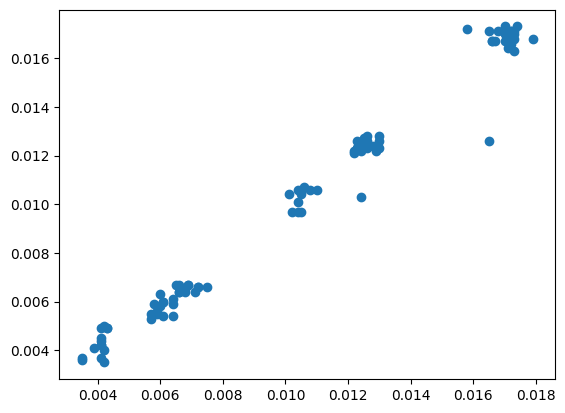

In [40]:
banda1 = 4
banda2 = 8

array = dden

array[banda1][array[banda1]==0] = np.nan
array[banda2][array[banda2]==0] = np.nan

plt.scatter(array[banda1], array[banda2])

In [41]:
def lineal(x,a,b):
    return a*x + b

[0.82528267 0.00133564] [0.83949624 0.00125427] [0.58668977 0.00404076]


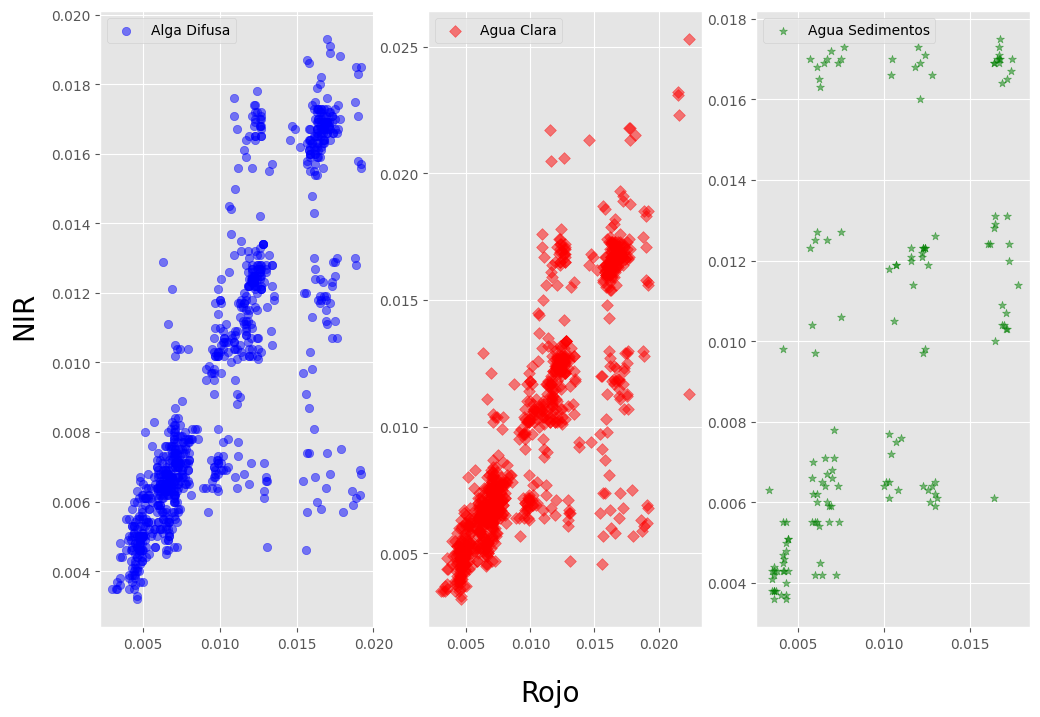

In [42]:
plt.style.use('ggplot')
fig, ax = plt.subplots(1, 3, figsize = (12,8), sharex = False, sharey = False)

banda1 = 3
banda2 = 7

# aa[banda1][aa[banda1]==0] = np.nan
# aa[banda2][aa[banda2]==0] = np.nan

# ddif[banda1][ddif[banda1]==0] = np.nan
# ddif[banda2][ddif[banda2]==0] = np.nan

# dden[banda1][dden[banda1]==0] = np.nan
# dden[banda2][dden[banda2]==0] = np.nan

aux1 = aa[banda1][aa[banda1]!=0]
aux2 = aa[banda2][aa[banda2]!=0]

aux3 = ddif[banda1][ddif[banda1]!=0]
aux4 = ddif[banda2][ddif[banda2]!=0]

aux5 = dden[banda1][dden[banda1]!=0]
aux6 = dden[banda2][dden[banda2]!=0]

popt1, pcov1 = curve_fit(lineal, aux1, aux2)
popt2, pcov2 = curve_fit(lineal, aux3, aux4)
popt3, pcov3 = curve_fit(lineal, aux5, aux6)

print(popt1, popt2, popt3)

# ax[0].scatter(aa[banda1],aa[banda2], label = 'Agua Clara', color = 'b', alpha = 0.5, marker = 'o')
ax[0].scatter(aux1,aux2, label = Clases[0], color = 'b', alpha = 0.5, marker = 'o')
# ax[0].plot(aux1, lineal(aux1, popt1[0], popt1[1]), 'k')
# ax[1].scatter(ddif[banda1],ddif[banda2], label = 'Alga Difusa', color = 'r', alpha = 0.5, marker = 'D')
# ax[2].scatter(dden[banda1],dden[banda2], label = 'Alga Densa', color = 'g', alpha = 0.5, marker = '*')
ax[1].scatter(aux3,aux4, label = Clases[1], color = 'r', alpha = 0.5, marker = 'D')
# ax[1].plot(aux3, lineal(aux3, popt2[0], popt2[1]), 'k')

ax[2].scatter(aux5,aux6, label = Clases[2], color = 'g', alpha = 0.5, marker = '*')
# ax[2].plot(aux5, lineal(aux5, popt3[0], popt3[1]), 'k')

ax[0].legend()
ax[1].legend()
ax[2].legend()

fig.supxlabel(bandas[banda1], size = 20)#, y = -0.02)
fig.supylabel(bandas[banda2], size = 20, x = 0.05)
plt.style.use('default')

In [43]:
mydict1={}
for index, i in enumerate(aux1):
    mydict1[index]=i
    
mydict2={}
for index, i in enumerate(aux2):
    mydict2[index]=i

In [44]:
from dictances import bhattacharyya, bhattacharyya_coefficient, euclidean

In [45]:
np.abs(bhattacharyya(mydict1, mydict2)), bhattacharyya_coefficient(mydict1, mydict2), euclidean(mydict1, mydict2)

(np.float64(2.1350883067968947),
 8.457793354525142,
 np.float64(0.07365188388629312))

pass
[0.88014677 0.0013647 ] [0.87479112 0.00140819] [0.85939128 0.00139869]


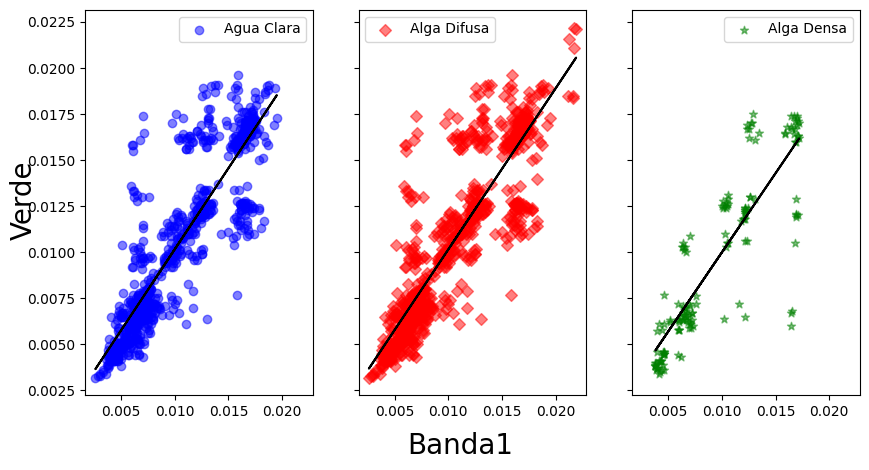

pass
pass
pass
[0.82214706 0.00141488] [0.83294837 0.00131507] [0.76410015 0.00239476]


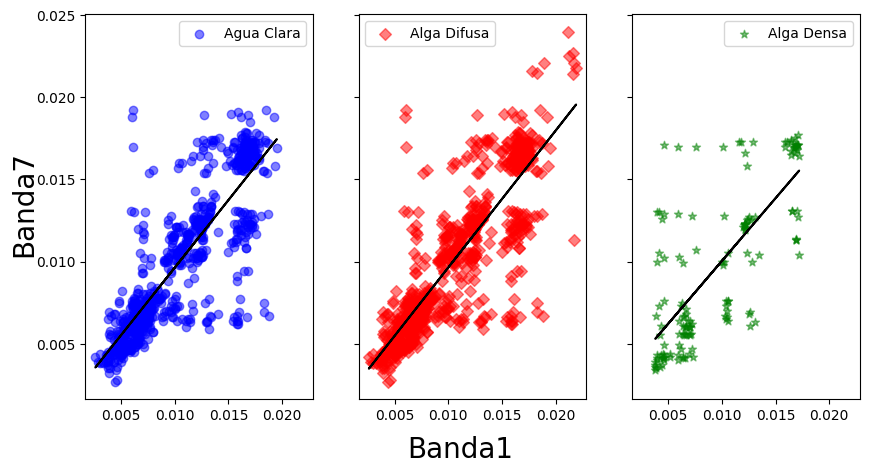

pass
pass
pass
pass
pass
[0.8645937  0.00129934] [0.87139545 0.0012443 ] [9.32710296e-01 6.74382180e-04]


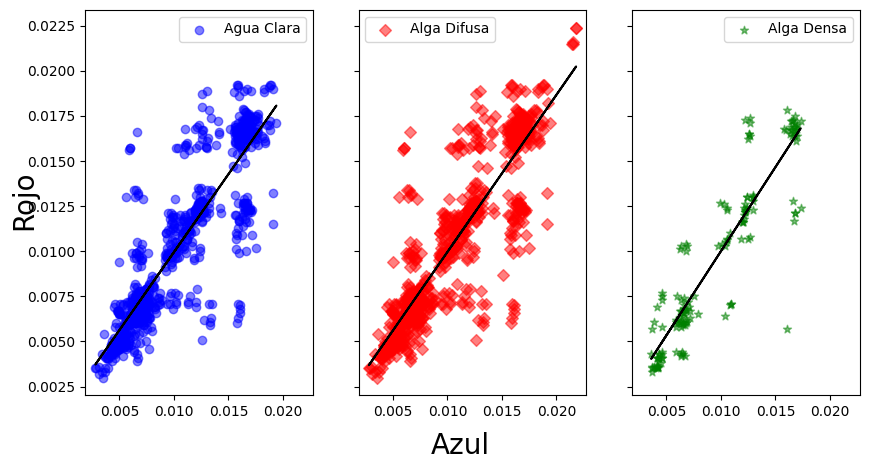

pass
[0.80436442 0.00163229] [0.81956746 0.00150857] [0.78829114 0.0020722 ]


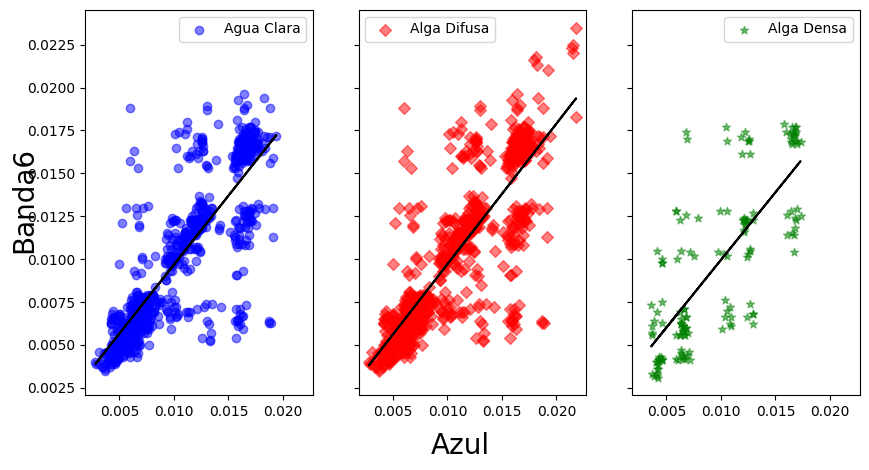

pass
[0.81797008 0.00134524] [0.83486371 0.00123313] [0.5985983  0.00394219]


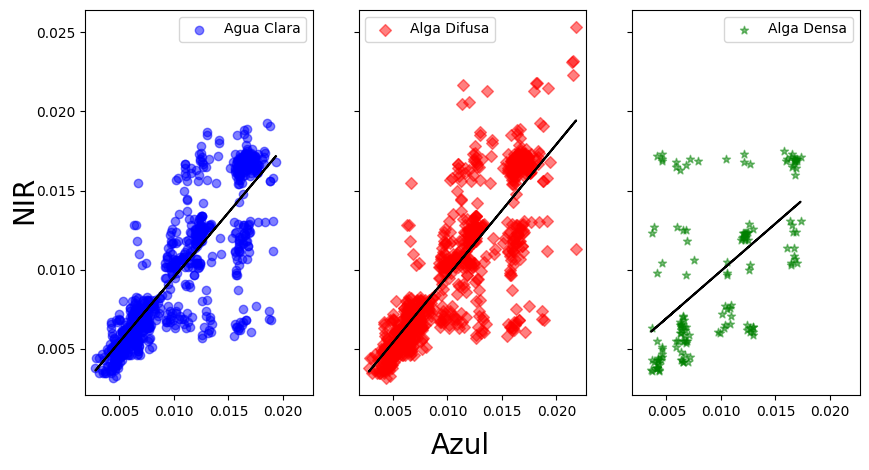

pass
[8.89065638e-01 8.60060154e-04] [9.04602336e-01 7.62397581e-04] [0.78921977 0.0019898 ]


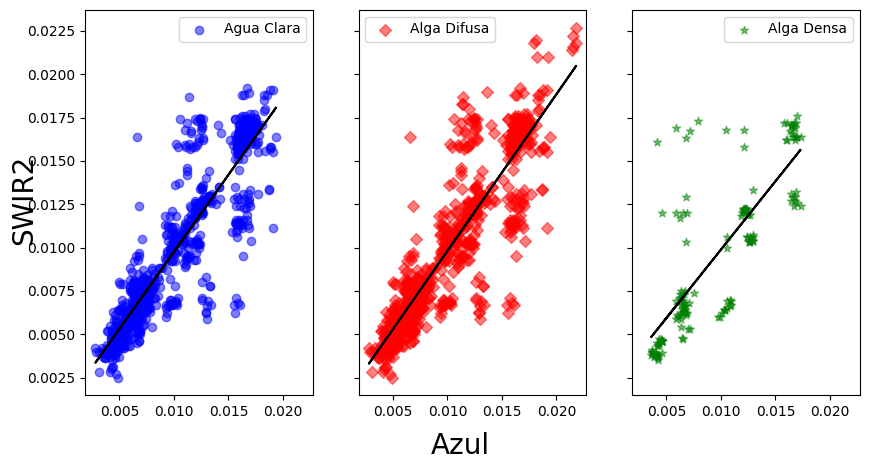

[0.87879155 0.00108629] [0.88978716 0.00101708] [0.85319865 0.00136091]


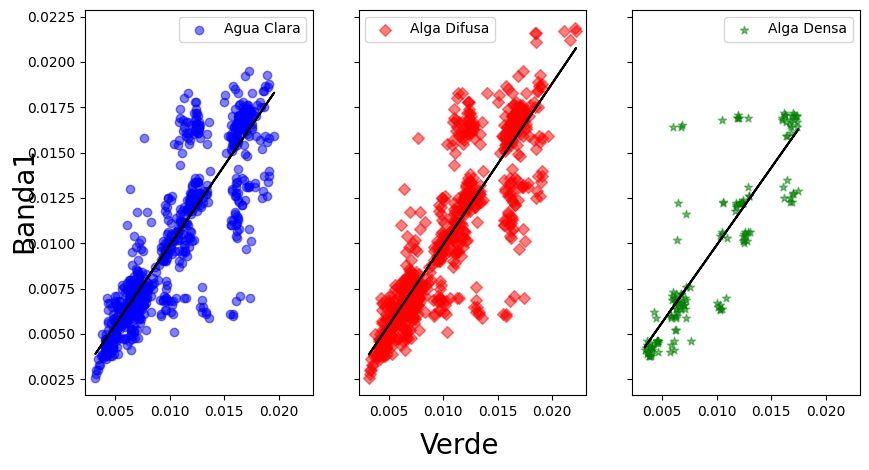

pass
pass
pass
pass
[0.81168066 0.00139429] [0.82328813 0.00131055] [0.65032998 0.00345002]


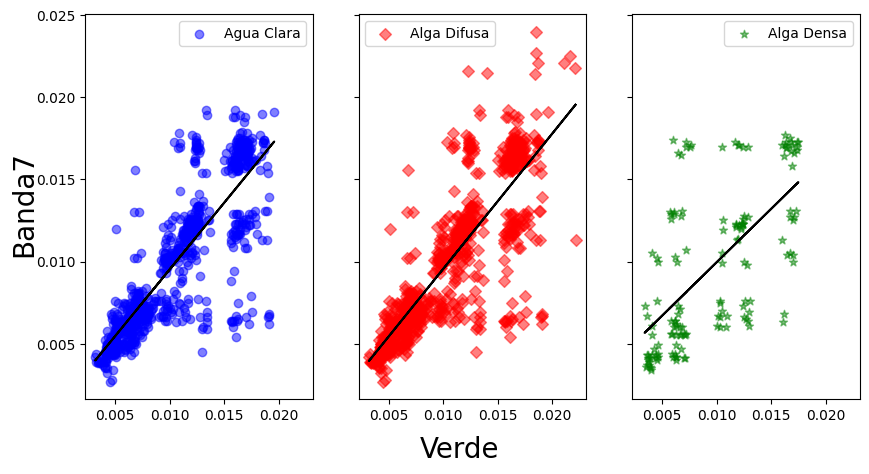

pass
pass
pass
pass
[0.89160035 0.00117309] [0.8925323  0.00118167] [0.87763701 0.00115297]


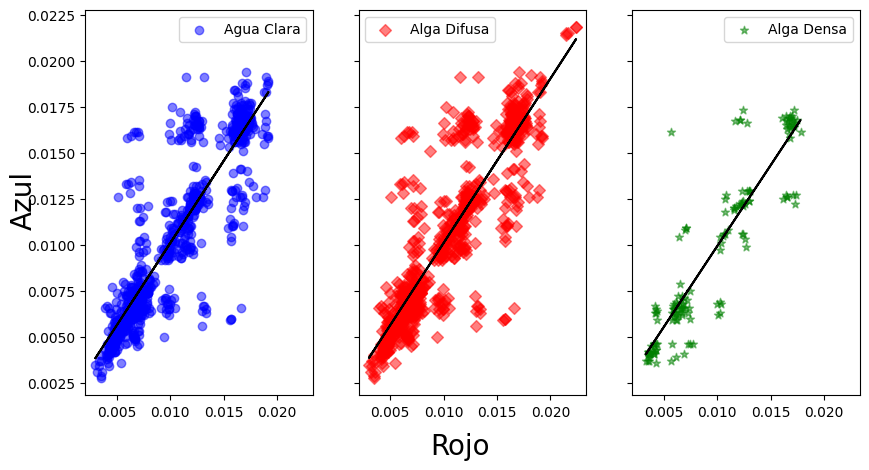

pass
pass
[0.86484981 0.00108473] [0.87542563 0.00100433] [0.81714051 0.0017725 ]


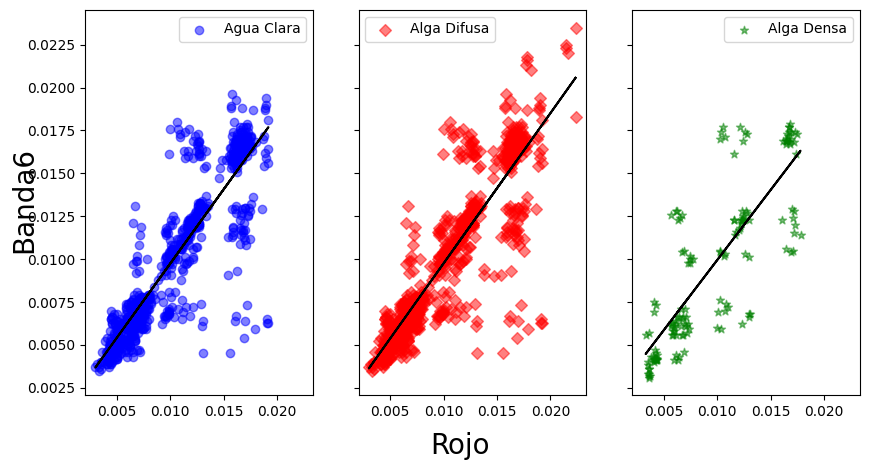

pass
[0.82528267 0.00133564] [0.83949624 0.00125427] [0.58668977 0.00404076]


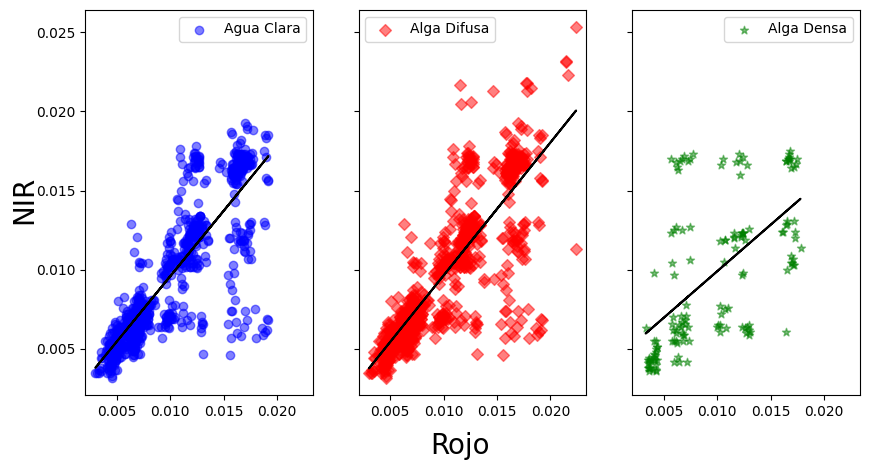

pass
[0.84300549 0.00139497] [0.85772225 0.00131632] [0.71067526 0.00272588]


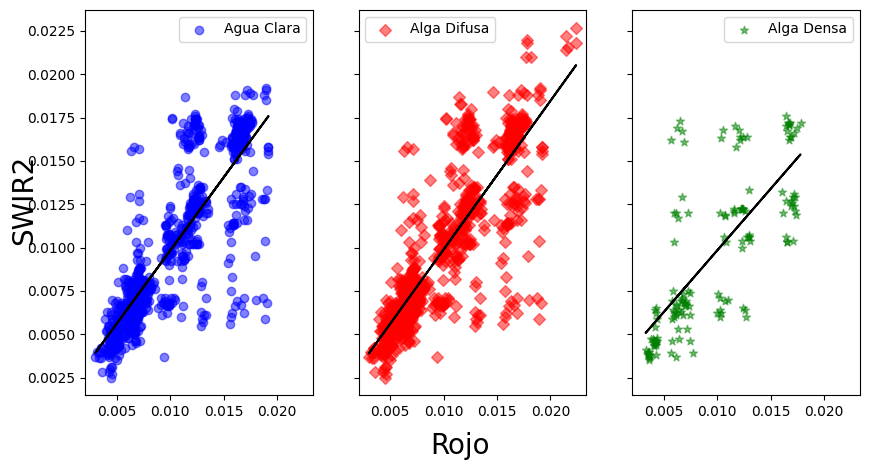

pass
pass
pass
pass
pass
pass
pass
pass
pass
pass
[0.8566614  0.00176568] [0.85057171 0.00184088] [0.72302198 0.00263782]


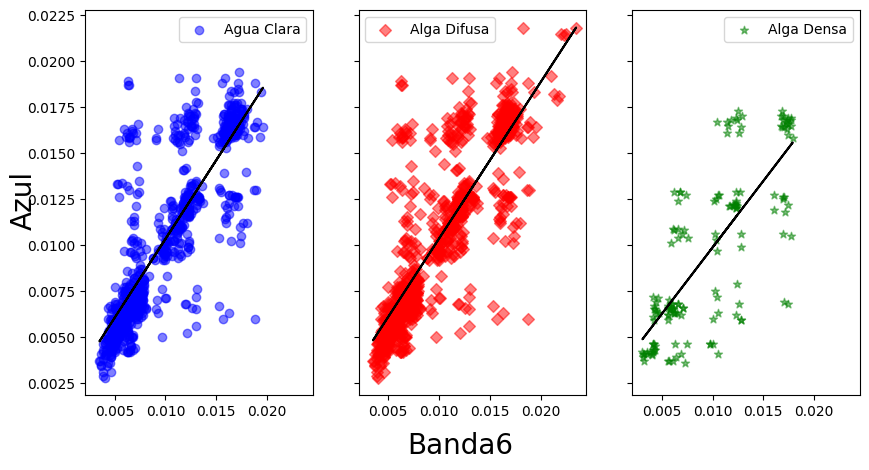

pass
[0.89317977 0.00132863] [0.88702698 0.00139564] [0.79651403 0.00195556]


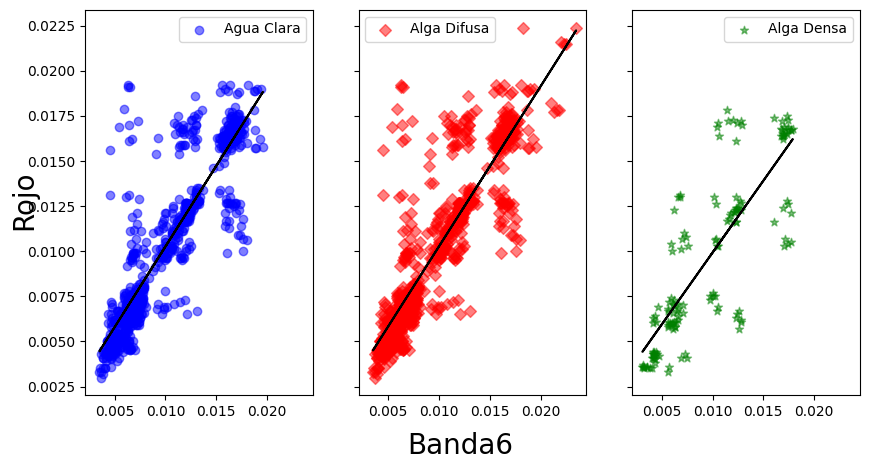

pass
pass
[0.88505508 0.00097985] [0.897698   0.00090139] [0.79877327 0.00198817]


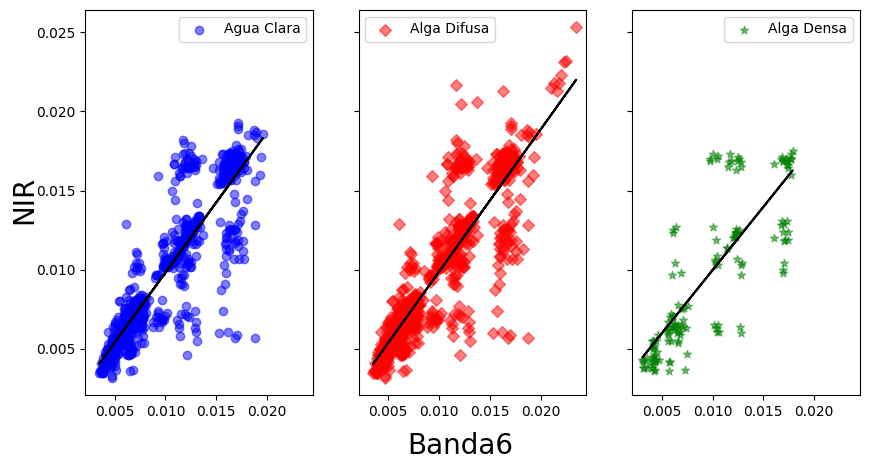

pass
[0.8702558  0.00136343] [0.88069286 0.00131932] [0.78281138 0.00202321]


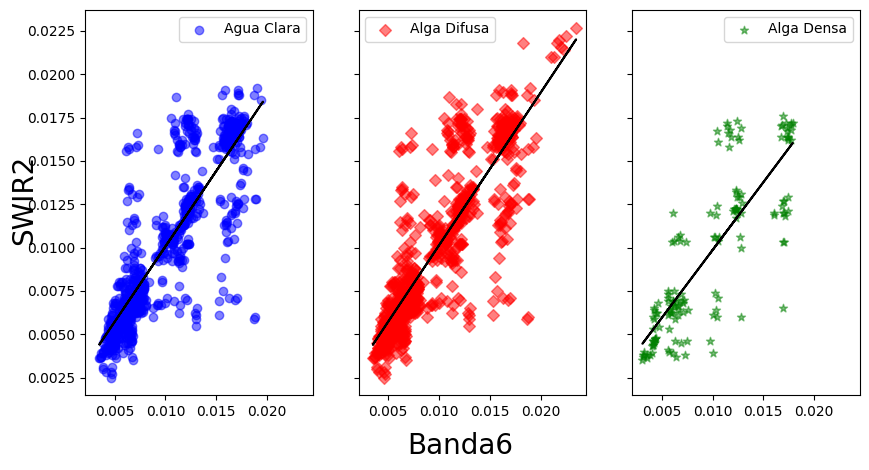

[0.87720368 0.00157186] [0.8742561  0.00163423] [0.71216957 0.00265903]


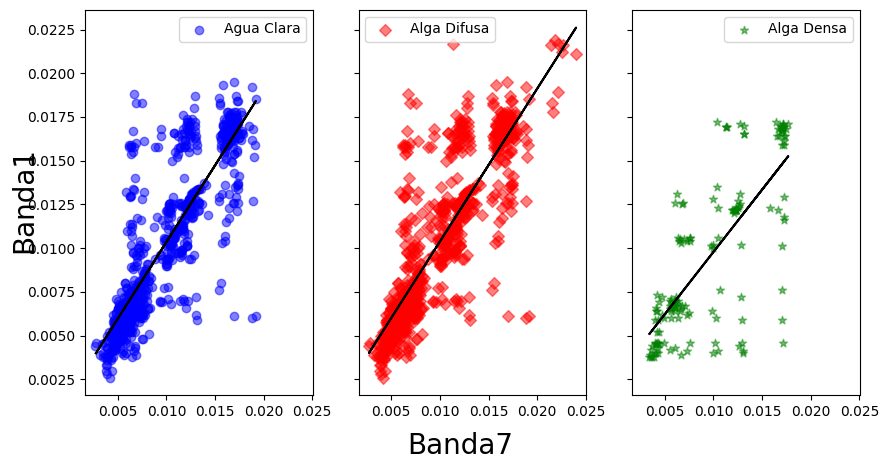

pass
[0.86737193 0.00182279] [0.84955338 0.00200316] [0.61053096 0.00369842]


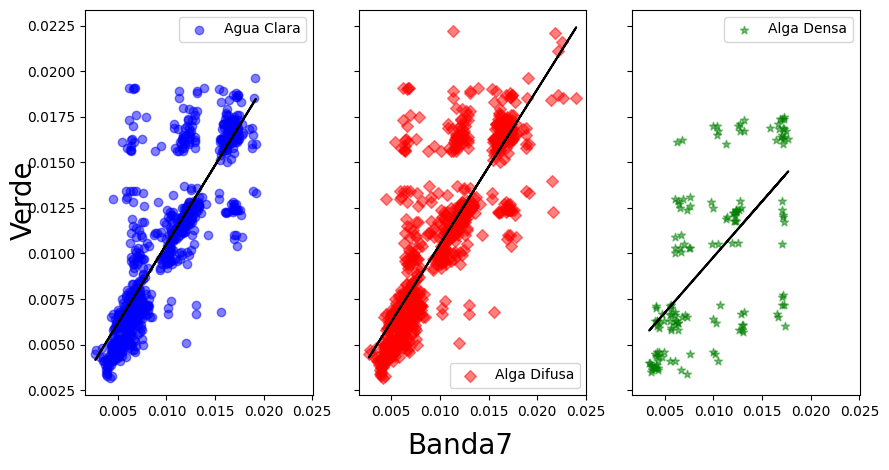

pass
pass
pass
pass
pass
pass
pass
[0.86913209 0.00177241] [0.84197868 0.00202556] [0.56005199 0.00418556]


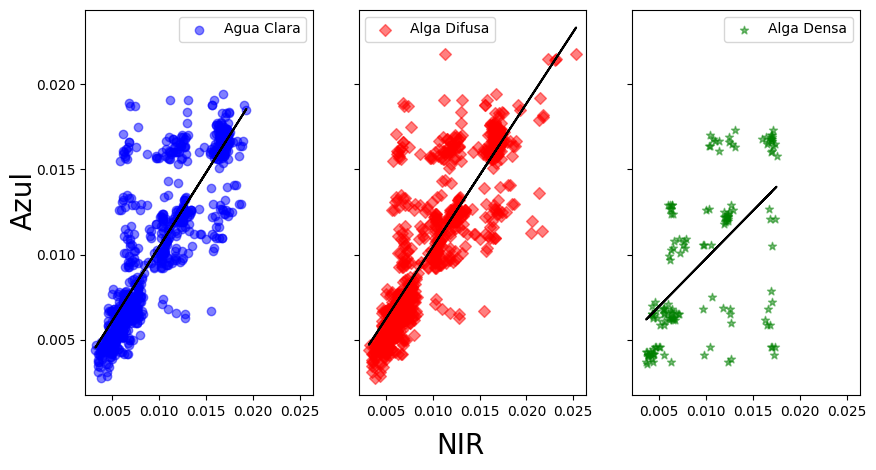

pass
[0.85034064 0.00187556] [0.8266004  0.00209484] [0.5833554  0.00398675]


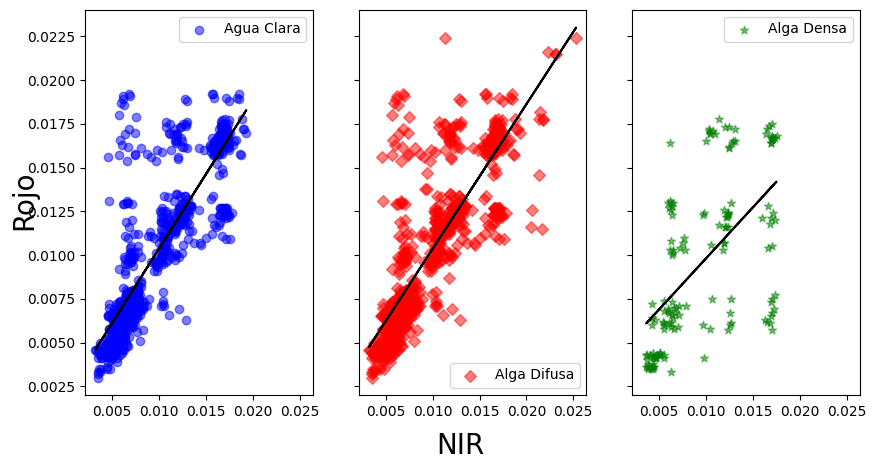

pass
[0.8830033  0.00127982] [0.87234755 0.00137425] [0.81480095 0.00175073]


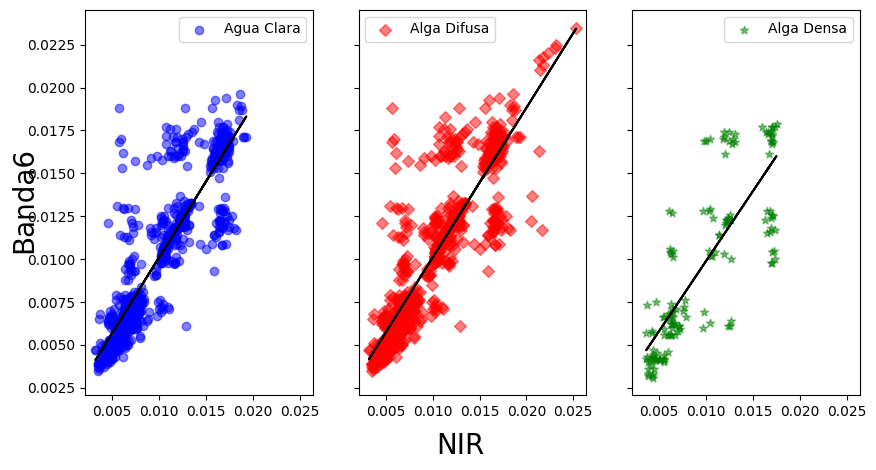

pass
pass
[0.92052154 0.00100674] [0.91576927 0.00107768] [0.80390615 0.00178293]


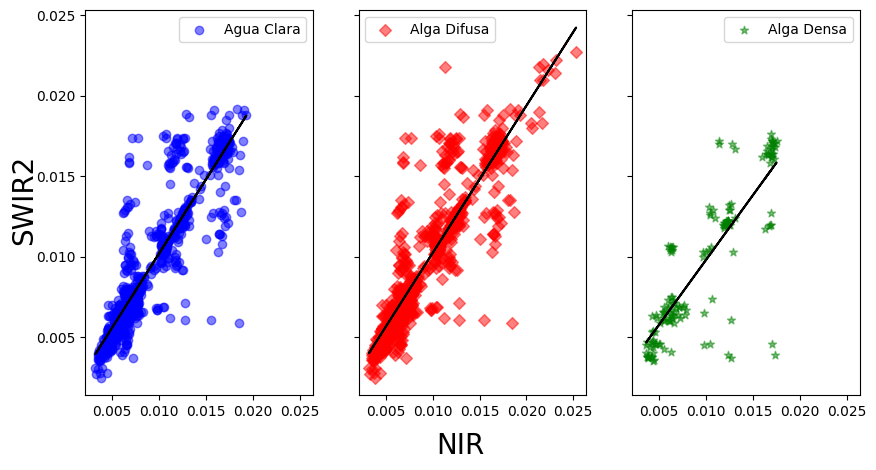

pass
pass
pass
pass
pass
pass
pass
pass
pass
pass
[0.90471822 0.00121276] [0.89008205 0.00133083] [0.78875487 0.0020612 ]


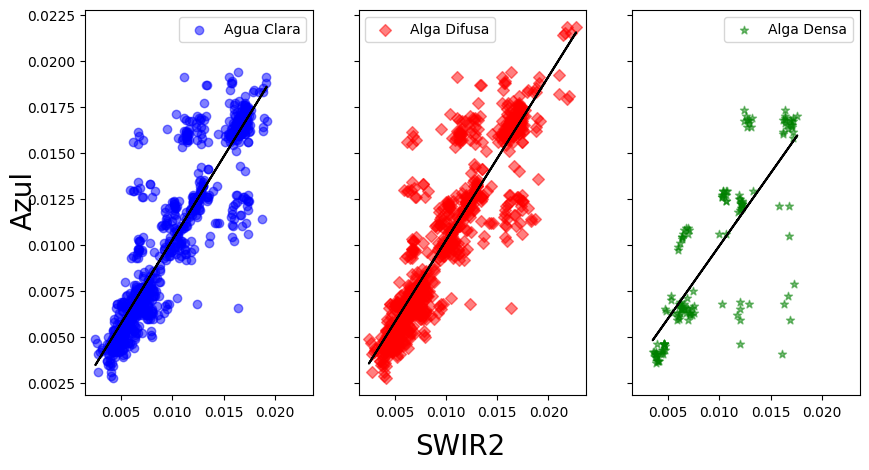

pass
[0.83186289 0.001856  ] [0.82396802 0.00191597] [0.75482649 0.00241345]


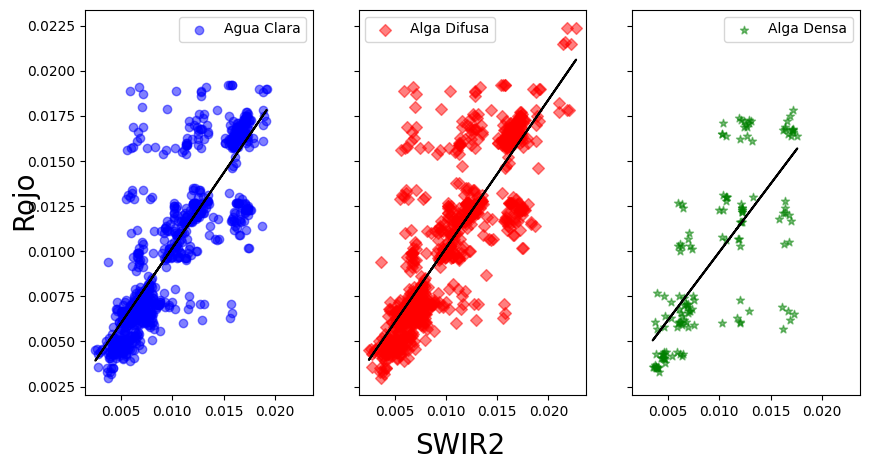

pass
[0.83151501 0.00157952] [0.83496945 0.00153467] [0.85297514 0.00148201]


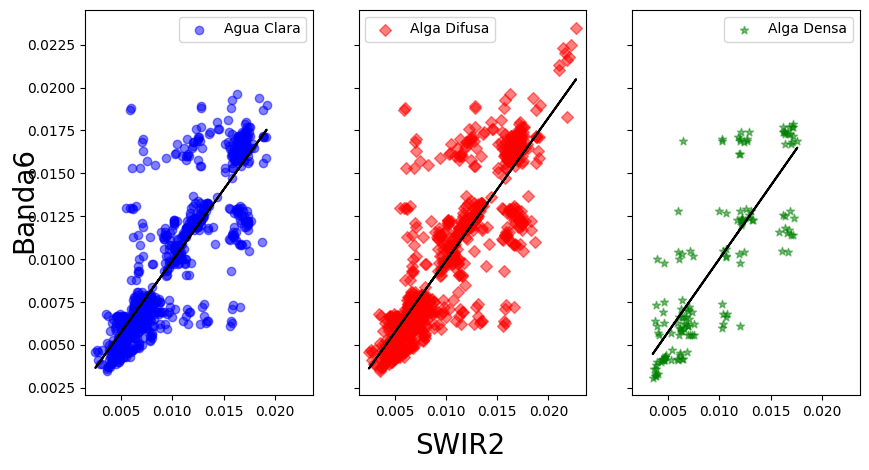

pass
[0.88158684 0.00093485] [8.93455423e-01 8.26736312e-04] [0.85872991 0.00147245]


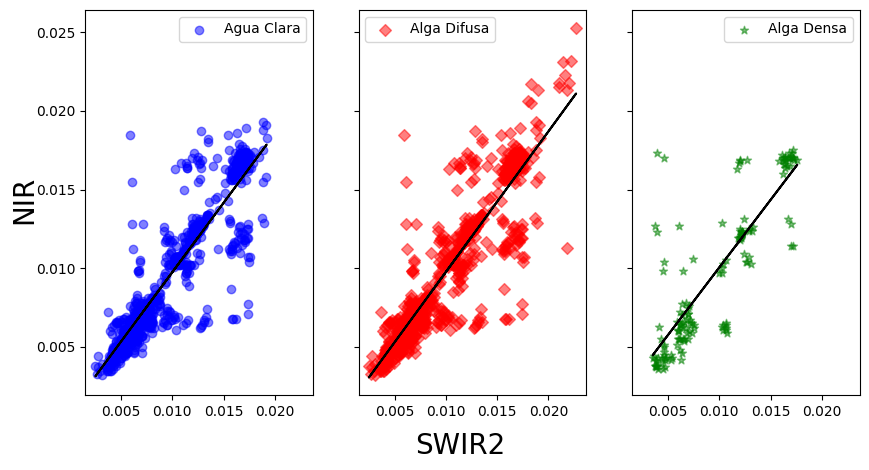

pass


In [46]:
pen1 = []
pen2 = []
pen3 = []
for i in bandas_pos:
    for j in bandas_pos:
        if i!=j:
            try:
                banda1 = bandas_pos[i]
                banda2 = bandas_pos[j]

                fig, ax = plt.subplots(1, 3, figsize = (10,5), sharex = True, sharey = True)

                aux1 = aa[banda1][aa[banda1]!=0]
                aux2 = aa[banda2][aa[banda2]!=0]

                aux3 = ddif[banda1][ddif[banda1]!=0]
                aux4 = ddif[banda2][ddif[banda2]!=0]

                aux5 = dden[banda1][dden[banda1]!=0]
                aux6 = dden[banda2][dden[banda2]!=0]

                popt1, pcov1 = curve_fit(lineal, aux1, aux2)
                popt2, pcov2 = curve_fit(lineal, aux3, aux4)
                popt3, pcov3 = curve_fit(lineal, aux5, aux6)

                print(popt1, popt2, popt3)
                
                pen1.append(popt1[0])
                pen2.append(popt2[0])
                pen3.append(popt3[0])
                
                # ax[0].scatter(aa[banda1],aa[banda2], label = 'Agua Clara', color = 'b', alpha = 0.5, marker = 'o')
                ax[0].scatter(aux1,aux2, label = 'Agua Clara', color = 'b', alpha = 0.5, marker = 'o')
                ax[0].plot(aux1, lineal(aux1, popt1[0], popt1[1]), 'k')
                # ax[1].scatter(ddif[banda1],ddif[banda2], label = 'Alga Difusa', color = 'r', alpha = 0.5, marker = 'D')
                # ax[2].scatter(dden[banda1],dden[banda2], label = 'Alga Densa', color = 'g', alpha = 0.5, marker = '*')
                ax[1].scatter(aux3,aux4, label = 'Alga Difusa', color = 'r', alpha = 0.5, marker = 'D')
                ax[1].plot(aux3, lineal(aux3, popt2[0], popt2[1]), 'k')

                ax[2].scatter(aux5,aux6, label = 'Alga Densa', color = 'g', alpha = 0.5, marker = '*')
                ax[2].plot(aux5, lineal(aux5, popt3[0], popt3[1]), 'k')

                ax[0].legend()
                ax[1].legend()
                ax[2].legend()
                
                fig.supxlabel(i, size = 20, y = -0.02)
                fig.supylabel(j, size = 20, x = 0.05)
                plt.show()
            except:
                plt.close()
                print('pass')

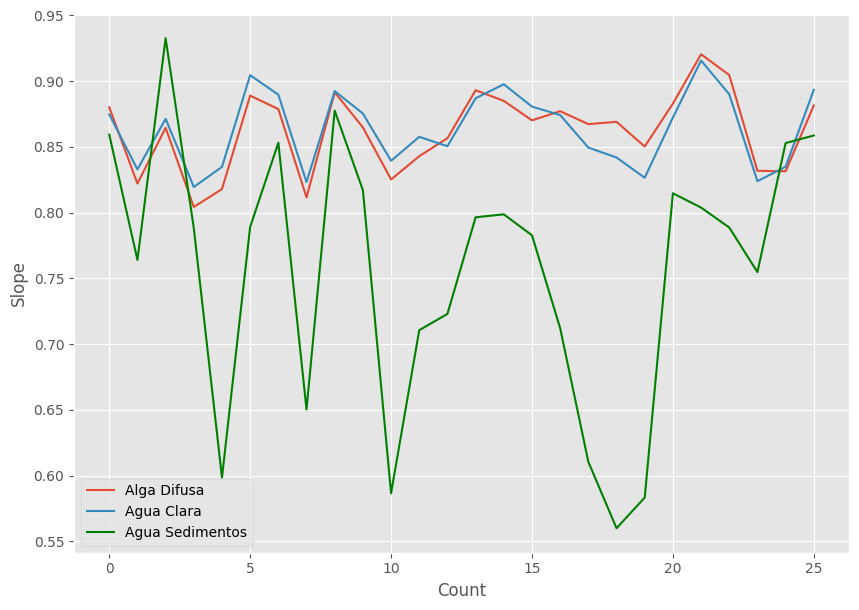

In [47]:
plt.figure(figsize = (10,7))
plt.style.use('ggplot')
plt.plot(pen1, label = Clases[0])
plt.plot(pen2, label = Clases[1])
plt.plot(pen3, label = Clases[2], color = 'g')
plt.legend()
plt.ylabel('Slope')
plt.xlabel('Count')
plt.style.use('default')

----------
## Indices

In [48]:
#Calculate NDVI
def ndvi(array, bandaR, bandaNIR, factor): 
    red = np.asarray(array[bandaR])/factor
    nir = np.asarray(array[bandaNIR])/factor
    
    return (nir-red)/(nir+red)

#Calculate NDWI
def ndwi(array, bandaG, bandaNIR,factor): 
    green = np.asarray(array[bandaG])/factor
    nir = np.asarray(array[bandaNIR])/factor
    
    return (green - nir)/(nir+green)

def indice(array, banda1, banda2, factor): #the first band should be the one being added in the numerator
    aux1 = np.asarray(array[banda1])/factor
    aux2 = np.asarray(array[banda2])/factor
    
    return (aux1-aux2)/(aux1+aux2)

In [49]:
import cmasher as cmr

new_cmap = cmr.get_sub_cmap('ocean_r', 0.1, 1)

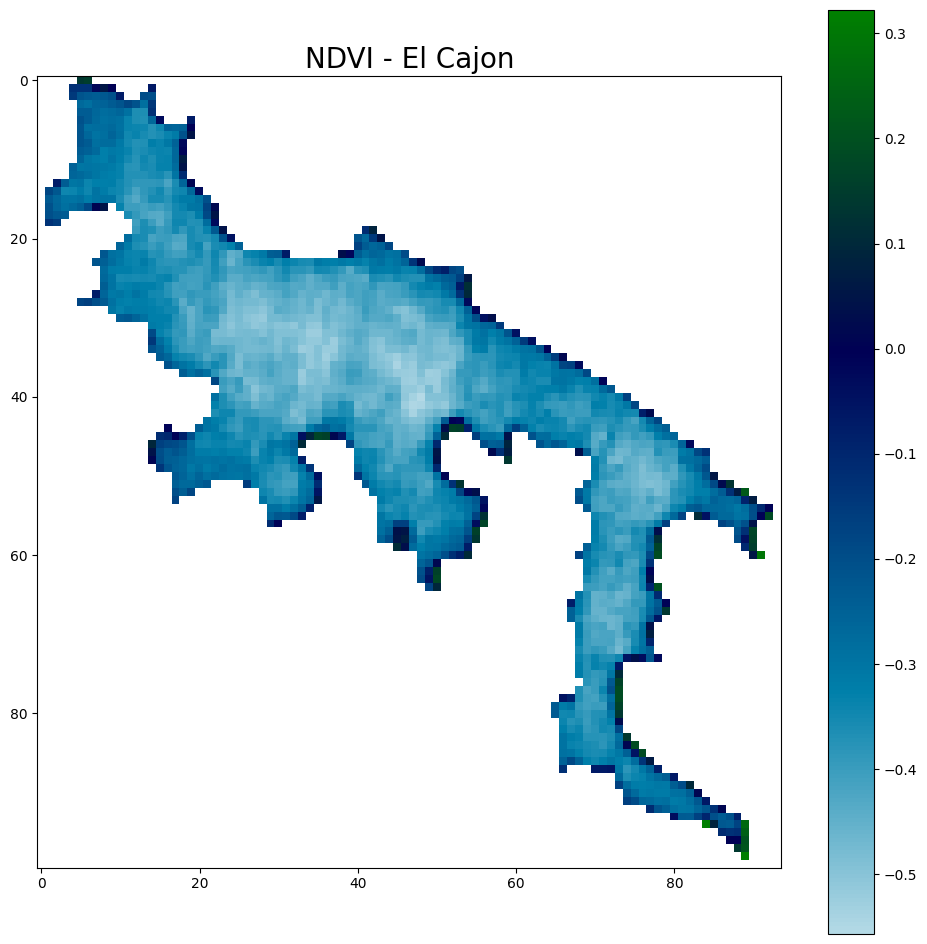

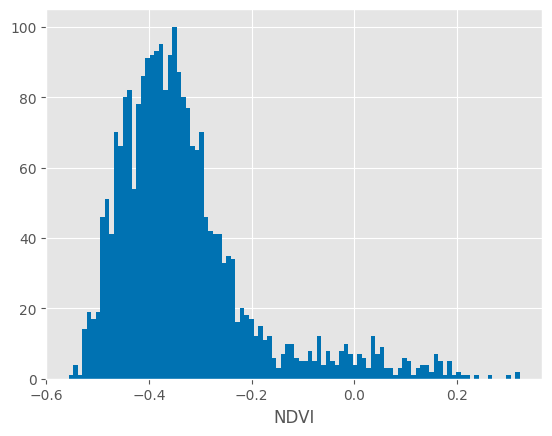

In [50]:
bandaR = bandas_pos['Rojo']
bandaNIR = bandas_pos['NIR']
# Documentos Facultad - Conicet/Cursos/Tele - UNSAM/Scipts/Plots
plt.figure(figsize=(12,12))
plt.imshow(ndvi(s2_mask, bandaR, bandaNIR, 10000), cmap=new_cmap)#, vmax = 0.6)
plt.colorbar()
plt.title('NDVI - '+nombre,  fontsize = 20)


plt.style.use('ggplot')
plt.figure()
plt.hist(ndvi(s2_mask,bandaR, bandaNIR, 10000).flatten(), 100, color = "#0072B2");
plt.xlabel('NDVI')
# # plt.savefig('Plots/ndvi_'+nombre+'.png', dpi = 300)
plt.style.use('default')

# plt.figure(figsize=(12,12))
# plt.imshow(ndwi(s2_mask,1,6,10000), cmap='ocean')
# plt.colorbar()
# plt.title('NDWI - '+nombre,  fontsize = 20)

# os.chdir("D:\\Documentos Facultad - Conicet\Cursos\Tele - UNSAM\Scipts")
# plt.savefig('Plots/ndwi_'+nombre+'.png', dpi = 300)
# os.chdir("C:\\Users\\arell\\Documents\\Sentinel")

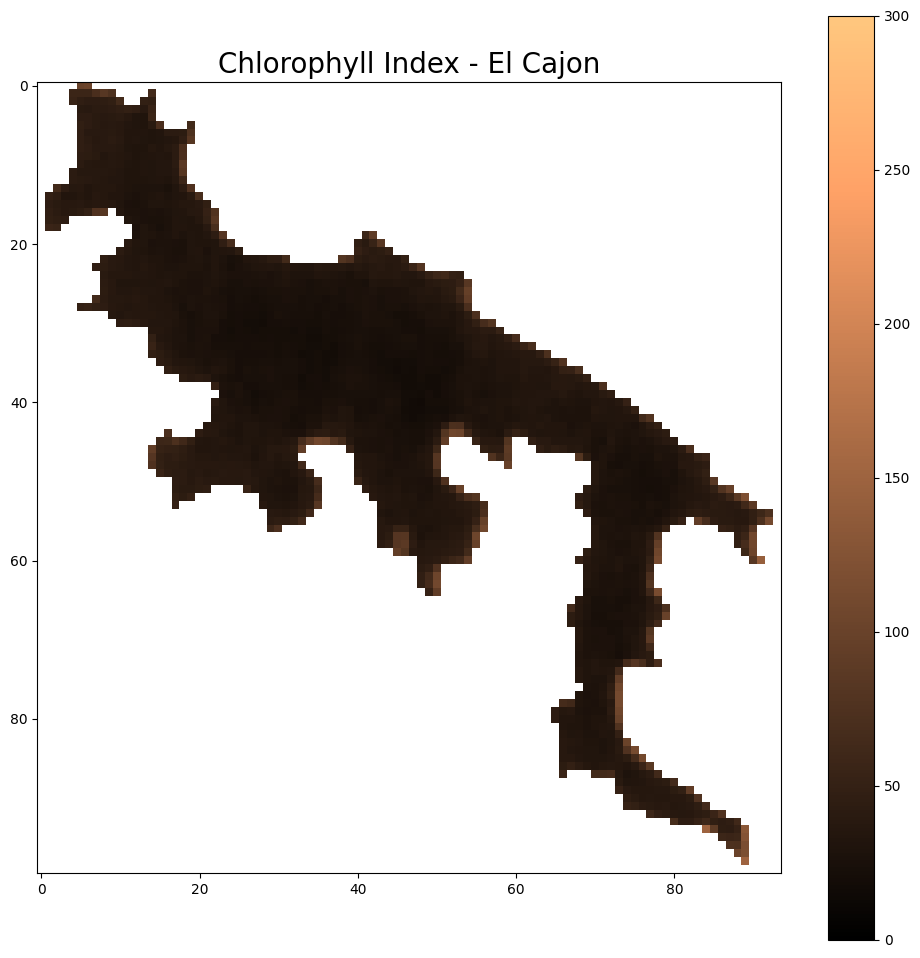

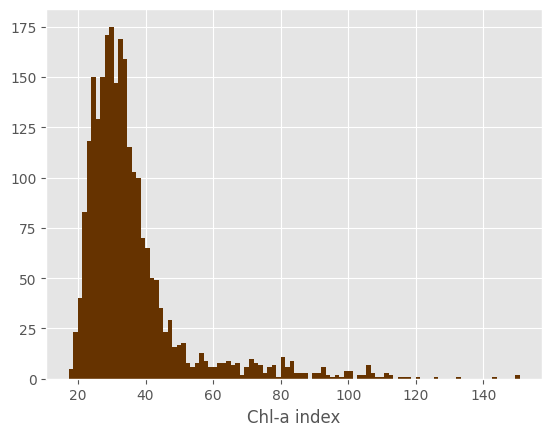

In [51]:
s2_nir = s2_mask[bandaNIR]/10000
s2_red = s2_mask[bandaR]/10000
clorofila = -5.57 + 80.13*(s2_nir/s2_red)

plt.figure(figsize = (12,12))
plt.imshow(clorofila, cmap = 'copper', vmin = 0, vmax = 300)
plt.title('Chlorophyll Index - '+nombre,  fontsize = 20)
plt.colorbar()

plt.style.use('ggplot')
plt.figure()
plt.hist(clorofila.flatten(), bins = 100, color = "#663300");
plt.xlabel('Chl-a index')
plt.style.use('default')

In [52]:
import matplotlib.colors as colors

In [53]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

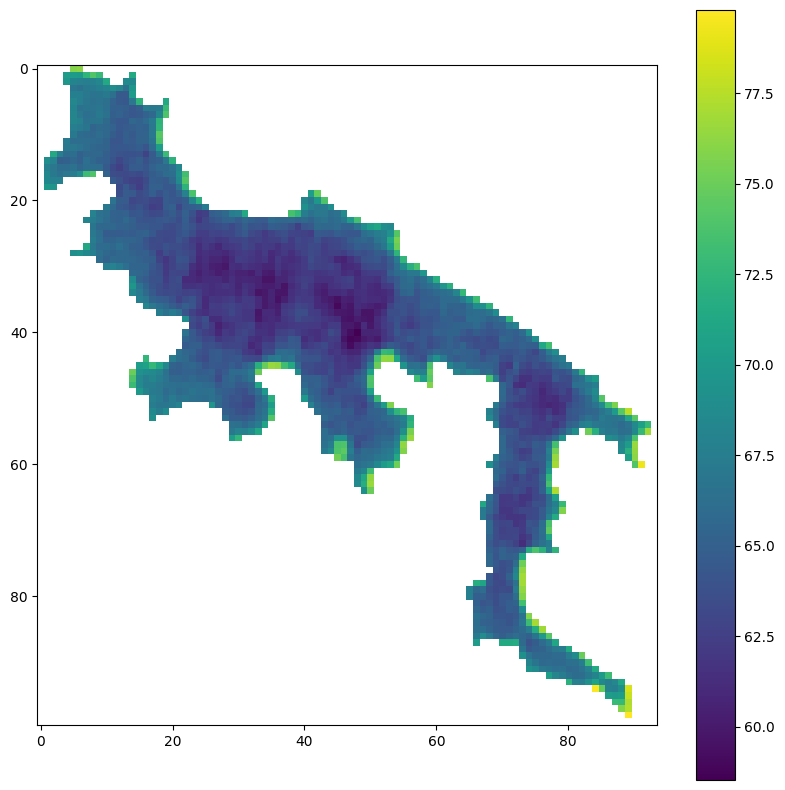

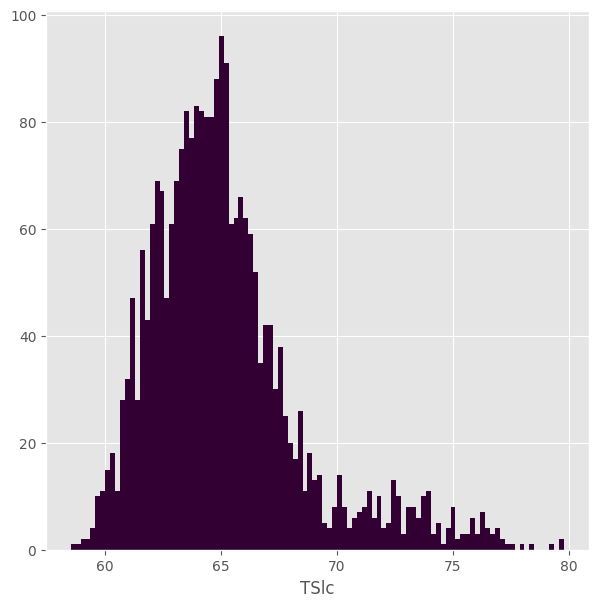

In [54]:
# colors = ['blue',
#           'green',
#           'yellow',
#           'orange',
#          'red']

# cmap = plt.get_cmap('gist_rainbow_r')
# new_cmap = truncate_colormap(cmap, 0.2, 0.8)

# import cmasher as cmr

# new_cmap = cmr.get_sub_cmap('gist_rainbow_r', 0.2, 1)

plt.figure(figsize = (10,10))
plt.imshow(30.6+9.81*np.log(clorofila), cmap = 'viridis')
plt.colorbar()

plt.style.use('ggplot')
plt.figure(figsize = (7,7))
plt.hist((30.6+9.81*np.log(clorofila)).flatten(), bins = 100, color='#330033');
plt.xlabel('TSlc')
plt.style.use('default')

In [55]:
np.nanmean(30.6+9.81*np.log(clorofila))

np.float64(65.16592082788333)

-------
## Tasseled Cap Transformation

In [56]:
bandas

['Banda1',
 'Azul',
 'Verde',
 'Rojo',
 'Banda5',
 'Banda6',
 'Banda7',
 'NIR',
 'SWIR1',
 'SWIR2']

In [57]:
bandas_pos = {}
for i in range(len(bandas)):
    bandas_pos[bandas[i]] = i
    
bandas_pos

{'Banda1': 0,
 'Azul': 1,
 'Verde': 2,
 'Rojo': 3,
 'Banda5': 4,
 'Banda6': 5,
 'Banda7': 6,
 'NIR': 7,
 'SWIR1': 8,
 'SWIR2': 9}

In [58]:
indicesTC = [bandas_pos['Azul'],bandas_pos['Verde'],bandas_pos['Rojo'],bandas_pos['NIR'],bandas_pos['SWIR1'],bandas_pos['SWIR2']] #North

matriz = []
matriz2 = []
reescalado = 10000
coeficientesS2 = [[0.3510, 0.3813, 0.3437, 0.7196, 0.2396, 0.1949],
                  [-0.3599, -0.3533, -0.4734, 0.6633, 0.0087, -0.2856],
                  [0.2578, 0.2305, 0.0883, 0.1071, -0.7611, -0.5308]] 


for i in indicesTC:
    matriz.append(s2_clip[i]/reescalado)
    matriz2.append(s2_mask[i]/reescalado)
    
[brillo, verdor, humedad] = np.einsum('ij,jkl->ikl', coeficientesS2,matriz)
[brilloM, verdorM, humedadM] = np.einsum('ij,jkl->ikl', coeficientesS2,matriz2)

In [59]:
s2_clip.shape

(10, 100, 94)

In [60]:
brilloM[brilloM==0] = np.nan
verdorM[verdorM==0] = np.nan
humedadM[humedadM==0] = np.nan

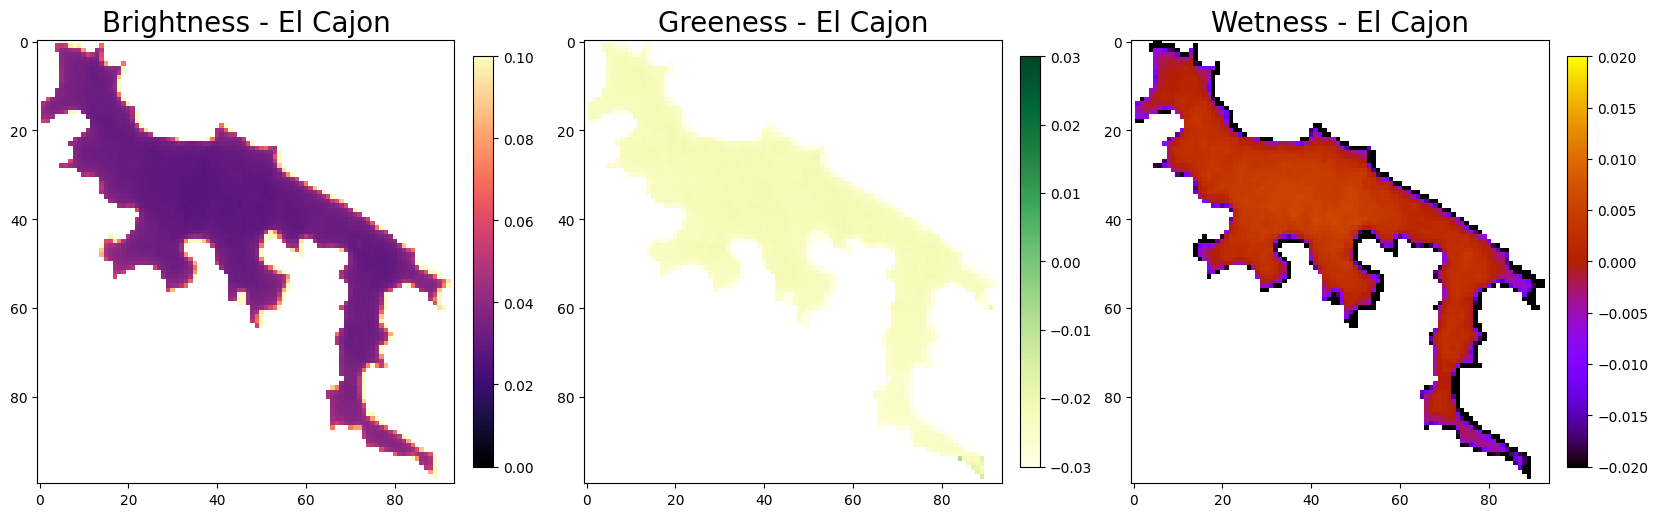

In [61]:
# nombre += '-mask'


fig,ax = plt.subplots(1,3,figsize = (20,12))

masked_arrayB = np.ma.array(brilloM, mask=np.isnan(brilloM))
masked_arrayV = np.ma.array(verdorM, mask=np.isnan(verdorM))
masked_arrayH = np.ma.array(humedadM, mask=np.isnan(humedadM))
                            
ax0 = ax[0].imshow(masked_arrayB, cmap='magma', vmin = 0, vmax = .1)
# ax[0].title.set_text('Brightness - '+nombre, fontsize = 20)
ax[0].set_title('Brightness - '+nombre, fontsize = 20)
plt.colorbar(ax0, ax=ax[0], fraction=0.045, pad=0.04)


ax1 = ax[1].imshow(masked_arrayV, cmap='YlGn', vmin = -.03, vmax = 0.03)
# plt.colorbar()
ax[1].set_title('Greeness - '+nombre, fontsize = 20)
plt.colorbar(ax1, ax=ax[1], fraction=0.045, pad=0.04)

ax2 = ax[2].imshow(masked_arrayH, cmap='gnuplot', vmin = -.02, vmax = 0.02)
ax[2].set_title('Wetness - '+nombre, fontsize = 20)
plt.colorbar(ax2, ax=ax[2], fraction=0.045, pad=0.04)
# plt.savefig('Plots/Wetness_'+nombre+'.png', dpi = 300)



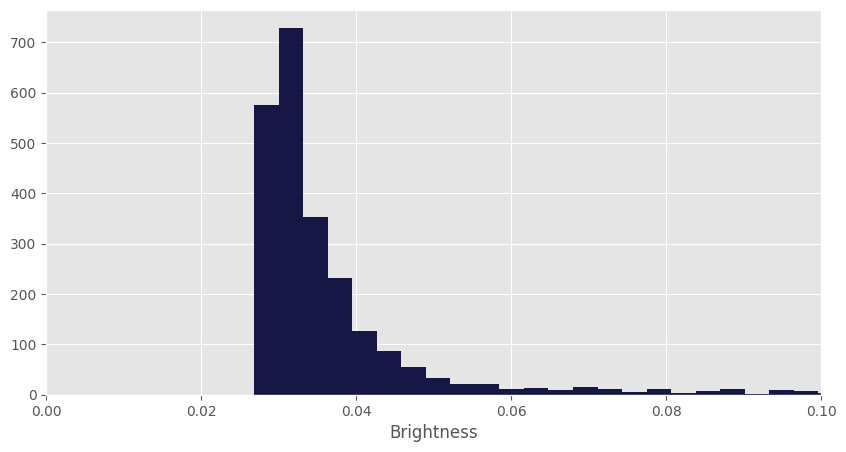

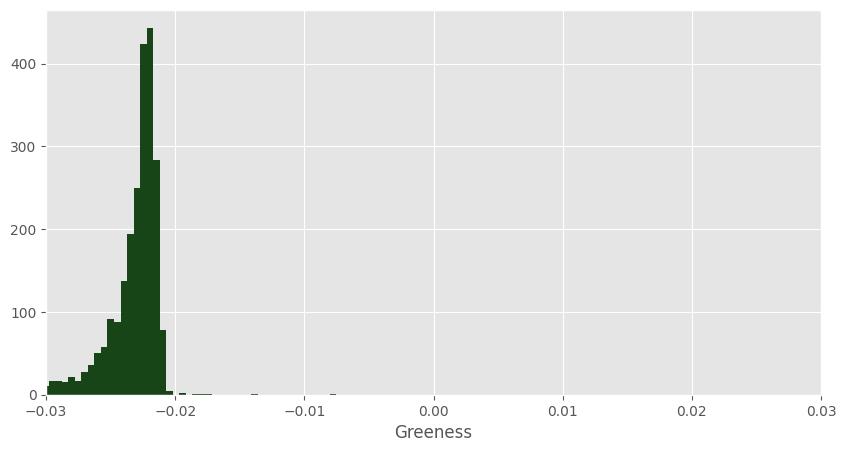

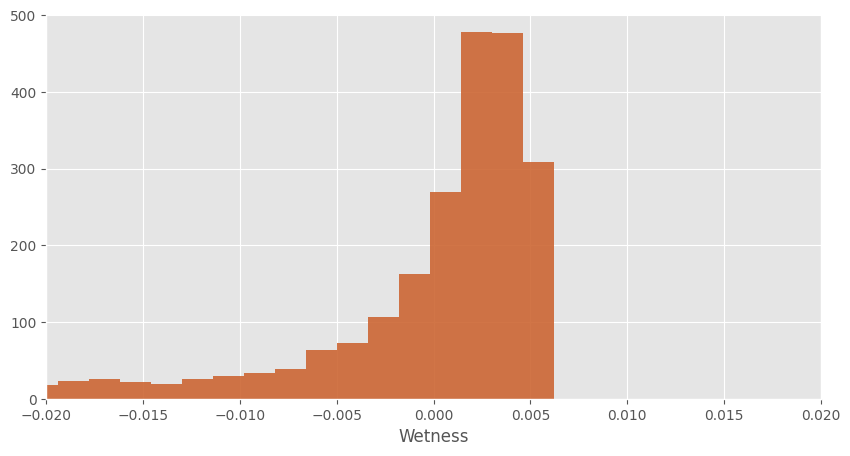

In [62]:
plt.style.use("ggplot")
plt.figure(figsize = (10,5))
plt.hist(brilloM[brilloM!=np.nan].flatten(), 100, alpha = 0.9, color='#000033');
plt.xlabel('Brightness')
# plt.xlim(0.2,0.5)
plt.xlim(0,0.1)


plt.figure(figsize = (10,5))
plt.hist(verdorM[verdorM!=np.nan].flatten(), 100, alpha = 0.9, color='#003300');
plt.xlabel('Greeness')
# plt.xlim(-0.12,0)
plt.xlim(-0.03,0.03)


plt.figure(figsize = (10,5))
plt.hist(humedadM[humedadM!=np.nan].flatten(), 100, alpha = 0.9, color='#cc6633');
plt.xlabel('Wetness')
# plt.xlim(-0.08,-0.01)
plt.xlim(-0.02,0.02)
plt.style.use("default")

In [63]:
aux1 = brilloM.flatten()
# aux1 = aux1[aux1!=np.nan]
aux2 = verdorM.flatten()
aux3 = humedadM.flatten()
# plt.hist(aux1)

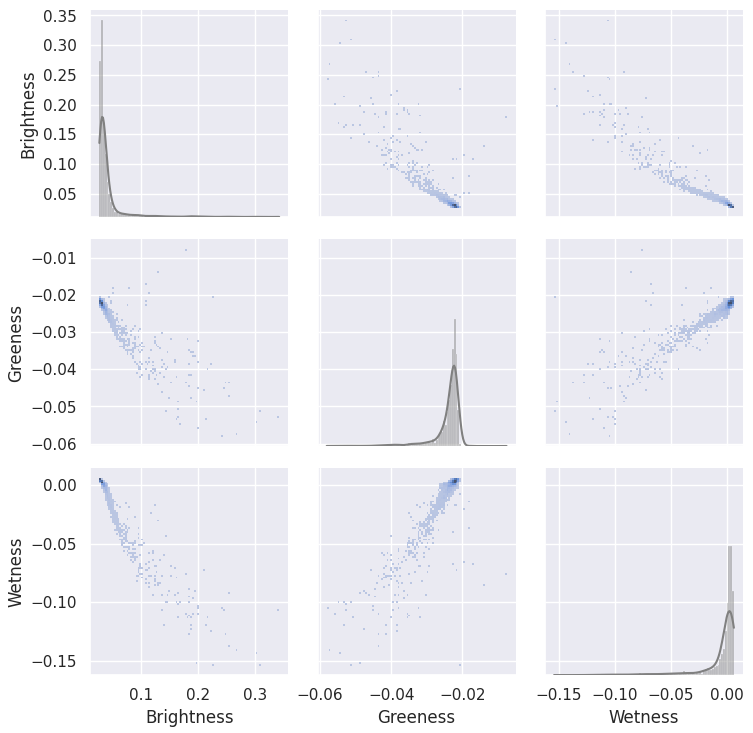

In [64]:
sns.set()
stack_data2 = np.stack((aux1[np.isfinite(aux1)], aux2[np.isfinite(aux2)], aux3[np.isfinite(aux3)])).T
data = pd.DataFrame(stack_data2, columns = ['Brightness','Greeness','Wetness'])

f = sns.PairGrid(data)
# f.fig.suptitle(Nombre, y=1.01, fontsize = 'large')
f.map_upper(sns.histplot)
f.map_lower(sns.histplot)
f.map_diag(sns.histplot, kde=True, color='.5')
# f.set(xlim = (0,0.15), ylim = (0,0.15))
sns.reset_orig

matplotlib.rc_file_defaults()

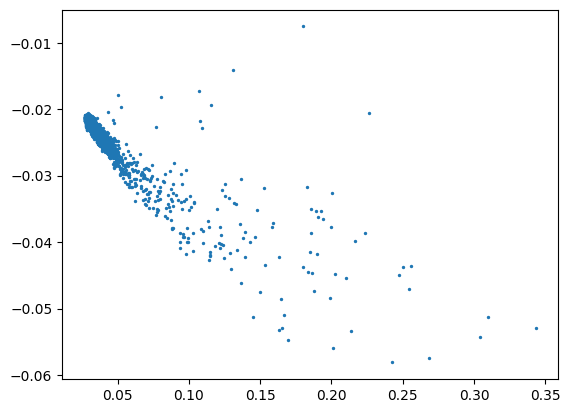

In [65]:
plt.scatter(aux1[np.isfinite(aux1)], aux2[np.isfinite(aux2)], s = 2)

[np.float64(-0.02231667301896429), np.float64(0.004007010555555551)]

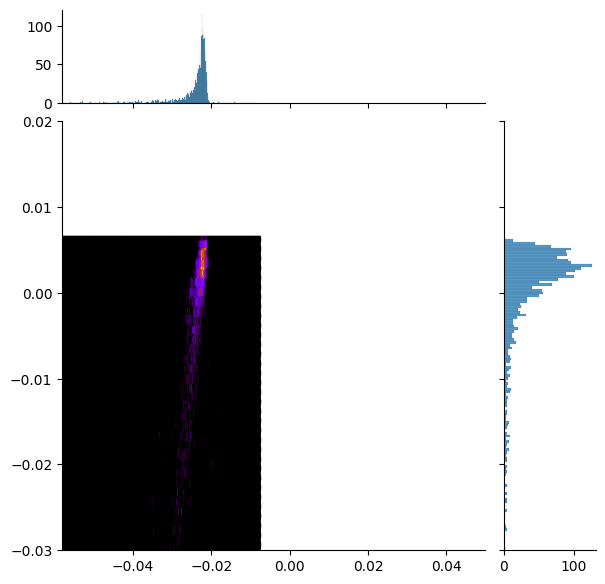

In [66]:
def scatterPar2(array1, array2, bineado = 'auto', ploteo=False, ploteo2 = False, maximo = False, bordes = False, xmin=0, xmax=0, ymin=0, ymax=0):
    joint_kws=dict(gridsize=250)
    g = sns.jointplot(x = array1, y = array2,
                      kind='hex', ratio=4,
                      marginal_ticks=True, marginal_kws=dict(bins=bineado, fill=True), cmap="gnuplot", joint_kws = joint_kws)

    values = g.ax_joint.collections[0].get_array()
    ind_max = values.argmax()
    xy_max = g.ax_joint.collections[0].get_offsets()[ind_max]
    
    if maximo:
        g.ax_joint.text(xy_max[0], xy_max[1], f" Max: {values[ind_max]:.0f}\n x={xy_max[0]:.2f}\n y={xy_max[1]:.2f}",
                        color='lime', ha='left', va='bottom', fontsize=7, fontweight='bold')
        g.ax_joint.axvline(xy_max[0], color='red', lw = 0.5)
        g.ax_joint.axhline(xy_max[1], color='red', lw = 0.5)
    
    if bordes:
        xmin=np.min(array1.flatten())
        g.ax_marg_x.set_xlim(xmin, xmax)
        g.ax_marg_y.set_ylim(ymin, ymax)

    if not ploteo:
        plt.close()
    if ploteo2:
        plt.figure()
        f = sns.kdeplot(array1, array2, fill=True)
        f.text(xy_max[0], xy_max[1], f" Max: {values[ind_max]:.0f}\n x={xy_max[0]:.2f}\n y={xy_max[1]:.4f}",
                        color='lime', ha='left', va='bottom', fontsize=14, fontweight='bold')
        f.axvline(xy_max[0], color='red')
        f.axhline(xy_max[1], color='red')
        plt.tight_layout()

    
    maximos_array1array2 = [xy_max[0], xy_max[1]]
    
    return maximos_array1array2

# scatterPar2(aux1[np.isfinite(aux1)], aux2[np.isfinite(aux2)], bineado = 500, ploteo = True, ploteo2 = False, maximo = False,
#             bordes = True, xmin=np.min(aux1[np.isfinite(aux1)]), xmax=0.4, ymin=-0.14, ymax=0.05)

# scatterPar2(aux1[np.isfinite(aux1)], aux3[np.isfinite(aux3)], bineado = 500, ploteo = True, ploteo2 = False, maximo = False,
#             bordes = True, xmin=np.min(aux1[np.isfinite(aux1)]), xmax=0.4, ymin=-0.1, ymax=0)

scatterPar2(aux2[np.isfinite(aux2)], aux3[np.isfinite(aux3)], bineado = 500, ploteo = True, ploteo2 = False, maximo = False,
            bordes = True, xmin = -0.06, #xmin=np.min(aux1[np.isfinite(aux1)]),
            xmax=.05, ymin=-0.03, ymax=0.02)

-----------
# Unsupervised Classifier
*Kmeans*

In [67]:
from sklearn.cluster import KMeans

In [68]:
# with rasterio.open(path) as src:
#     img = src.read()
#     crs = src.crs
#     gt = src.transform
    
d,x,y = s2_mask.shape
X = s2_mask.reshape([d,x*y]).T
X = X/10000
bandas = ['Banda 1', 'Azul', 'Verde', 'Rojo', 'Banda 5', 'Banda 6', 'Banda 7', 'NIR', 'Banda 9', 'SWIR 1', 'SWIR 2']

In [69]:
X2 = X.astype('float64')
X2[X2==0] = np.nan

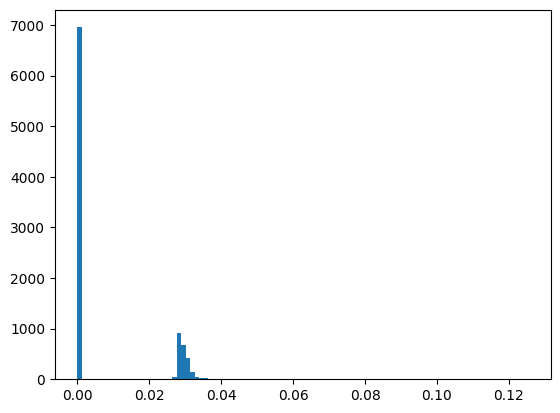

In [70]:
plt.hist(X[:,2], 100);

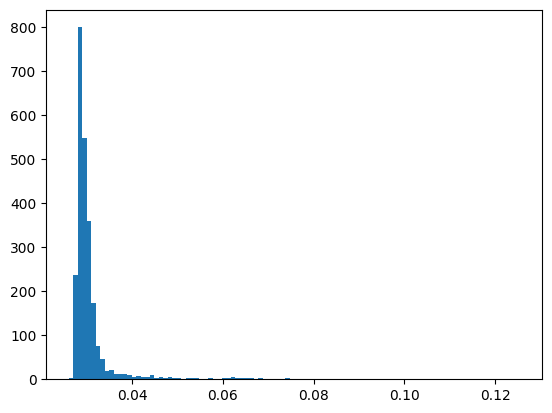

In [71]:
plt.hist(X2[:,2], 100);

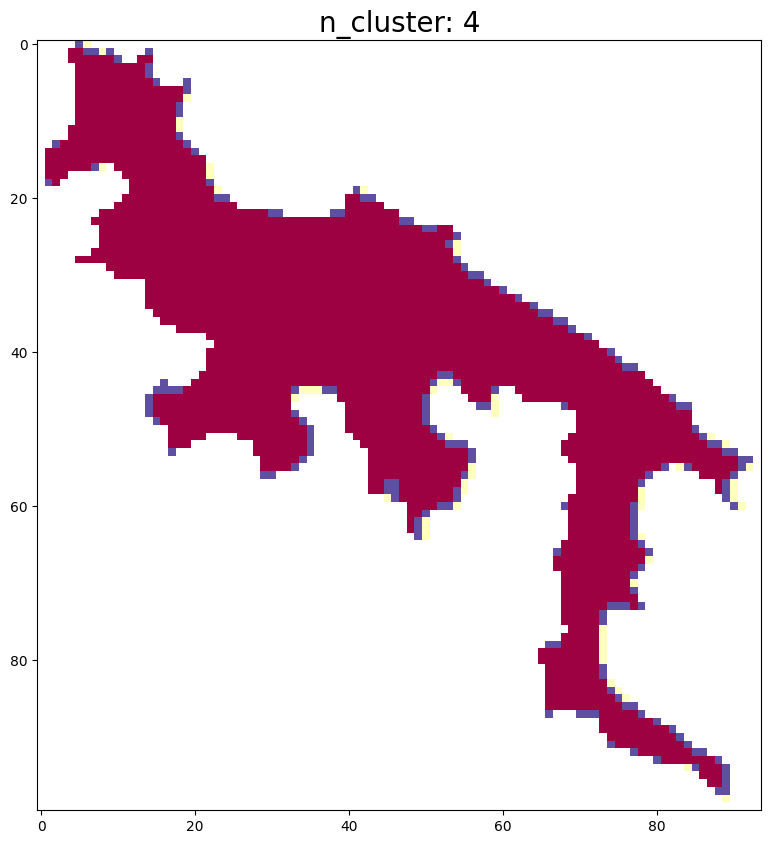

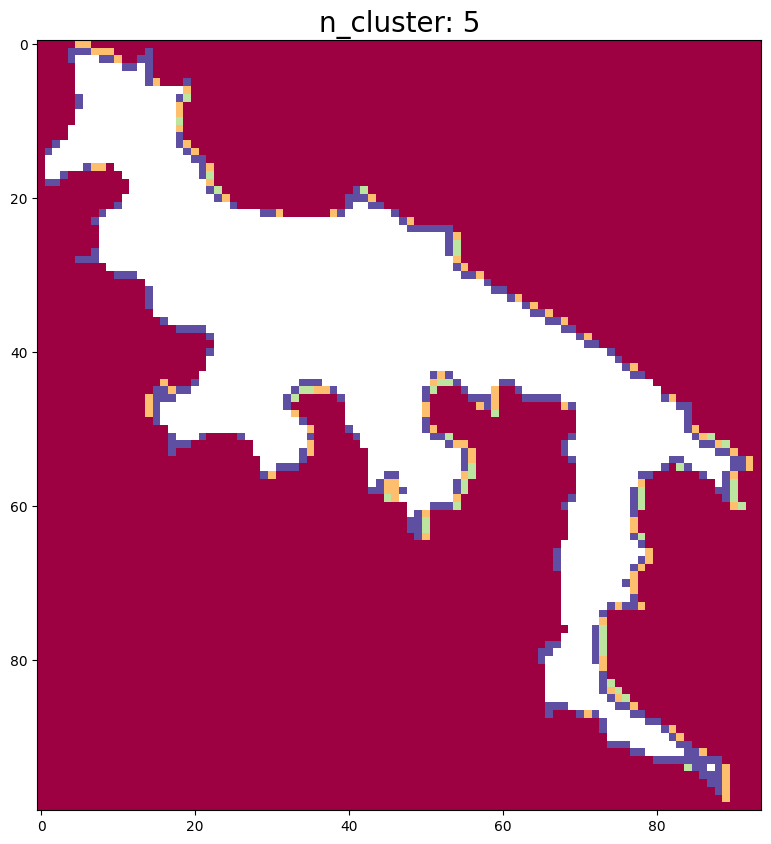

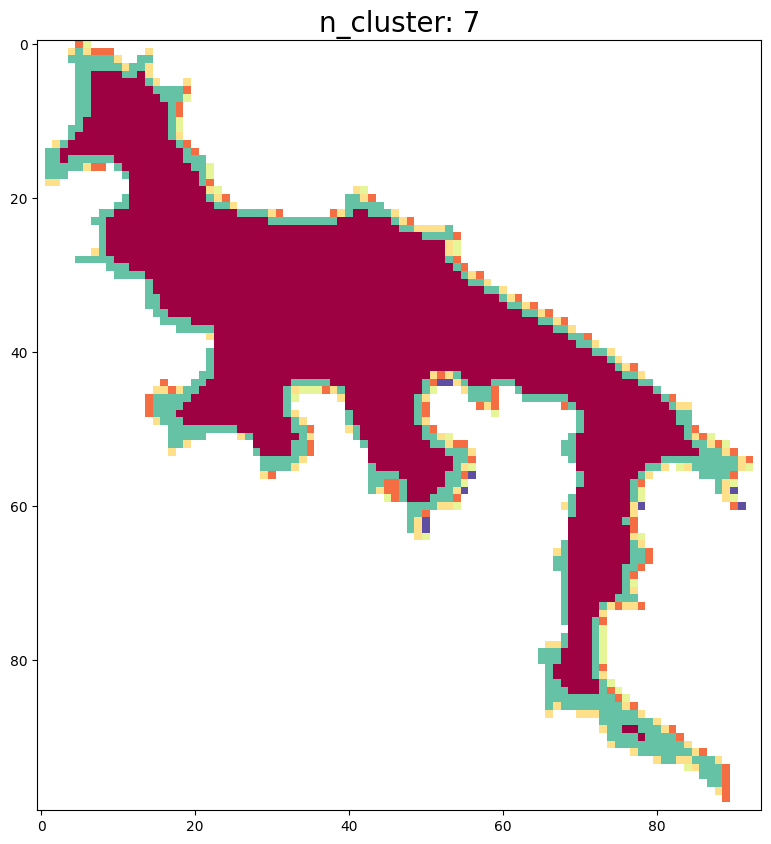

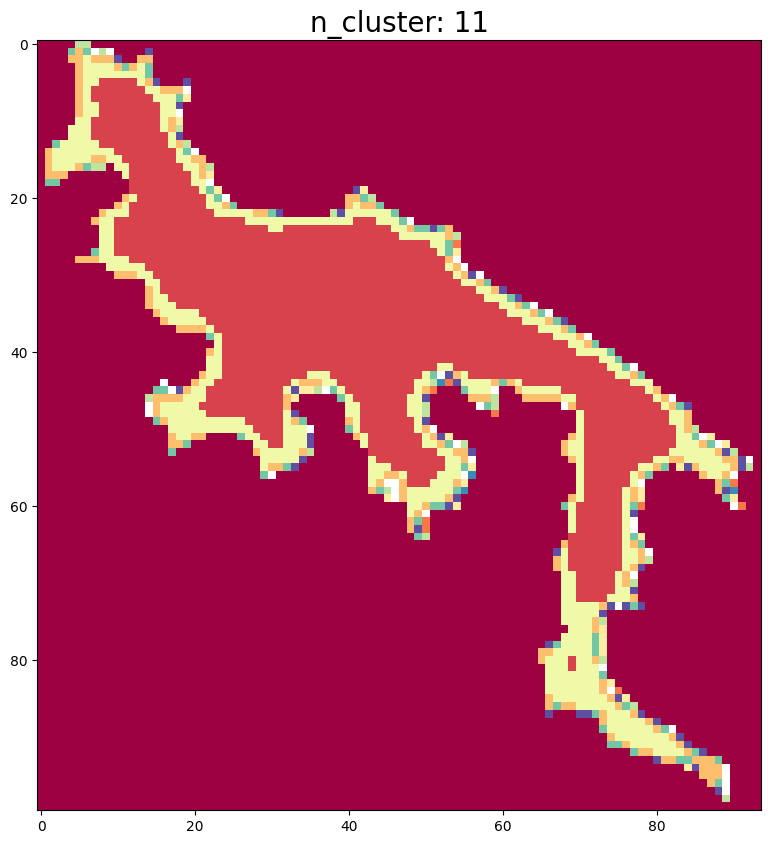

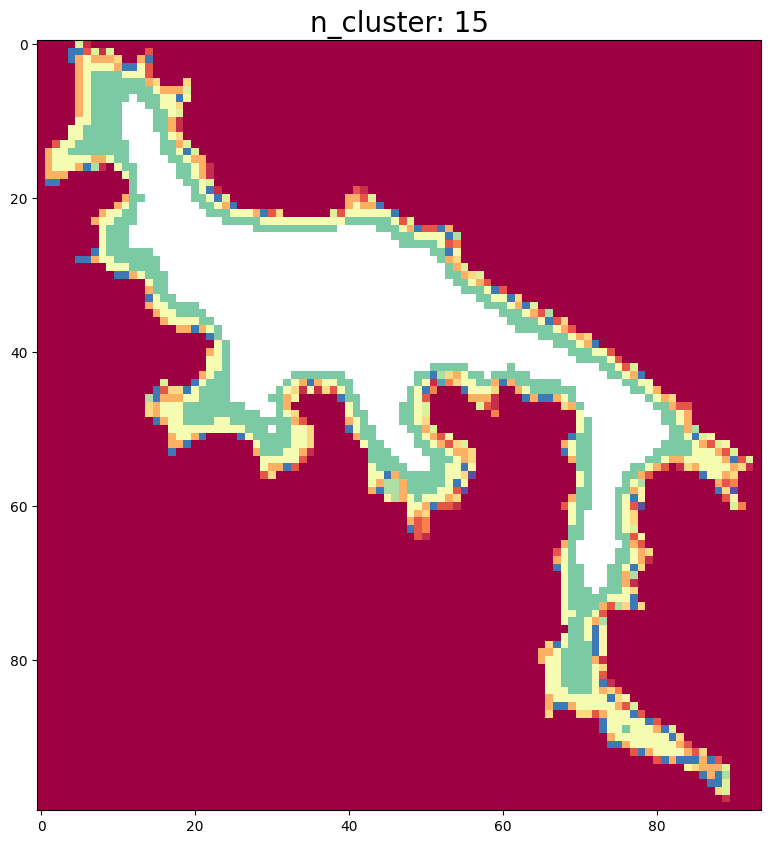

In [72]:
os.makedirs('Plots/plots/kmeans', exist_ok=True)

# centroides = [2,3,4,5,7,9,11]
centroides = [4,5,7,11,15]
for i in centroides:
    kmeans = KMeans(n_clusters=i)#, random_state=0)
    kmeans.fit(X)
    L = kmeans.labels_
    Yimg = L.reshape([x,y])
    Yimg = Yimg.astype('float64')
    Yimg[Yimg==0.] = np.nan
    
    plt.figure(figsize=(15,10))
    plt.title('n_cluster: '+str(i), fontsize = 20)
    plt.imshow(Yimg, cmap='Spectral')
    
    plt.savefig('Plots/plots/kmeans/kmeans-n'+str(i)+'.png', dpi = 200)
    
#     bandx, bandy = 3,7
    
#     X2 = X.astype('float64')
#     X2[X2==0] = np.nan
    
#     df_data = {'X':X2[:,bandx], 'Y':X2[:,bandy],'predicted_label' : []}
#     df_data['predicted_label'] = kmeans.labels_.astype(int)
#     data = pd.DataFrame.from_dict(df_data)

#     sns.scatterplot(x="X", y="Y", hue="predicted_label", 
#                     data=data, palette='Paired', s=20);
#     plt.legend(loc='lower right');
#     # N = 5000
#     # R = np.random.randint(low=1, high=X2.shape[0],size=N)#X.shape[0])
#     # plt.figure(figsize=(7,4))
#     # plt.scatter(X2[R,bandx], X2[R,bandy], c=L[R], cmap='Spectral', label='prueba')
#     # plt.legend()
#     plt.xlabel(bandas[bandx])
#     plt.ylabel(bandas[bandy])
    # plt.savefig('Plots/plots/kmans/kmeansscatter-n'+str(i)+'.png', dpi = 200)
    

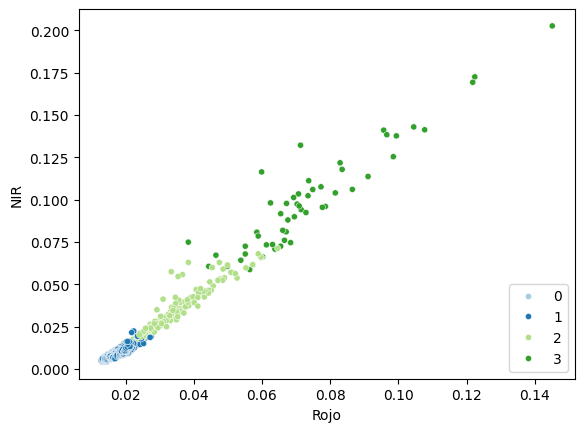

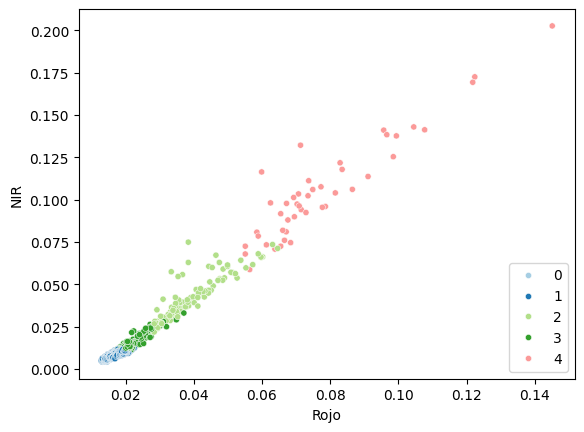

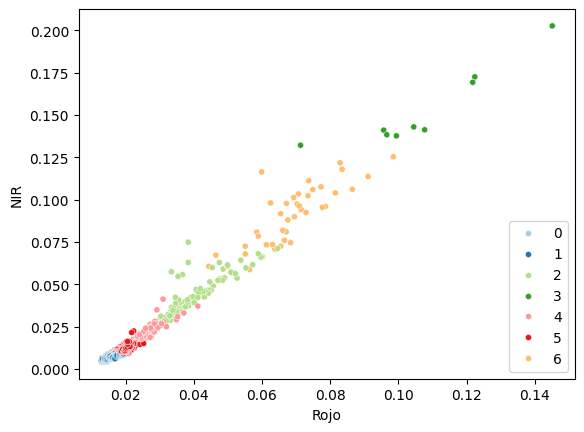

In [73]:
# centroides = [2,3,4,5,7,9,11]
centroides = [4,5,7]
for i in centroides:
    kmeans = KMeans(n_clusters=i)#, random_state=0)
    kmeans.fit(X)
    L = kmeans.labels_
    Yimg = L.reshape([x,y])
    Yimg = Yimg.astype('float64')
    Yimg[Yimg==0.] = np.nan
    
#     plt.figure(figsize=(15,10))
#     plt.title('n_cluster: '+str(i), fontsize = 20)
#     show(Yimg, cmap='Spectral')
    
#     plt.savefig('Plots/plots/kmans/kmeans-n'+str(i)+'.png', dpi = 200)
    
    bandx, bandy = 3,7
    
    X2 = X.astype('float64')
    X2[X2==0] = np.nan
    
    df_data = {'X':X2[:,bandx], 'Y':X2[:,bandy],'predicted_label' : []}
    df_data['predicted_label'] = kmeans.labels_.astype(int)
    data = pd.DataFrame.from_dict(df_data)
    
    plt.figure()
    sns.scatterplot(x="X", y="Y", hue="predicted_label", 
                    data=data, palette='Paired', s=20);
    plt.legend(loc='lower right');
    # N = 5000
    # R = np.random.randint(low=1, high=X2.shape[0],size=N)#X.shape[0])
    # plt.figure(figsize=(7,4))
    # plt.scatter(X2[R,bandx], X2[R,bandy], c=L[R], cmap='Spectral', label='prueba')
    # plt.legend()
    plt.xlabel(bandas[bandx])
    plt.ylabel(bandas[bandy])
    # plt.savefig('Plots/plots/kmans/kmeans-n'+str(i)+'.png', dpi = 200)

In [74]:
df_data = {'X':X2[:,bandx], 'Y':X2[:,bandy],'predicted_label' : []}
df_data['predicted_label'] = kmeans.labels_.astype(int)

data = pd.DataFrame.from_dict(df_data)

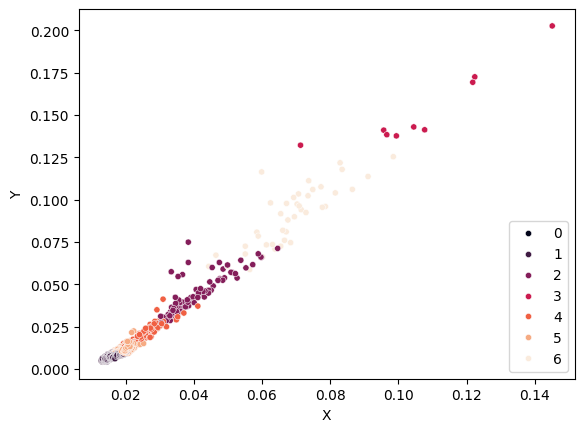

In [75]:
sns.scatterplot(x="X", y="Y", hue="predicted_label", 
                data=data, palette='rocket', s=20);
plt.legend(loc='lower right');

In [76]:
def ndvi(array, bandaR, bandaNIR, factor=10000): 
    red = np.asarray(array[bandaR])/factor
    nir = np.asarray(array[bandaNIR])/factor
    
    return (nir-red)/(nir+red)

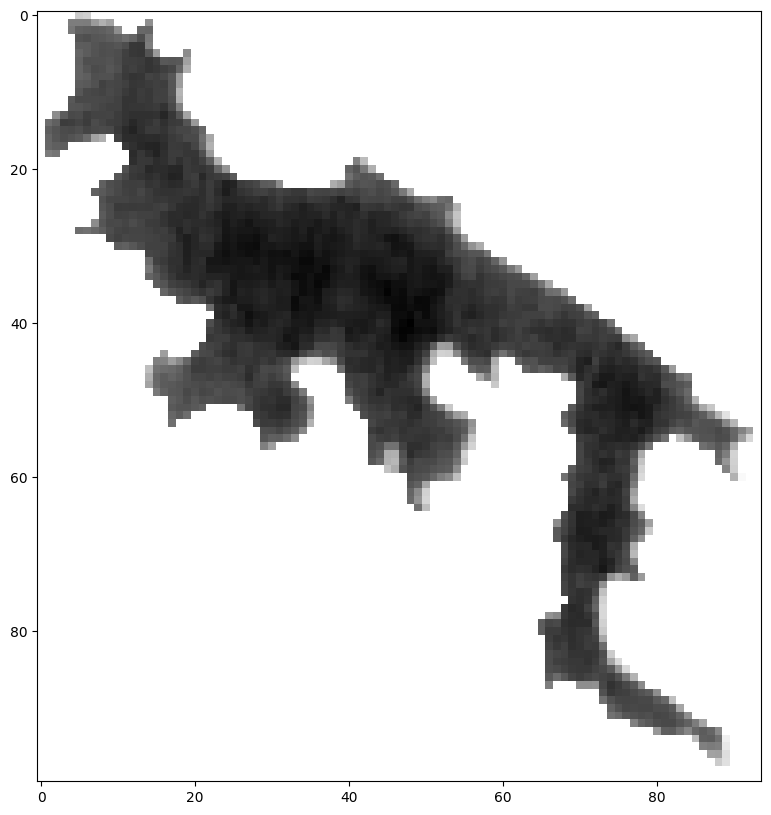

In [77]:
ndvi_out = ndvi(s2_mask,3,7)
plt.figure(figsize = (15,10))
plt.imshow(ndvi_out, cmap = 'gray')

In [78]:
stack = np.asarray([ndvi_out])
stack 

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1, 100, 94))

In [79]:
d,x,y = stack.shape
X = stack.reshape([d,x*y]).T
X = np.nan_to_num(X, nan = -50)
X

array([[-50.],
       [-50.],
       [-50.],
       ...,
       [-50.],
       [-50.],
       [-50.]], shape=(9400, 1))

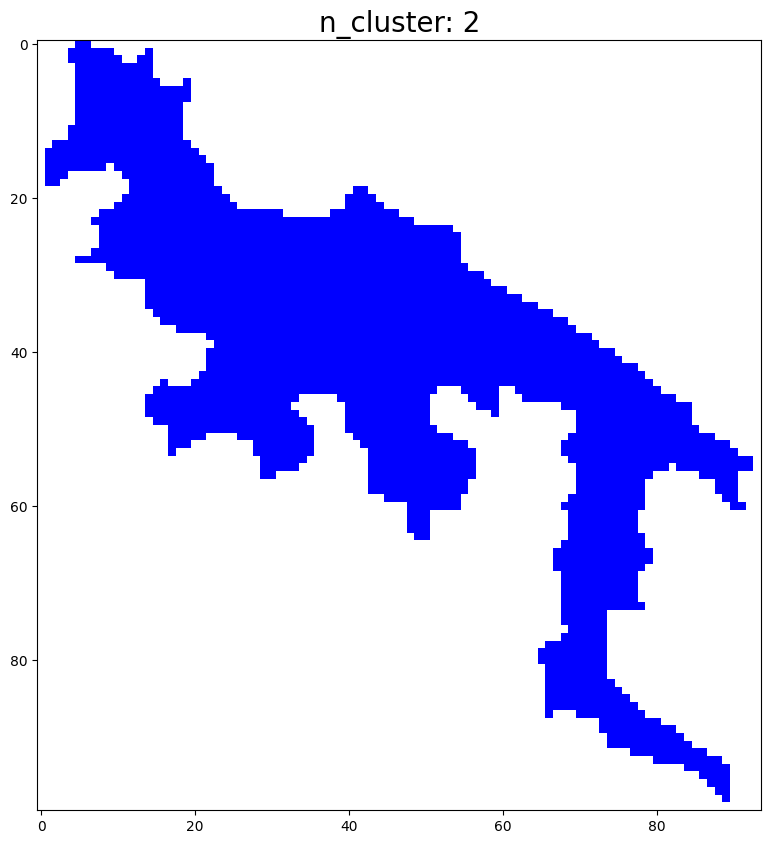

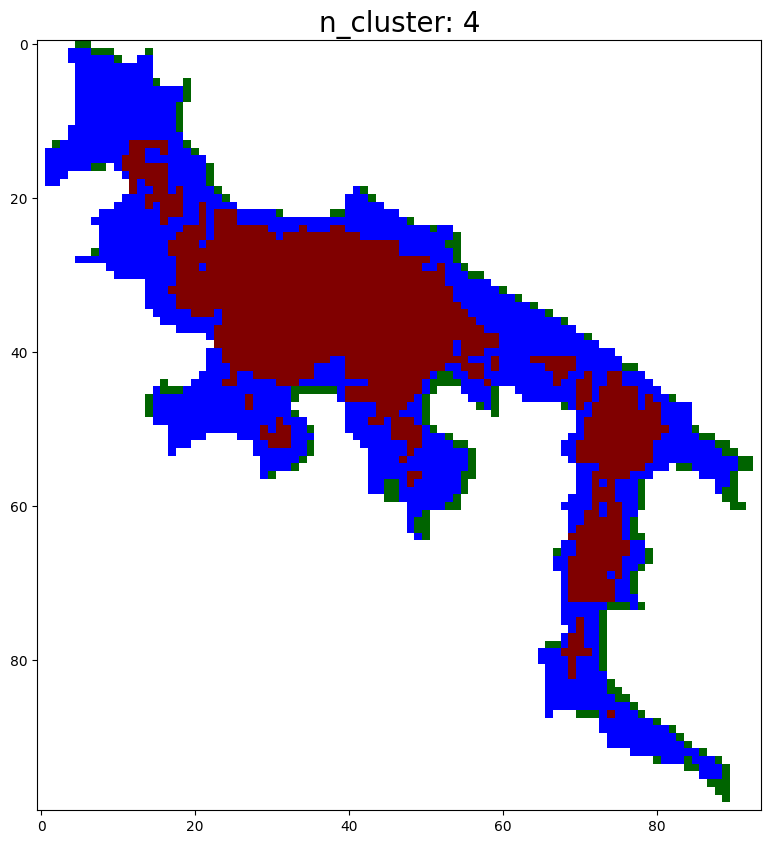

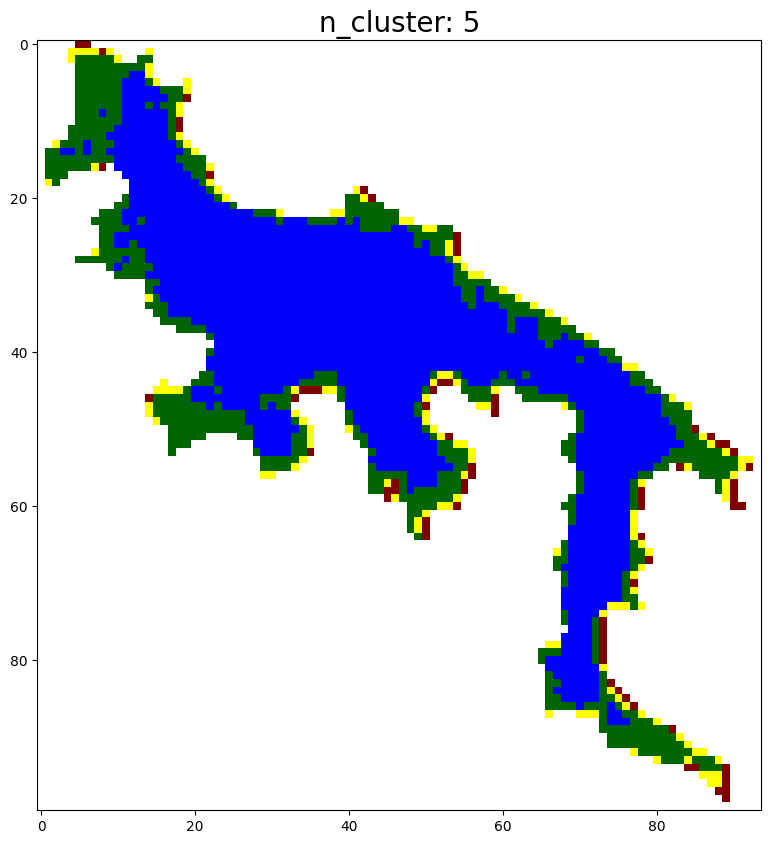

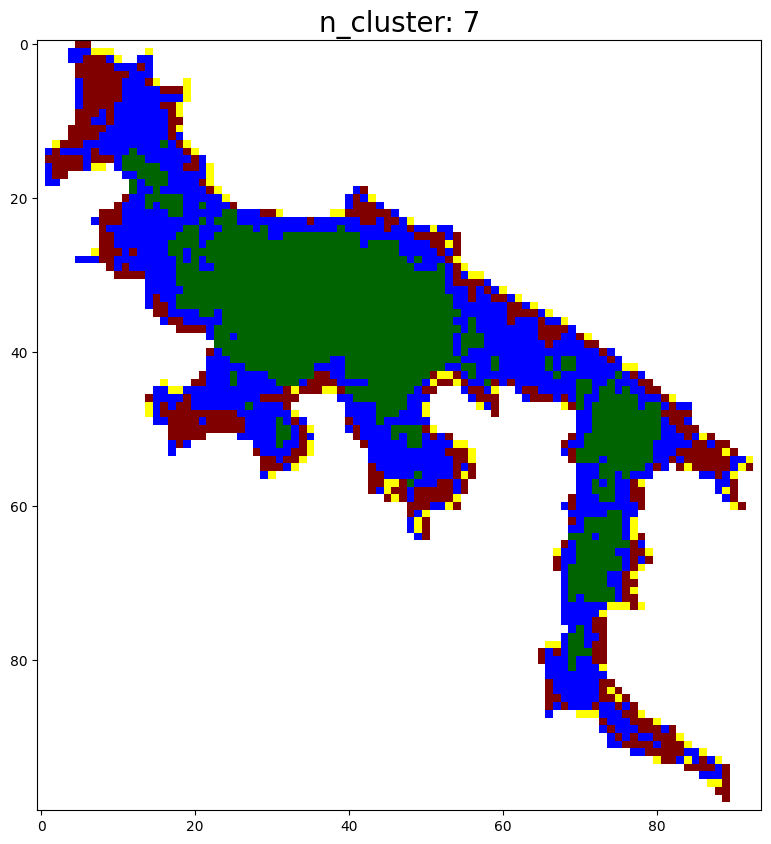

In [80]:
colors = ['blue',
          'yellow',
          'darkgreen',
          'maroon']

from matplotlib.colors import ListedColormap

cmap = ListedColormap(colors)

for i in [2,4,5,7]:
    kmeans = KMeans(n_clusters=i)#, random_state=0)
    kmeans.fit(X)
    L = kmeans.labels_
    Yimg = L.reshape([x,y])
    Yimg = Yimg.astype('float64')
    Yimg[Yimg==0.] = np.nan
    
    plt.figure(figsize=(15,10))
    plt.title('n_cluster: '+str(i), fontsize = 20)
    show(Yimg, cmap=cmap)
    
    # bandx, bandy = 0,1
    
#     X2 = X.astype('float64')
#     X2[X2==-50] = np.nan
    
#     df_data = {'X':X2[:,bandx], 'Y':X2[:,bandy],'predicted_label' : []}
#     df_data['predicted_label'] = kmeans.labels_.astype(int)
#     data = pd.DataFrame.from_dict(df_data)

#     sns.scatterplot(x="X", y="Y", hue="predicted_label", 
#                     data=data, palette='Paired', s=20);
#     plt.legend(loc='lower right');
#     # N = 5000
#     # R = np.random.randint(low=1, high=X2.shape[0],size=N)#X.shape[0])
#     # plt.figure(figsize=(7,4))
#     # plt.scatter(X2[R,bandx], X2[R,bandy], c=L[R], cmap='Spectral', label='prueba')
#     # plt.legend()
#     plt.xlabel('NDVI')
#     plt.ylabel('Chlorophyll')

In [81]:
gmm = mixture.GaussianMixture(n_components=5, covariance_type='full')
gmm.fit(X)

,n_components,5
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


In [82]:
Y_pred = gmm.predict(X)
Yimg = Y_pred.reshape([x,y])

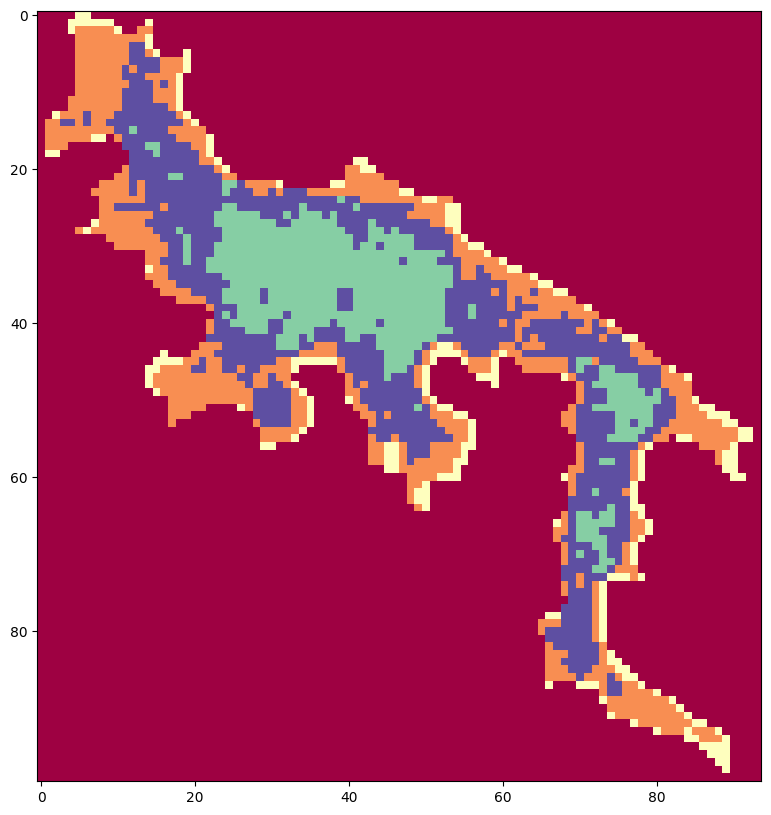

<Axes: >

In [83]:
plt.figure(figsize=(15,10))
show(Yimg,cmap='Spectral')

# Supervised Classification

In [84]:
from shapely.geometry import mapping

In [85]:
#I load the labeled data into X, Y, as before

#I read the ROIS
with rasterio.open(path) as src:
    d=src.count #number of attributes = number of bands in the raster
    m=src.read()

nodata=-255 #I choose an unusual value for nodata

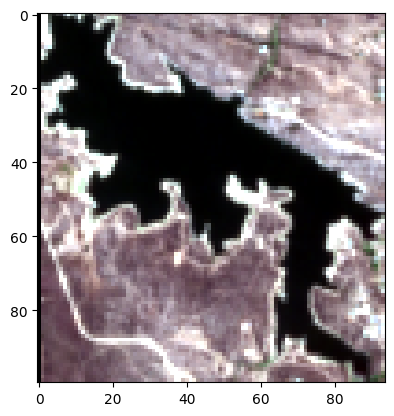

<Axes: >

In [86]:
show(nequalize(s2_clip[[3,2,1]]))

In [87]:
pols = gpd.read_file('Poligonos/Entrenamiento_2022/pol180222.shp')#.set_index('id') #Loads shp file
nombres_col = {'id':'id_clase', 'clase_1':'CLASE'}
pols.rename(columns = nombres_col, inplace = True)
pols

,id_clase,CLASE,geometry
0,1,Agua Clara,"POLYGON ((360157.069 6528767.138, 360157.069 6..."
1,2,Agua Clara,"POLYGON ((360482.753 6528546.176, 360511.027 6..."
2,3,Agua Clara,"POLYGON ((360747.698 6528326.261, 360786.445 6..."
3,4,Agua Clara,"POLYGON ((360773.878 6528059.222, 360804.247 6..."
4,5,Agua Clara,"POLYGON ((360875.458 6527638.242, 360851.372 6..."
5,6,Agua Clara,"POLYGON ((359198.084 6525715.558, 359211.698 6..."
6,1,Alga Densa,"POLYGON ((360708.689 6526822.986, 360800.844 6..."
7,2,Alga Densa,"POLYGON ((361766.374 6528802.22, 361971.628 65..."
8,3,Alga Densa,"POLYGON ((357747.17 6524280.352, 357940.904 65..."
9,4,Alga Densa,"POLYGON ((360935.934 6533060.189, 361128.622 6..."


In [88]:
pols['CLASE'].value_counts()

CLASE
Agua Clara    6
Alga Densa    6
Alga Difus    6
Name: count, dtype: int64

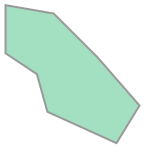

In [89]:
poligono = pols.loc[0].geometry
poligono

<Axes: >

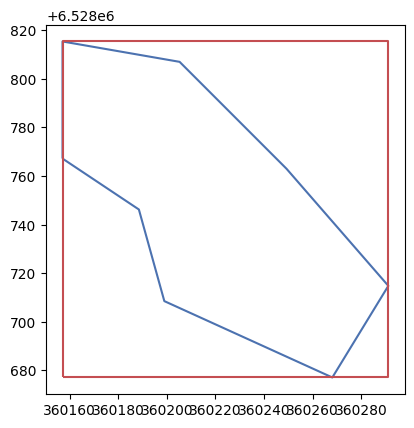

In [91]:
extent = poligono.envelope

data = [poligono, extent]
gpd.GeoSeries(data).boundary.plot(color=['b', 'r'])

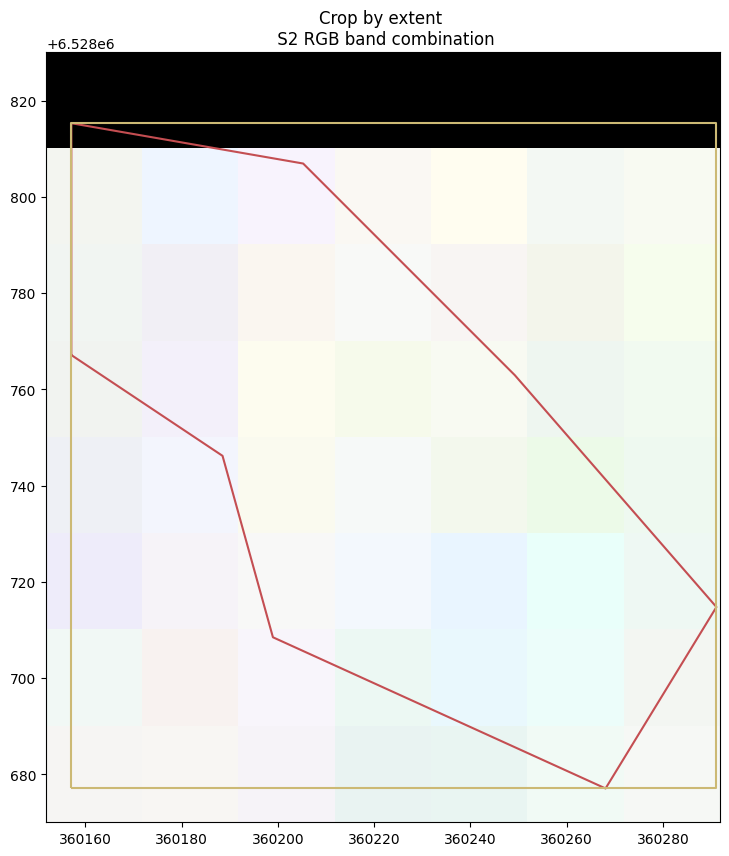

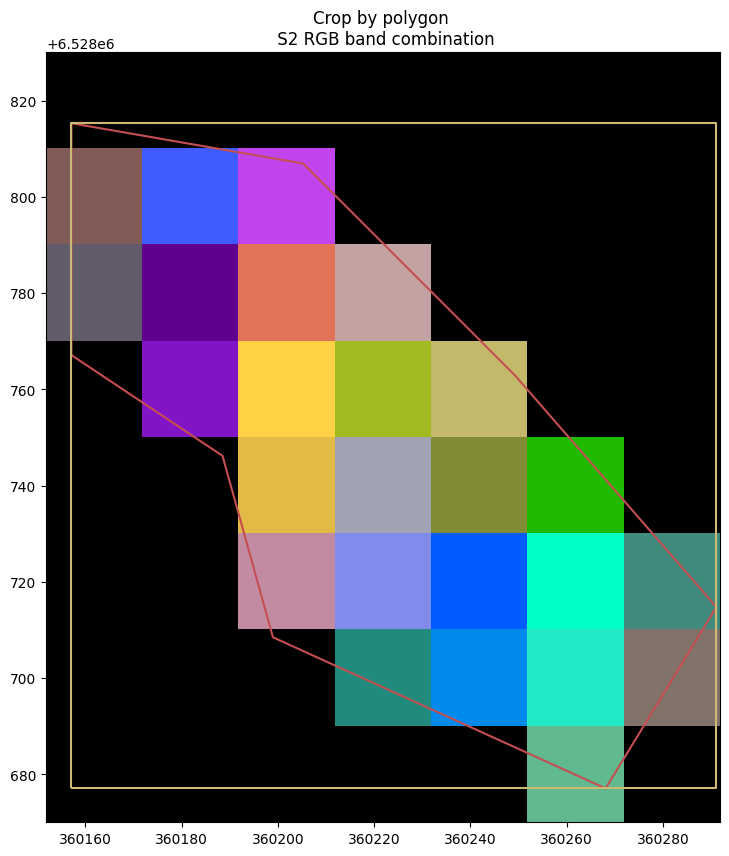

In [93]:
recorte, transformacion = mask(dataset = s2, shapes = [extent], crop = True)
fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(recorte[[3,2,1]],p=0.5,nodata = None), ax=ax, transform=transformacion)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by extent \n S2 RGB band combination")
plt.show()

# Keep only what is inside the vector mask
recorte_mascara, transformacion_mascara  = mask(dataset = s2, shapes = [poligono], crop = True)

fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(recorte_mascara[bandasPosicion], p=0.5), ax=ax,transform=transformacion_mascara)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by polygon \n S2 RGB band combination")
plt.show()

In [94]:
clases=list(set(pols['CLASE']))
clases.sort() #numbers the ROI classes alphabetically
clase_dict = {clase:i for i, clase in enumerate(clases)}
clase_dict

{'Agua Clara': 0, 'Alga Densa': 1, 'Alga Difus': 2}

In [95]:
#Prepare the collection of labeled attributes. Starts with 0 data points
X = np.zeros([0,d],dtype = np.float32) #array with all the attributes
Y = np.zeros([0],dtype=int)            #array with their labels

with rasterio.open(path) as src:
    for index, row in pols.iterrows():
        poli = row['geometry']
        clase = row['CLASE']
        clip, _transform = mask(src, [poli], crop=True,nodata=None)
        d,x,y = clip.shape
        D = list(clip.reshape([d,x*y]).T)
        D = [p for p in D if (not (p==None).prod())]
        DX = np.array(D)        
        DY = np.repeat(clase_dict[clase],len(D))
        X = np.concatenate((X,DX))
        Y = np.concatenate((Y,DY))

In [96]:
L = list(Y)
E = set(L)

pixels_por_clase = {clases[y]:L.count(y) for y in E}

In [97]:
for clase in clases:
    print(f"{clase:>15s}: {pixels_por_clase[clase]}")

     Agua Clara: 251
     Alga Densa: 1003
     Alga Difus: 434


In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, stratify=Y)#, random_state=2)

In [99]:
#We build and train a *Decision tree*
from sklearn import tree

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score as kappa
from sklearn.tree import DecisionTreeClassifier

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)
Y_pred = clf.predict(X_test)

In [100]:
M=confusion_matrix(y_test, Y_pred)
print('Confusion matrix:\n',M)

acc = accuracy_score(y_test, Y_pred)
print(f'accuracy: {acc:.2f}')

k = kappa(y_test, Y_pred)
print(f'kappa index: {k:.2f}')


Confusion matrix:
 [[ 15  43   5]
 [  2 246   3]
 [  3  68  37]]
accuracy: 0.71
kappa index: 0.36


In [101]:
#We build and train a tree of depth 4

clf4 = DecisionTreeClassifier(max_depth = 2)
clf4 = clf4.fit(X_train, y_train)
Y_pred = clf4.predict(X_test)

acc = accuracy_score(y_test, Y_pred)
print(f'accuracy: {acc:.2f}')

k = kappa(y_test, Y_pred)
print(f'kappa index: {k:.2f}')

accuracy: 0.63
kappa index: 0.14


In [102]:
feature_names=bandas

n_nodes = clf4.tree_.node_count
children_left = clf4.tree_.children_left
children_right = clf4.tree_.children_right
feature = clf4.tree_.feature
threshold = clf4.tree_.threshold
hojas = [clases[np.argmax(clf4.tree_.value[i][0])] for i in range(n_nodes)]

n_nodes

7

In [103]:
node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
is_leaves = np.zeros(shape=n_nodes, dtype=bool)
stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
while len(stack) > 0:
    # `pop` ensures each node is only visited once
    node_id, depth = stack.pop()
    node_depth[node_id] = depth

    # If the left and right child of a node is not the same we have a split
    # node
    is_split_node = children_left[node_id] != children_right[node_id]
    # If a split node, append left and right children and depth to `stack`
    # so we can loop through them
    if is_split_node:
        stack.append((children_left[node_id], depth + 1))
        stack.append((children_right[node_id], depth + 1))
    else:
        is_leaves[node_id] = True

print("The binary tree structure has {n} nodes:\n".format(n=n_nodes))
for i in range(n_nodes):
    if is_leaves[i]:
        print("{space}N{node}: LEAF {clase}.".format(
            space=node_depth[i] * "\t", node=i, clase = hojas[i]))
    else:
        print("{space}N{node}: IF ({feature} <= {threshold:.3f}) -> N{left}, ELSE -> N{right}.".format(
                  space=node_depth[i] * "\t",
                  node=i,
                  left=children_left[i],
                  feature=feature_names[feature[i]],
                  threshold=threshold[i],
                  right=children_right[i]))

The binary tree structure has 7 nodes:

N0: IF (Banda 9 <= 65.500) -> N1, ELSE -> N4.
	N1: IF (Banda 1 <= 92.500) -> N2, ELSE -> N3.
		N2: LEAF Alga Densa.
		N3: LEAF Agua Clara.
	N4: IF (Banda 9 <= 80.500) -> N5, ELSE -> N6.
		N5: LEAF Alga Densa.
		N6: LEAF Alga Densa.


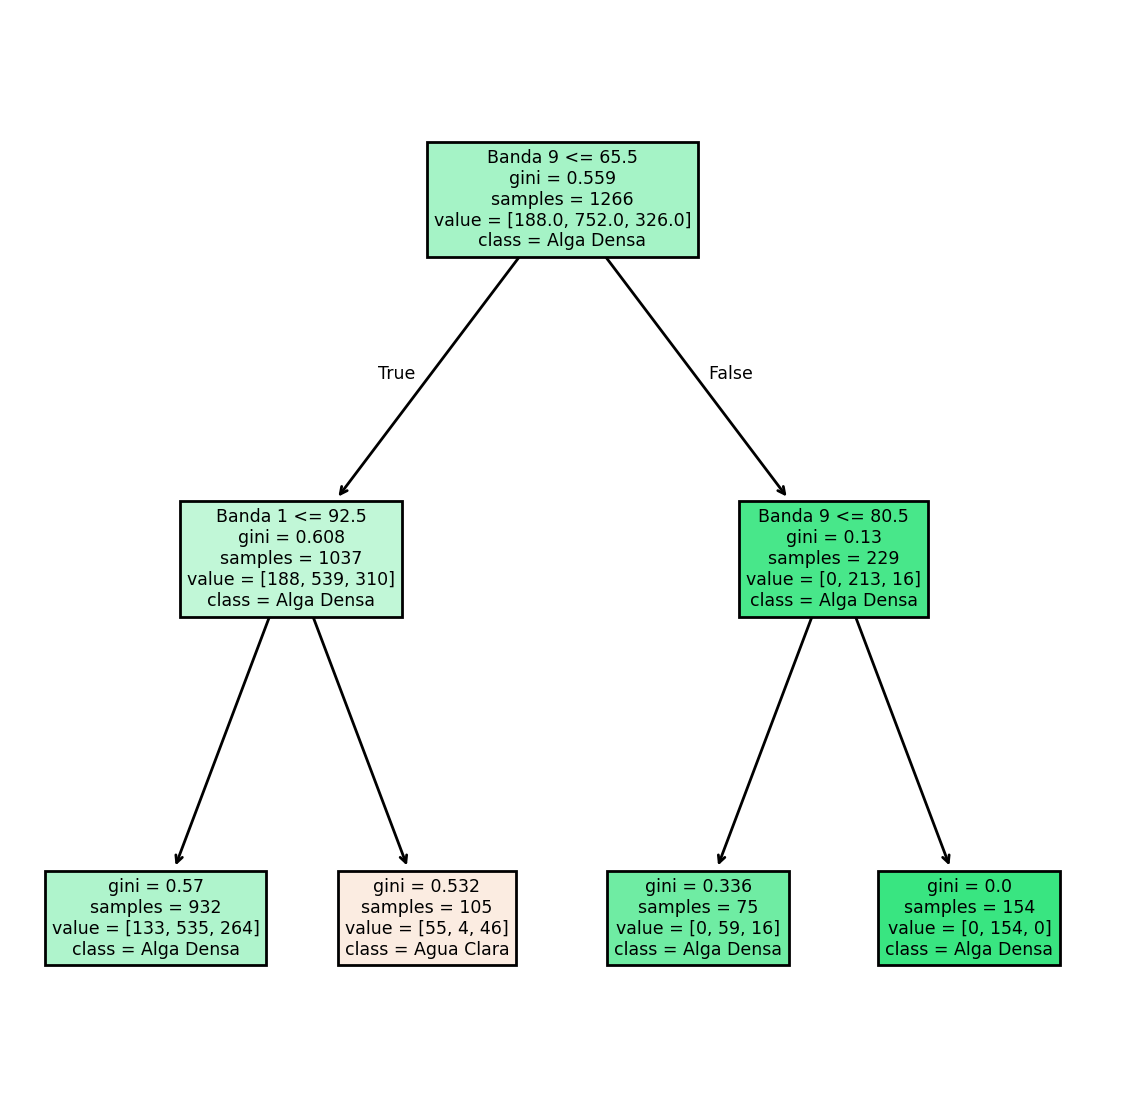

In [104]:
#%%
fig = plt.figure(figsize=(7,7),dpi=200)
_ = tree.plot_tree(clf4, 
                   feature_names=bandas,  
                   class_names=clases,
                   filled=True)
plt.show()

In [105]:
#we build a list of maximum depths and see which one fits best
lmd = np.arange(2,11)
scoresTest = []
scoresTrain = []

for md in lmd:
    clf = tree.DecisionTreeClassifier(max_depth = md)
    clf = clf.fit(X_train, y_train)
    Y_pred = clf.predict(X_test)
    acc_test = accuracy_score(y_test, Y_pred)
    scoresTest.append(acc_test)
    acc_train = accuracy_score(y_train, clf.predict(X_train))
    scoresTrain.append(acc_train)
    print(f'Depth {md:>2d}: Train {acc_train:.3f}, Test: {acc_test:.3f}')

Depth  2: Train 0.634, Test: 0.626
Depth  3: Train 0.670, Test: 0.656
Depth  4: Train 0.727, Test: 0.685
Depth  5: Train 0.750, Test: 0.720
Depth  6: Train 0.758, Test: 0.701
Depth  7: Train 0.761, Test: 0.709
Depth  8: Train 0.761, Test: 0.706
Depth  9: Train 0.762, Test: 0.716
Depth 10: Train 0.762, Test: 0.704


In [106]:
#I look for the best score on the train set
imx = np.argmax(scoresTest)
best_prof = lmd[imx]
acc = scoresTest[imx]
print(f'The best result on the test set was obtained for a tree\nof depth {best_prof} with an accuracy of {acc:.3f}')

The best result on the test set was obtained for a tree
of depth 5 with an accuracy of 0.720


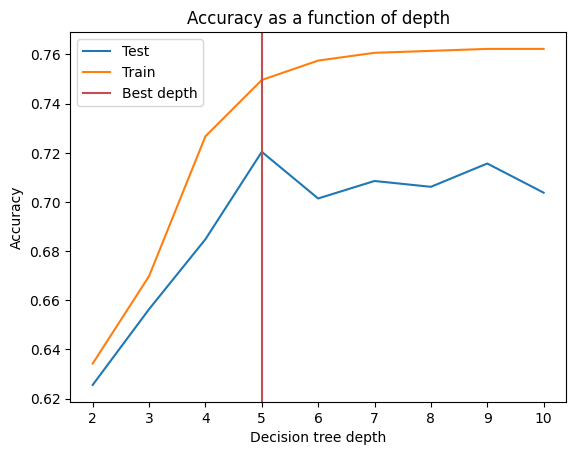

In [107]:
#plot
plt.plot(lmd,scoresTest,label="Test")
plt.plot(lmd,scoresTrain,label="Train")
plt.title("Accuracy as a function of depth")    
plt.ylabel("Accuracy")
plt.xlabel("Decision tree depth")
plt.axvline(x=best_prof, label='Best depth', c='r')
plt.legend()
plt.show()

In [108]:

from sklearn.model_selection import StratifiedKFold

n_splits = 5
lmd = np.arange(2,25)
accTest = np.zeros([len(lmd),n_splits])
accTrain = np.zeros([len(lmd),n_splits])

skf = StratifiedKFold(n_splits=n_splits, shuffle=True)
for j, (train_index, test_index) in enumerate(skf.split(X, Y)):
    print(f'fold {j+1} of {n_splits}.')
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = Y[train_index], Y[test_index]
    for i,md in enumerate(lmd):
        clf = tree.DecisionTreeClassifier(max_depth = md)
        clf = clf.fit(X_train, y_train)
        accTest[i,j] = accuracy_score(y_test, clf.predict(X_test))
        accTrain[i,j] = accuracy_score(y_train, clf.predict(X_train))

fold 1 of 5.
fold 2 of 5.
fold 3 of 5.
fold 4 of 5.
fold 5 of 5.


In [109]:
print(f'\n\nAccuracy for each max_depth (rows) and the {n_splits} runs:\n')
print('*',' '.join([f'Run {i+1} ' for i in range(n_splits)]),'*')
print(accTest)



Accuracy for each max_depth (rows) and the 5 runs:

* Run 1  Run 2  Run 3  Run 4  Run 5  *
[[0.61242604 0.63609467 0.65680473 0.64688427 0.63204748]
 [0.66863905 0.71005917 0.70710059 0.70029674 0.66468843]
 [0.68639053 0.73668639 0.74852071 0.73293769 0.70029674]
 [0.71893491 0.75739645 0.77514793 0.7537092  0.70029674]
 [0.72189349 0.75739645 0.77218935 0.7537092  0.69732938]
 [0.72781065 0.76035503 0.77218935 0.75074184 0.70029674]
 [0.71597633 0.75443787 0.77218935 0.75074184 0.69732938]
 [0.72781065 0.75147929 0.76923077 0.75074184 0.70326409]
 [0.72781065 0.76035503 0.76923077 0.75074184 0.70029674]
 [0.72485207 0.75443787 0.77218935 0.75074184 0.70326409]
 [0.72189349 0.75147929 0.77218935 0.74480712 0.69732938]
 [0.72189349 0.76035503 0.77514793 0.75074184 0.69732938]
 [0.72781065 0.75739645 0.77218935 0.7537092  0.69732938]
 [0.72781065 0.76035503 0.77514793 0.7537092  0.70326409]
 [0.72781065 0.75739645 0.76923077 0.74777448 0.69732938]
 [0.72189349 0.76035503 0.76923077 0.

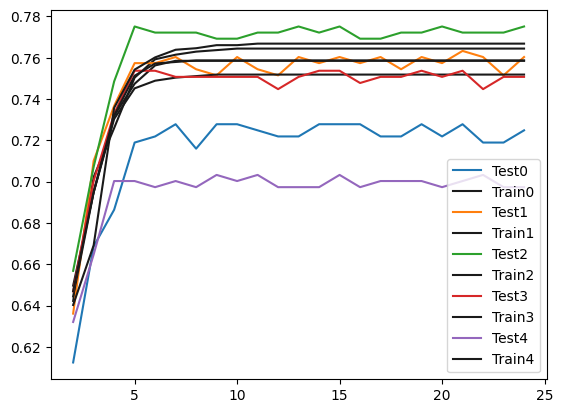

In [110]:
for i in range(n_splits):
    plt.plot(lmd,accTest[:,i],label=f"Test{i}")
    plt.plot(lmd,accTrain[:,i],label=f"Train{i}",c='k')
plt.legend()
plt.show()

In [111]:
#Calculate averages of the K folds
scoresTest = accTest.mean(axis=1)
scoresTrain = accTrain.mean(axis=1)

#Look for the best result
imx = np.argmax(scoresTest)
best_prof = lmd[imx]
best_acc = scoresTest[imx]
print(f'The best result on the test set was obtained for a tree of depth {best_prof} and an accuracy of {best_acc:.3f}')

The best result on the test set was obtained for a tree of depth 15 and an accuracy of 0.744


The best result was with a tree of depth 15: 0.744


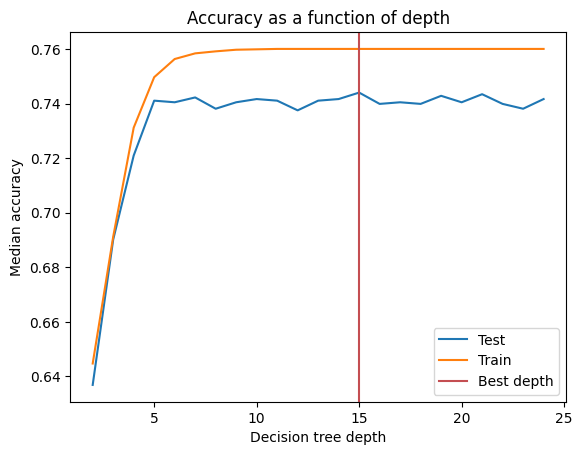

In [112]:
#Plot averages
plt.plot(lmd,scoresTest,label="Test")
print(f'The best result was with a tree of depth {lmd[np.argmax(scoresTest)]}: {scoresTest[np.argmax(scoresTest)]:.3f}')
plt.plot(lmd,scoresTrain,label="Train")
plt.title("Accuracy as a function of depth")    
plt.ylabel("Median accuracy")
plt.xlabel("Decision tree depth")
plt.axvline(x=best_prof, label='Best depth', c='r')
plt.legend()
plt.show()

In [113]:
#Let's train a tree of depth 11
clf12 = tree.DecisionTreeClassifier(max_depth = best_prof)
clf12 = clf.fit(X, Y)

#Read the full image
raster_fn = path
with rasterio.open(raster_fn) as src:
    img = src.read()
    crs = src.crs
    gt = src.transform
img.shape
# d,x,y = img.shape

# #and use the model to classify the whole image
# Y_pred = clf12.predict(img.reshape([d,x*y]).T)

d,x,y = s2_clip.shape

#and use the model to classify the whole image
Y_pred = clf12.predict(s2_clip.reshape([d,x*y]).T)


In [114]:
np.where(s2_mask == 0)

(array([0, 0, 0, ..., 9, 9, 9], shape=(69540,)),
 array([ 0,  0,  0, ..., 99, 99, 99], shape=(69540,)),
 array([ 0,  1,  2, ..., 91, 92, 93], shape=(69540,)))

In [115]:
prueba = Y_pred.reshape([x,y])
prueba = prueba.astype('float64')
prueba[np.where(s2_mask[0] == 0)] = np.nan

In [116]:
prueba.shape

(100, 94)

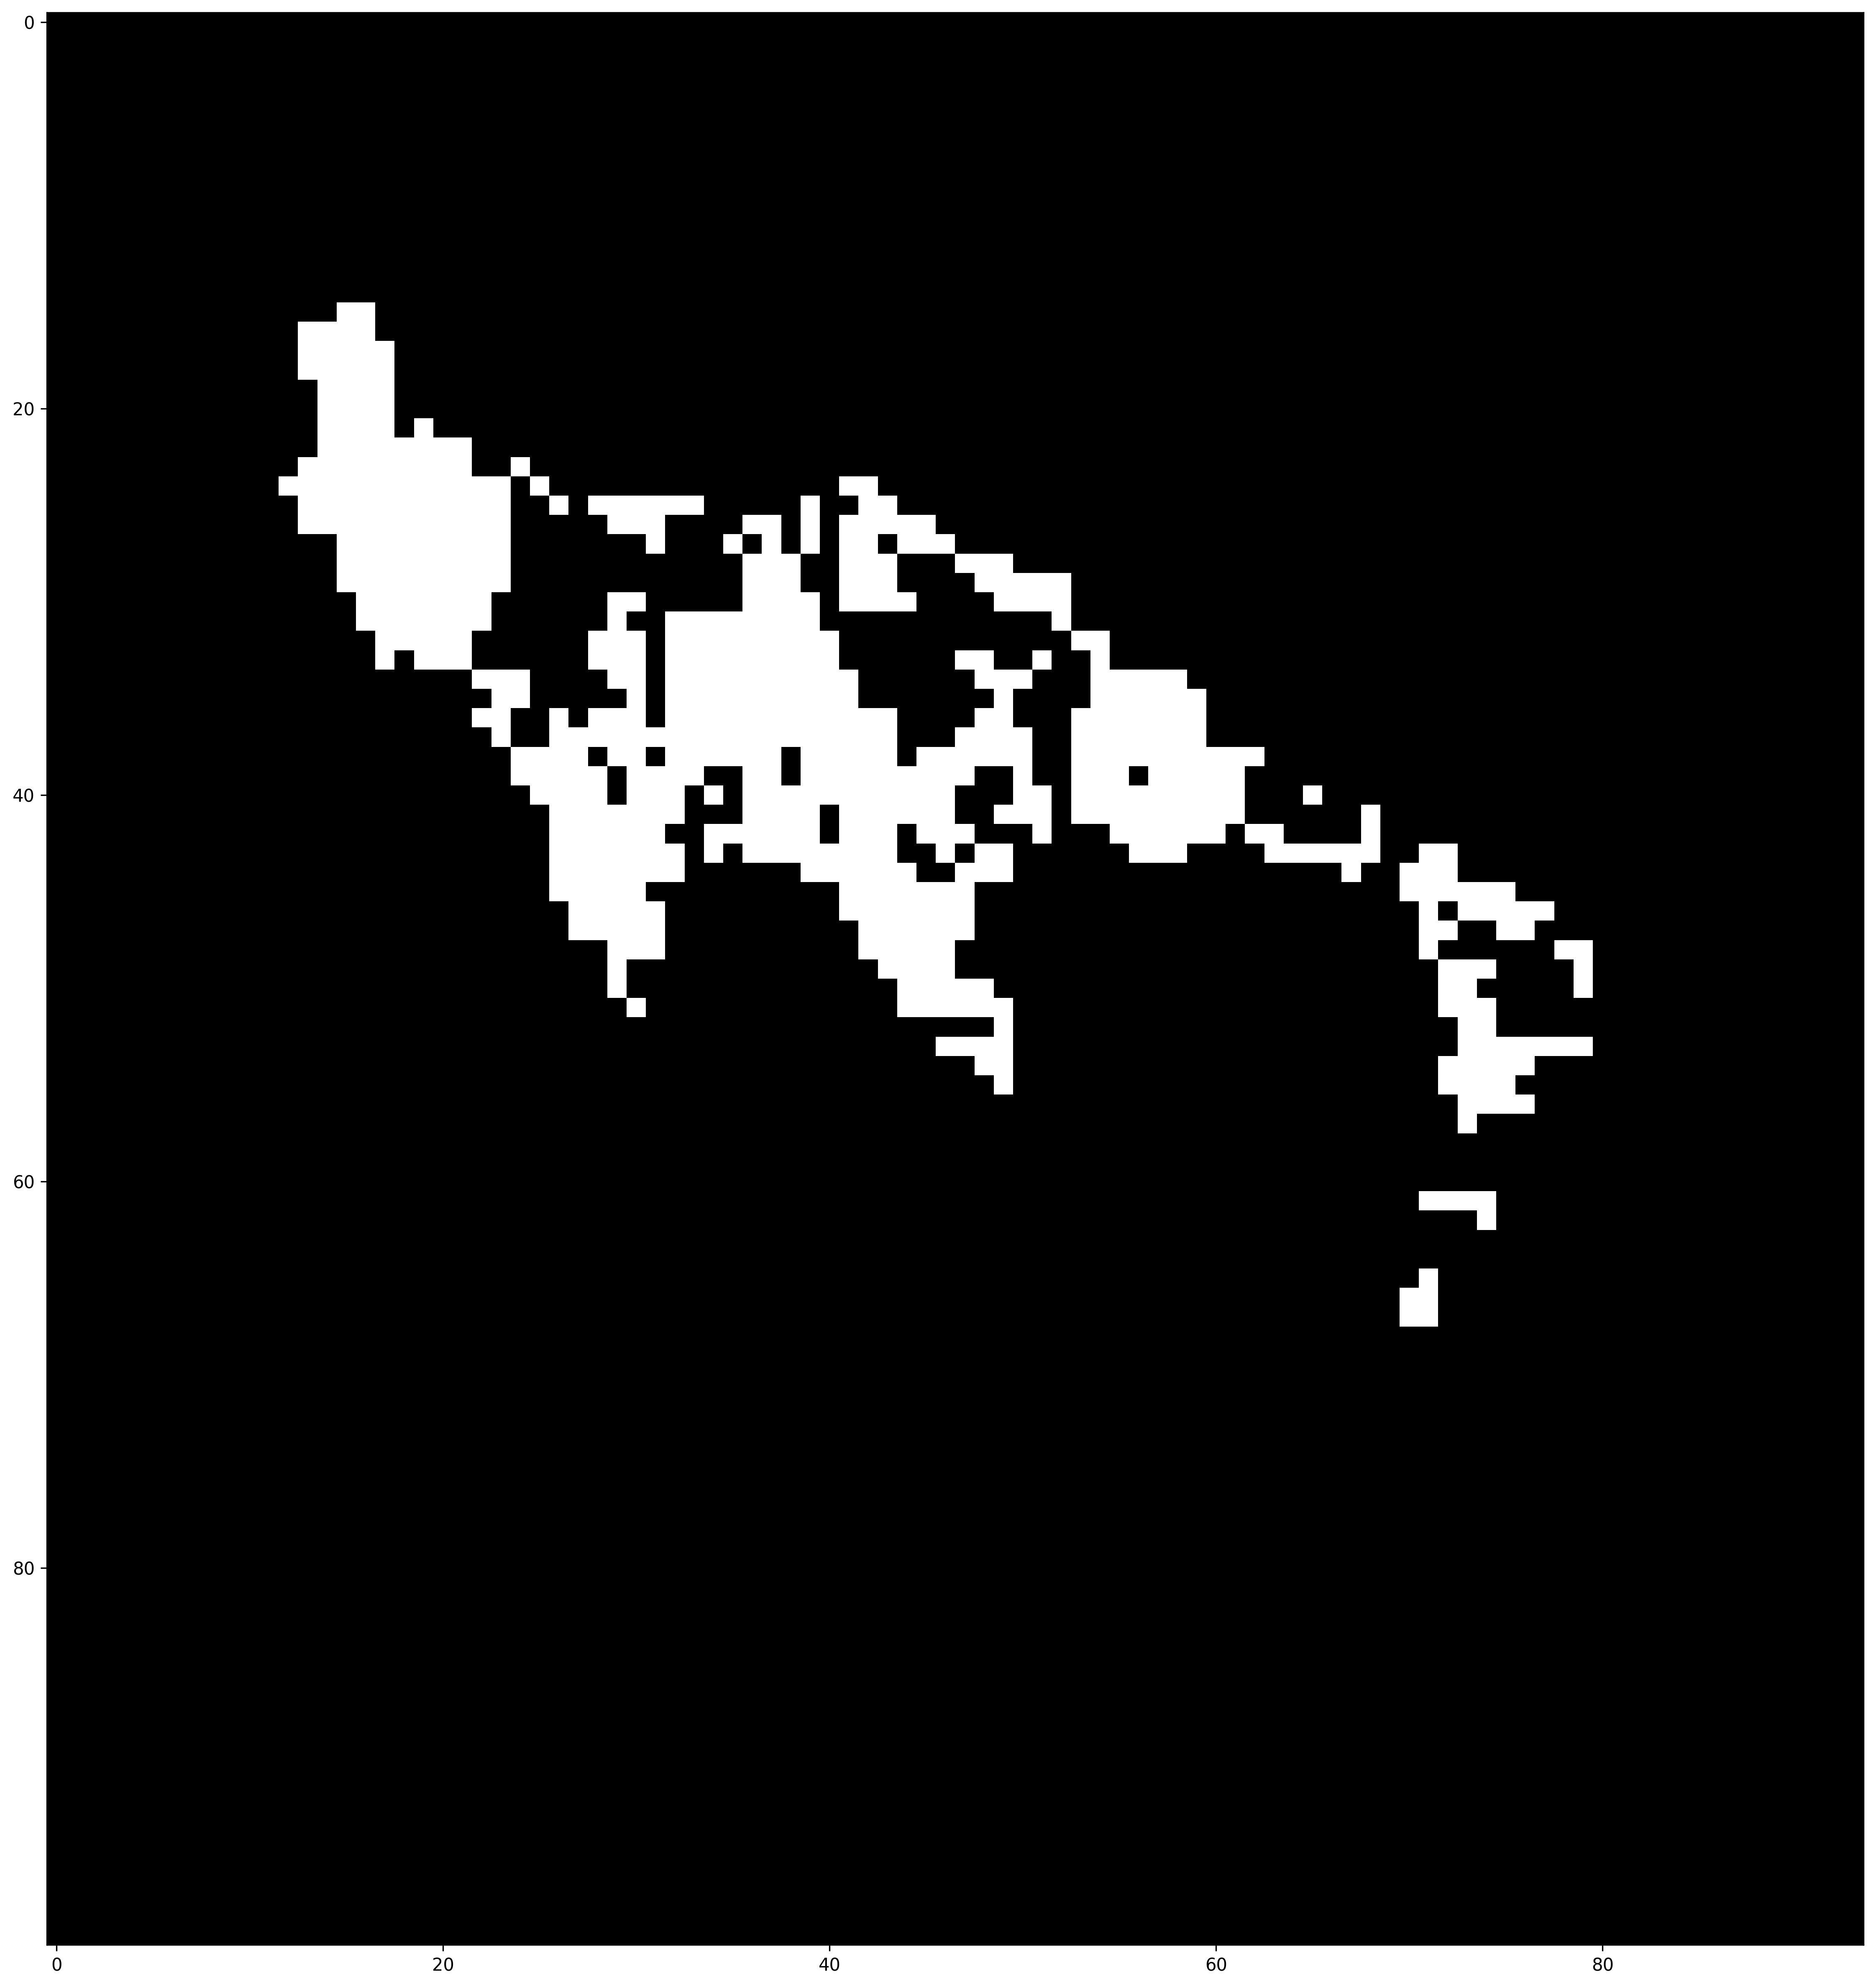

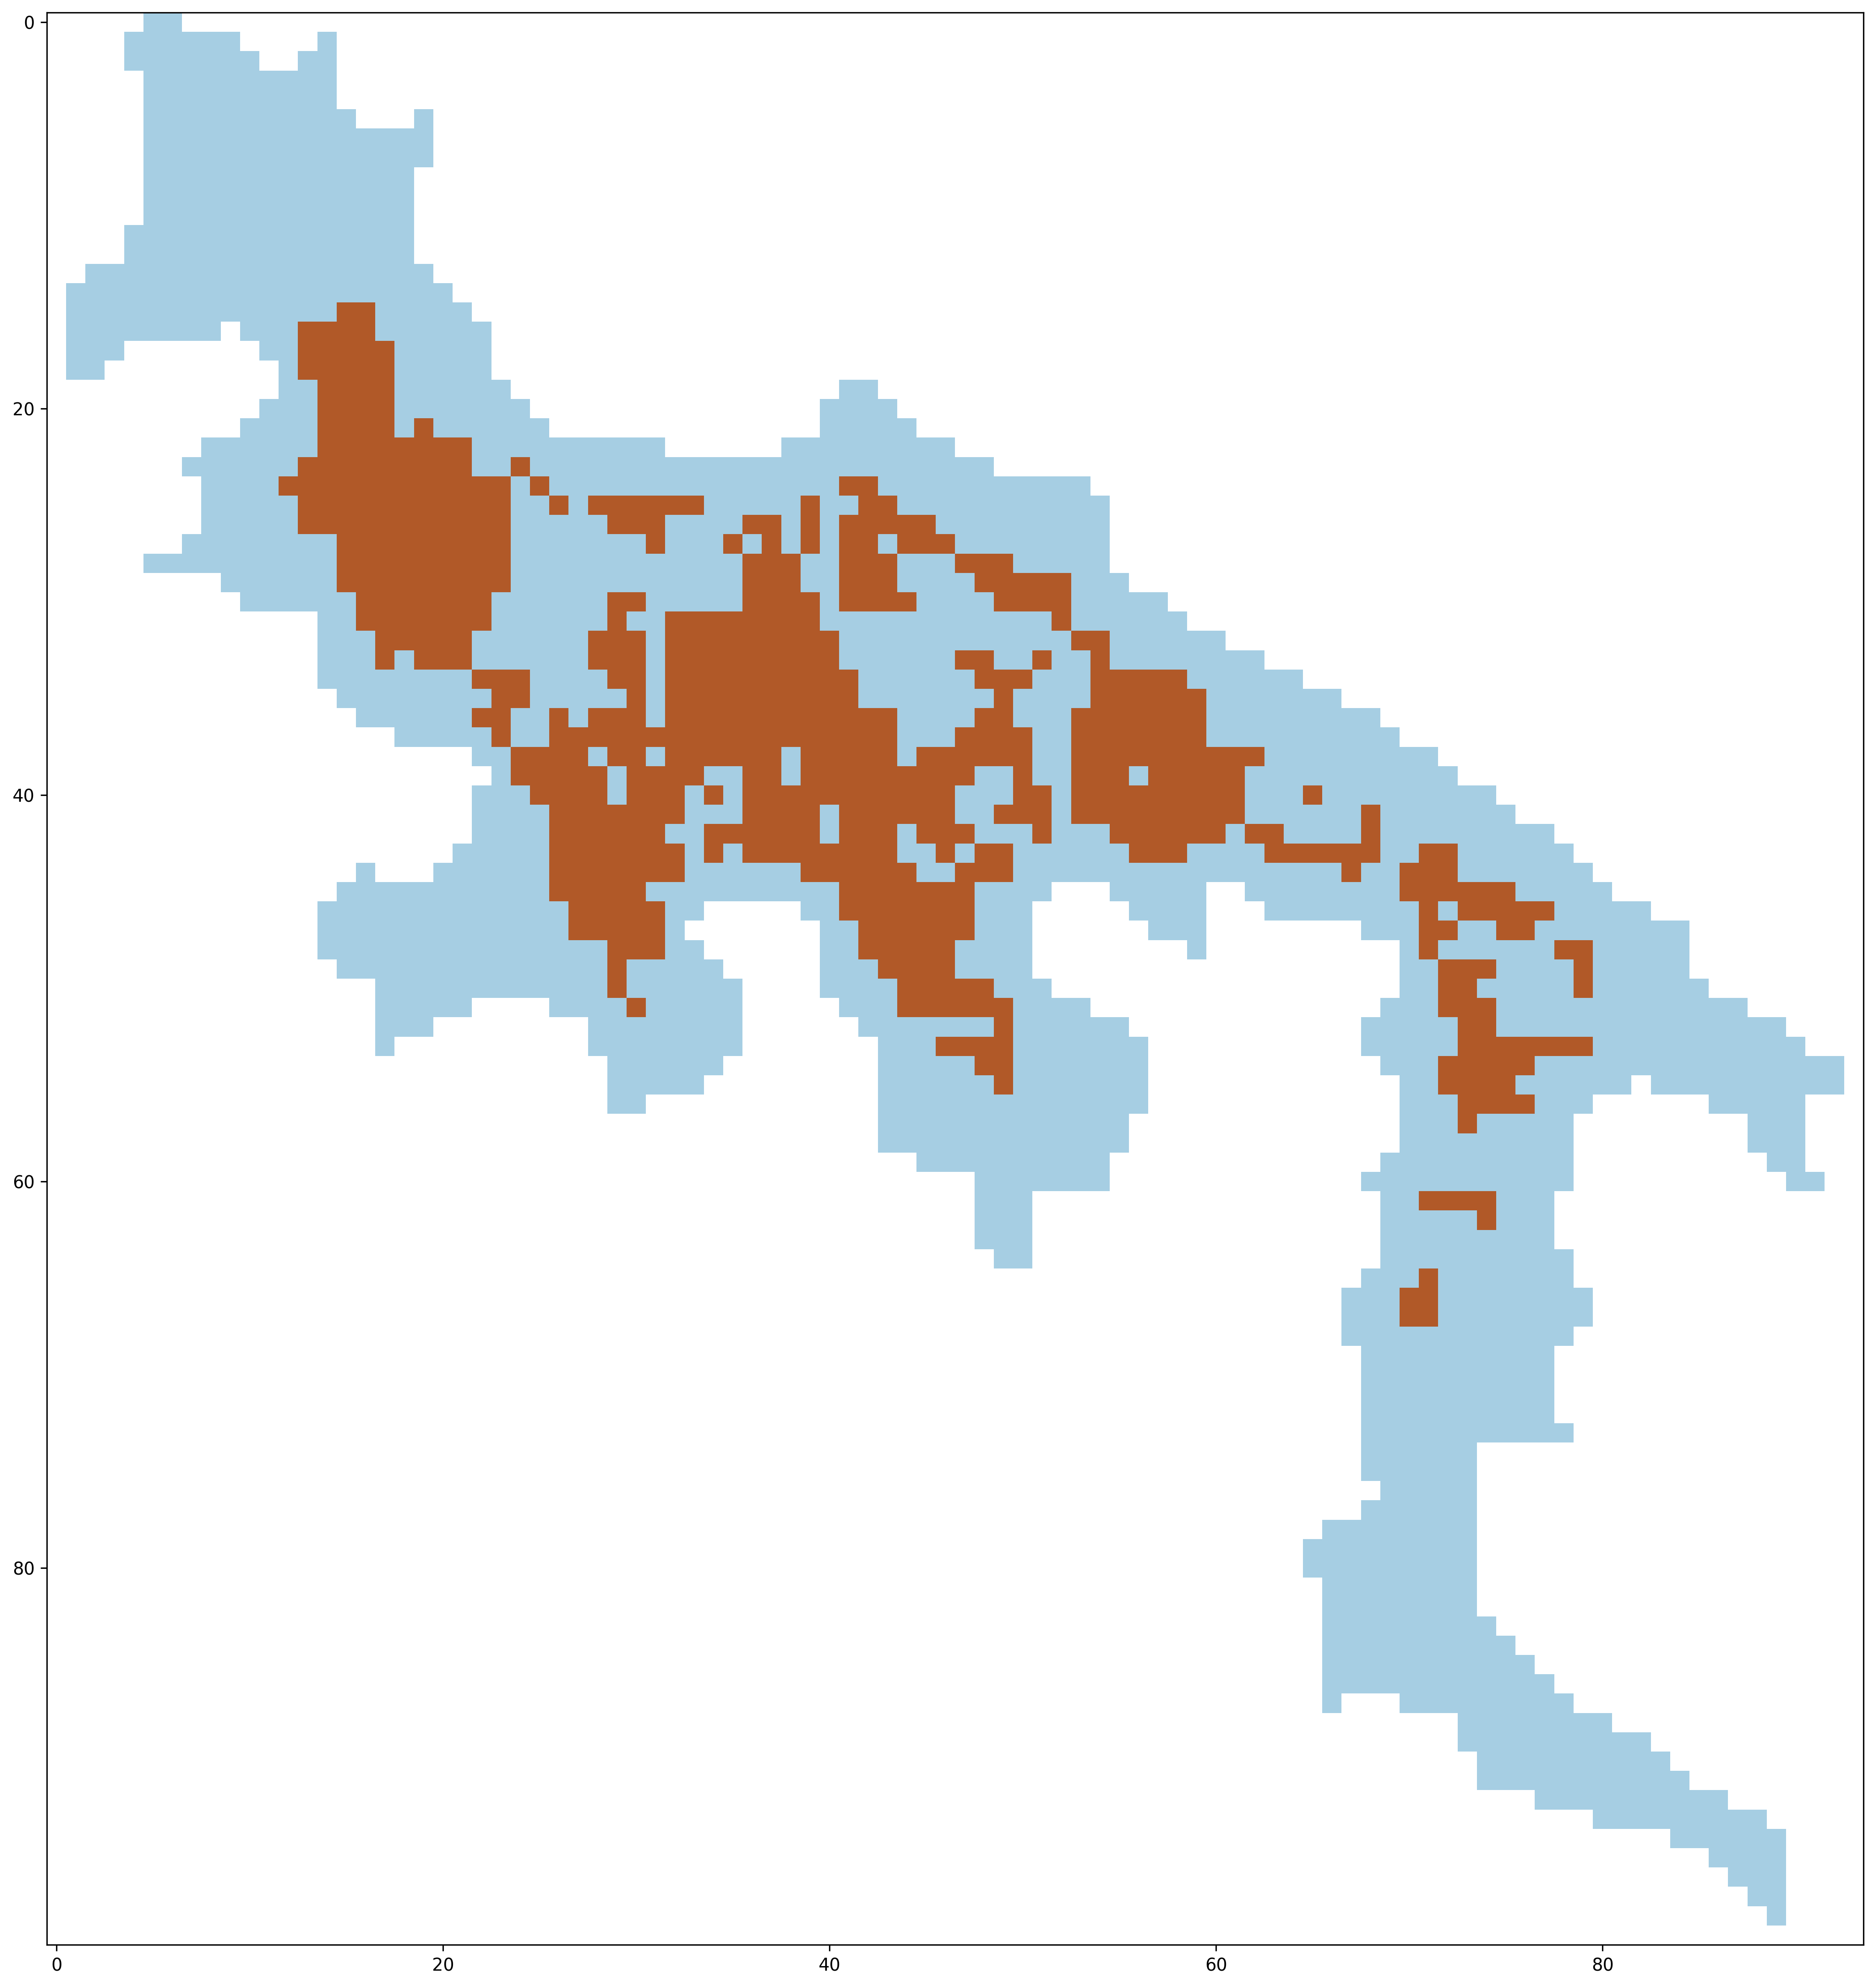

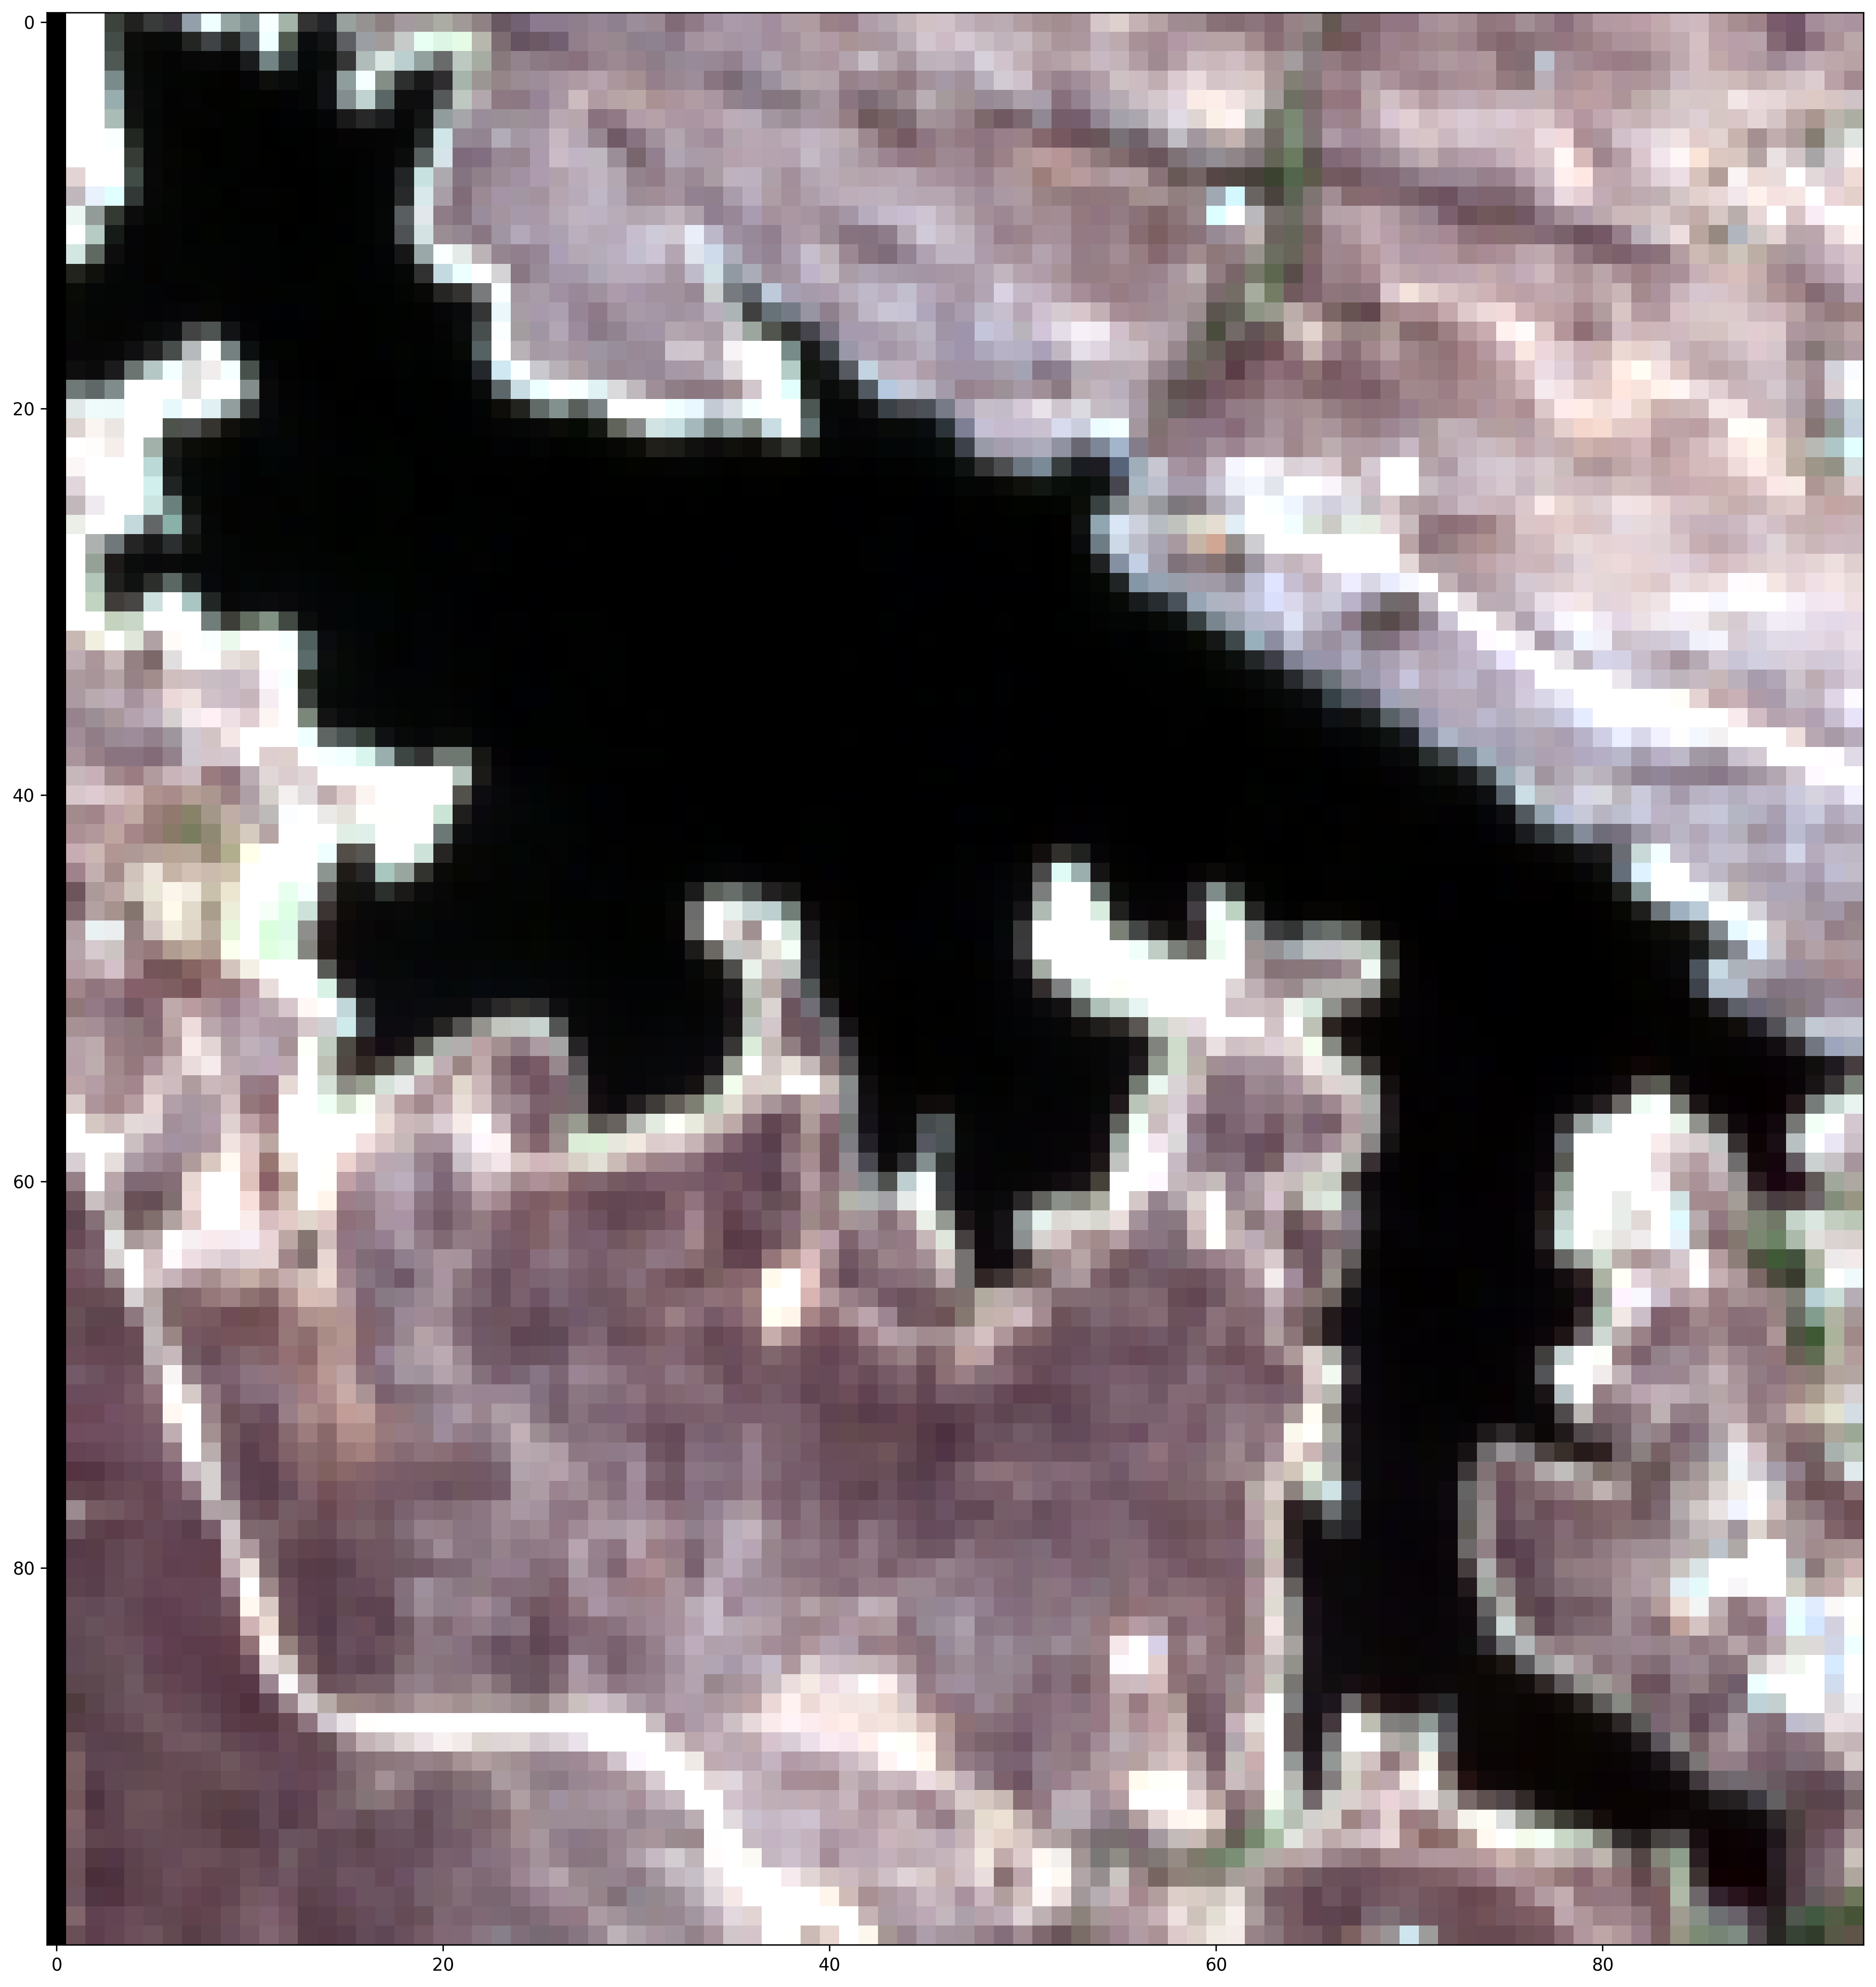

In [117]:
plt.figure(figsize=(26,20),dpi=300)
plt.imshow(Y_pred.reshape([x,y]),cmap='gnuplot2')
plt.show()
plt.figure(figsize=(26,20),dpi=300)
plt.imshow(prueba,cmap='Paired')
plt.show()
plt.figure(figsize=(26,20),dpi=300)
show(nequalize(s2_clip[[3,2,1]]))
plt.show()